# Calibración del modelo Markov-modulado a opciones de SPY

Notebook principal del parcial de Métodos Numéricos en Finanzas.

Referencias:

- Enunciado: `Julian Alejandro Archila Caro - Parcial Calibracion Markov Modulado.pdf`
- Plan de trabajo: `plans/plan-parcial-calibracion-markov.md`
- Taller 2: `reference/taller2/Taller_2_Metodos.ipynb`
- Taller 3/4: `reference/taller3/Taller3.ipynb`


## 0. Configuración reproducible

In [12]:
from pathlib import Path
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

PROJECT_ROOT = Path.cwd().resolve()
DATA = PROJECT_ROOT / "data"
OUTPUT = PROJECT_ROOT / "output"

for directory in (DATA, OUTPUT):
    directory.mkdir(parents=True, exist_ok=True)

print(f"Proyecto: {PROJECT_ROOT}")
print(f"NumPy: {np.__version__} | pandas: {pd.__version__} | SciPy: {scipy.__version__}")
print(f"Semilla: {SEED}")


Proyecto: /home/julian_alibio_co/UN/julian/metodos_numericos_parcial
NumPy: 2.5.0 | pandas: 3.0.3 | SciPy: 1.18.0
Semilla: 42


## 1. Datos de mercado de SPY

Descarga, congelación y filtrado reproducible de la cadena de opciones.

### Enfoque de la Parte 0

El subyacente asignado es **SPY**. La descarga con `yfinance` se ejecuta **una
sola vez** y congela un *snapshot* crudo en `data/spy_options_raw.csv` junto con
sus metadatos (`data/spy_snapshot_meta.json`). Toda la calibración posterior
lee ese CSV congelado, nunca una descarga en vivo (reproducibilidad y equidad).

Convenciones fijadas para todo el proyecto:

- **Conteo de dias:** ACT/365, \(T=\text{dias naturales hasta el vencimiento}/365\).
- **Tasa libre de riesgo:** \(r\) plana, tomada del T-bill a 13 semanas
  (`^IRX`) en la fecha del snapshot. Es coherente con la decision del parcial de
  calibrar con \(r_0=r_1=r\) y con horizontes \(\le 1\) ano.
- **Dividendos:** \(q\) plana, estimada con los dividendos pagados por SPY en
  los ultimos 12 meses divididos por el spot.
- **Forward:** \(F=S_0e^{(r-q)T}\); equivalentemente absorbemos \(q\) usando
  el spot ajustado \(S_0e^{-qT}\) dentro de Black-Scholes.
- **Precio de mercado:** `mid = (bid + ask) / 2`.

Vencimientos objetivo: terceros viernes mas liquidos cubriendo ~1 mes a ~1 ano
(DTE objetivo 30, 60, 90, 120, 180, 270, 360 dias).

In [13]:
# Black-Scholes en forma forward, vega e inversion de volatilidad implicita.
# Funciones reutilizables del Taller 2: se ubican aqui porque la construccion
# del conjunto de datos ya necesita invertir IV y calcular vega.
from scipy.stats import norm
from scipy.optimize import brentq


def bs_price(S0, K, T, r, q, sigma, option_type="call"):
    """Precio Black-Scholes con dividendo continuo q (forma forward)."""
    if T <= 0:
        payoff = max(S0 - K, 0.0) if option_type == "call" else max(K - S0, 0.0)
        return float(payoff)
    F = S0 * np.exp((r - q) * T)
    disc = np.exp(-r * T)
    if sigma <= 0:
        fwd_payoff = max(F - K, 0.0) if option_type == "call" else max(K - F, 0.0)
        return float(disc * fwd_payoff)
    vol = sigma * np.sqrt(T)
    d1 = (np.log(F / K) + 0.5 * vol * vol) / vol
    d2 = d1 - vol
    if option_type == "call":
        return float(disc * (F * norm.cdf(d1) - K * norm.cdf(d2)))
    return float(disc * (K * norm.cdf(-d2) - F * norm.cdf(-d1)))


def bs_vega(S0, K, T, r, q, sigma):
    """Vega Black-Scholes (derivada del precio respecto a sigma)."""
    if T <= 0 or sigma <= 0:
        return 0.0
    F = S0 * np.exp((r - q) * T)
    disc = np.exp(-r * T)
    vol = sigma * np.sqrt(T)
    d1 = (np.log(F / K) + 0.5 * vol * vol) / vol
    return float(disc * F * norm.pdf(d1) * np.sqrt(T))


def implied_vol(price, S0, K, T, r, q, option_type="call",
                lo=1e-4, hi=5.0):
    """IV por Brent. Devuelve NaN si el precio viola cotas de no arbitraje."""
    if not np.isfinite(price) or price <= 0 or T <= 0:
        return np.nan
    disc = np.exp(-r * T)
    fwd = S0 * np.exp((r - q) * T)
    if option_type == "call":
        lower, upper = disc * max(fwd - K, 0.0), disc * fwd
    else:
        lower, upper = disc * max(K - fwd, 0.0), disc * K
    eps = 1e-10
    if price <= lower + eps or price >= upper - eps:
        return np.nan
    f = lambda s: bs_price(S0, K, T, r, q, s, option_type) - price
    try:
        return float(brentq(f, lo, hi, xtol=1e-8, maxiter=200))
    except (ValueError, RuntimeError):
        return np.nan


print("Helpers BS/IV listos:", bs_price(100, 100, 0.5, 0.03, 0.0, 0.2),
      round(implied_vol(bs_price(100, 100, 0.5, 0.03, 0.0, 0.2),
                        100, 100, 0.5, 0.03, 0.0), 4))

Helpers BS/IV listos: 6.37102794216746 0.2


In [14]:
# Configuracion congelable del snapshot de datos.
import json
import datetime as dt

TICKER = "SPY"
TARGET_DTE = [30, 60, 90, 120, 180, 270, 360]   # dias objetivo (~1 mes a ~1 ano)
DAYCOUNT = 365.0                                  # ACT/365

# Filtros deterministas (documentados en el informe).
MONEYNESS_LO, MONEYNESS_HI = 0.80, 1.20           # 0.8 <= K/S0 <= 1.2
MAX_REL_SPREAD = 0.50                             # (ask-bid)/mid maximo
MIN_OPEN_INTEREST = 10                            # interes abierto minimo
MIN_MID = 0.05                                    # descarta opciones de centavos
IV_LO, IV_HI = 0.01, 3.0                          # rango admisible de IV

RAW_CSV = DATA / "spy_options_raw.csv"
FILTERED_CSV = DATA / "spy_options_filtered.csv"
META_JSON = DATA / "spy_snapshot_meta.json"

FORCE_DOWNLOAD = False   # poner True solo para regenerar el snapshot crudo

print("Config de datos lista. Snapshot crudo:", RAW_CSV.name)

Config de datos lista. Snapshot crudo: spy_options_raw.csv


In [15]:
# Descarga UNICA y congelacion del snapshot crudo de SPY.
# Si el CSV ya existe (y FORCE_DOWNLOAD es False) se omite la descarga.
import yfinance as yf


def _select_expirations(available, snapshot_date, target_dte):
    """Para cada DTE objetivo elige el vencimiento disponible mas cercano."""
    days = {e: (dt.date.fromisoformat(e) - snapshot_date).days for e in available}
    chosen = []
    for tgt in target_dte:
        cand = min(available, key=lambda e: abs(days[e] - tgt))
        if cand not in chosen and days[cand] > 0:
            chosen.append(cand)
    return sorted(chosen, key=lambda e: days[e])


def download_snapshot():
    tk = yf.Ticker(TICKER)
    now_utc = dt.datetime.now(dt.timezone.utc)
    snap_date = now_utc.date()
    spot = float(tk.fast_info["last_price"])

    # Tasa libre de riesgo r: T-bill 13 semanas (^IRX), en porcentaje anual.
    irx = yf.Ticker("^IRX").history(period="5d")["Close"].dropna()
    r_flat = float(irx.iloc[-1]) / 100.0

    # Dividendo q: suma de dividendos de SPY en los ultimos 365 dias / spot.
    div = tk.dividends.copy()
    div.index = pd.to_datetime(div.index)
    ttm = float(div[div.index > (div.index.max() - pd.Timedelta(days=365))].sum())
    q_flat = ttm / spot

    expiries = _select_expirations(list(tk.options), snap_date, TARGET_DTE)
    frames = []
    for exp in expiries:
        ch = tk.option_chain(exp)
        for opt_type, tbl in (("call", ch.calls), ("put", ch.puts)):
            t = tbl.copy()
            t["expiry"] = exp
            t["type"] = opt_type
            frames.append(t)
    raw = pd.concat(frames, ignore_index=True)
    raw["snapshot_utc"] = now_utc.isoformat()
    raw["spot"] = spot
    raw.to_csv(RAW_CSV, index=False)

    meta = {
        "ticker": TICKER,
        "snapshot_utc": now_utc.isoformat(),
        "snapshot_date": snap_date.isoformat(),
        "timezone": "UTC",
        "spot": spot,
        "r_flat": r_flat,
        "r_source": "^IRX 13-week T-bill, ultimo cierre",
        "q_flat": q_flat,
        "q_source": "dividendos SPY ultimos 365 dias / spot",
        "expiries": expiries,
        "daycount": DAYCOUNT,
        "source": "yfinance",
    }
    META_JSON.write_text(json.dumps(meta, indent=2))
    return raw, meta


if RAW_CSV.exists() and META_JSON.exists() and not FORCE_DOWNLOAD:
    print("Snapshot congelado encontrado; se omite la descarga en vivo.")
else:
    _raw, _meta = download_snapshot()
    print("Snapshot descargado y congelado.")
    print("  filas crudas:", len(_raw), "| vencimientos:", _meta["expiries"])

Snapshot congelado encontrado; se omite la descarga en vivo.


In [16]:
# Carga del snapshot congelado y sus metadatos.
meta = json.loads(META_JSON.read_text())
raw = pd.read_csv(RAW_CSV)

S0 = float(meta["spot"])
R_FLAT = float(meta["r_flat"])
Q_FLAT = float(meta["q_flat"])
SNAP_DATE = dt.date.fromisoformat(meta["snapshot_date"])

print(f"Snapshot {meta['snapshot_utc']} ({meta['timezone']})")
print(f"Spot S0 = {S0:.2f} | r = {R_FLAT*100:.3f}% ({meta['r_source']})")
print(f"q = {Q_FLAT*100:.3f}% ({meta['q_source']})")
print(f"Filas crudas: {len(raw)} | vencimientos: {len(meta['expiries'])}")
raw[["expiry", "type", "strike", "bid", "ask", "volume",
     "openInterest"]].head()

Snapshot 2026-06-24T22:34:53.010637+00:00 (UTC)
Spot S0 = 733.24 | r = 3.690% (^IRX 13-week T-bill, ultimo cierre)
q = 1.266% (dividendos SPY ultimos 365 dias / spot)
Filas crudas: 2497 | vencimientos: 7


,expiry,type,strike,bid,ask,volume,openInterest
0,2026-07-24,call,500.0,237.31,240.58,2.0,1
1,2026-07-24,call,525.0,212.47,215.74,NaN,7
2,2026-07-24,call,530.0,207.50,210.77,NaN,3
3,2026-07-24,call,540.0,197.57,200.84,NaN,3
4,2026-07-24,call,550.0,187.64,190.91,1.0,3


In [17]:
# Construccion del conjunto calibrable: T, mid, spread, forward, moneyness.
df = raw.rename(columns={
    "strike": "K",
    "openInterest": "open_interest",
}).copy()

df["snapshot_date"] = meta["snapshot_date"]
df["expiry_date"] = pd.to_datetime(df["expiry"]).dt.date
df["dte"] = df["expiry_date"].apply(lambda d: (d - SNAP_DATE).days)
df["T"] = df["dte"] / DAYCOUNT
df["S0"] = S0
df["r"] = R_FLAT
df["q"] = Q_FLAT
df["forward"] = df["S0"] * np.exp((df["r"] - df["q"]) * df["T"])

df["mid"] = (df["bid"] + df["ask"]) / 2.0
df["spread"] = df["ask"] - df["bid"]
df["rel_spread"] = df["spread"] / df["mid"].replace(0, np.nan)
df["moneyness"] = df["K"] / df["S0"]

print("Columnas construidas. Filas:", len(df))
df[["expiry", "type", "K", "T", "bid", "ask", "mid", "spread",
    "forward", "moneyness"]].head()

Columnas construidas. Filas: 2497


,expiry,type,K,T,bid,ask,mid,spread,forward,moneyness
0,2026-07-24,call,500.0,0.082192,237.31,240.58,238.945,3.27,734.70204,0.681905
1,2026-07-24,call,525.0,0.082192,212.47,215.74,214.105,3.27,734.70204,0.716000
2,2026-07-24,call,530.0,0.082192,207.50,210.77,209.135,3.27,734.70204,0.722819
3,2026-07-24,call,540.0,0.082192,197.57,200.84,199.205,3.27,734.70204,0.736457
4,2026-07-24,call,550.0,0.082192,187.64,190.91,189.275,3.27,734.70204,0.750095


In [18]:
# Filtros deterministas con reporte del descarte en cada etapa.
def report(mask, name, frame):
    kept = int(mask.sum())
    print(f"  {name:<34s} conserva {kept:5d} / {len(frame):5d}")
    return frame[mask]


print("Filtrado de cotizaciones:")
f = df.copy()
f = report((f["bid"] > 0) & (f["ask"] > 0) & (f["ask"] >= f["bid"]),
           "bid/ask validos", f)
f = report(f["mid"] >= MIN_MID, f"mid >= {MIN_MID}", f)
f = report(f["rel_spread"] <= MAX_REL_SPREAD,
           f"spread relativo <= {MAX_REL_SPREAD}", f)
f = report(f["open_interest"].fillna(0) >= MIN_OPEN_INTEREST,
           f"open interest >= {MIN_OPEN_INTEREST}", f)
f = report((f["moneyness"] >= MONEYNESS_LO) & (f["moneyness"] <= MONEYNESS_HI),
           f"{MONEYNESS_LO} <= K/S0 <= {MONEYNESS_HI}", f)

# Cotas de no arbitraje sobre el mid (con descuento y forward).
disc = np.exp(-f["r"] * f["T"])
fwd = f["forward"]
lower = np.where(f["type"] == "call",
                 disc * np.maximum(fwd - f["K"], 0.0),
                 disc * np.maximum(f["K"] - fwd, 0.0))
upper = np.where(f["type"] == "call", disc * fwd, disc * f["K"])
f = report((f["mid"] > lower) & (f["mid"] < upper),
           "cotas de no arbitraje", f)

filtered = f.reset_index(drop=True)
print("Filas tras filtros de mercado:", len(filtered))

Filtrado de cotizaciones:
  bid/ask validos                    conserva  2472 /  2497
  mid >= 0.05                        conserva  2395 /  2472
  spread relativo <= 0.5             conserva  2389 /  2395
  open interest >= 10                conserva  1999 /  2389
  0.8 <= K/S0 <= 1.2                 conserva  1232 /  1999
  cotas de no arbitraje              conserva  1220 /  1232
Filas tras filtros de mercado: 1220


In [19]:
# Volatilidad implicita de mercado y vega por observacion (con nuestro r, q).
filtered["iv_mkt"] = [
    implied_vol(row.mid, row.S0, row.K, row.T, row.r, row.q, row.type)
    for row in filtered.itertuples()
]
ok = filtered["iv_mkt"].between(IV_LO, IV_HI) & filtered["iv_mkt"].notna()
print(f"  IV finita en rango [{IV_LO}, {IV_HI}]: {int(ok.sum())} / {len(filtered)}")
filtered = filtered[ok].reset_index(drop=True)

filtered["vega"] = [
    bs_vega(row.S0, row.K, row.T, row.r, row.q, row.iv_mkt)
    for row in filtered.itertuples()
]
filtered = filtered[filtered["vega"] > 1e-6].reset_index(drop=True)
print("Filas con IV y vega finitas:", len(filtered))

  IV finita en rango [0.01, 3.0]: 1220 / 1220
Filas con IV y vega finitas: 1220


In [20]:
# Conjunto calibrable final con las columnas minimas exigidas.
COLS = ["snapshot_date", "expiry", "type", "S0", "K", "T", "dte",
        "bid", "ask", "mid", "spread", "rel_spread", "volume",
        "open_interest", "r", "q", "forward", "iv_mkt", "vega", "moneyness"]
calib = filtered[COLS].sort_values(["expiry", "type", "K"]).reset_index(drop=True)
calib.to_csv(FILTERED_CSV, index=False)
print(f"Conjunto calibrable guardado en {FILTERED_CSV.name}: {len(calib)} filas")
calib.head()

Conjunto calibrable guardado en spy_options_filtered.csv: 1220 filas


,snapshot_date,expiry,type,S0,K,T,dte,bid,ask,mid,spread,rel_spread,volume,open_interest,r,q,forward,iv_mkt,vega,moneyness
0,2026-06-24,2026-07-24,call,733.23999,615.0,0.082192,30,123.25,126.53,124.890,3.28,0.026263,2.0,13,0.0369,0.012664,734.70204,0.516638,37.174940,0.838743
1,2026-06-24,2026-07-24,call,733.23999,635.0,0.082192,30,103.55,106.83,105.190,3.28,0.031182,14.0,15,0.0369,0.012664,734.70204,0.452996,41.371152,0.866019
2,2026-06-24,2026-07-24,call,733.23999,640.0,0.082192,30,98.65,101.93,100.290,3.28,0.032705,51.0,61,0.0369,0.012664,734.70204,0.437520,42.606181,0.872838
3,2026-06-24,2026-07-24,call,733.23999,645.0,0.082192,30,94.46,96.07,95.265,1.61,0.016900,2.0,163,0.0369,0.012664,734.70204,0.419073,43.549619,0.879657
4,2026-06-24,2026-07-24,call,733.23999,650.0,0.082192,30,88.88,92.16,90.520,3.28,0.036235,4.0,14,0.0369,0.012664,734.70204,0.406883,45.324672,0.886476


In [21]:
# Tabla de conteos por vencimiento y tipo tras el filtrado.
counts = (calib.groupby(["expiry", "type"]).size().unstack(fill_value=0))
counts["total"] = counts.sum(axis=1)
counts.loc["TOTAL"] = counts.sum()
dte_map = calib.groupby("expiry")["dte"].first()
counts.insert(0, "dte", [dte_map.get(i, "") for i in counts.index])
print("Cotizaciones por vencimiento y tipo:")
counts

Cotizaciones por vencimiento y tipo:


type,dte,call,put,total
expiry,,,,
2026-07-24,30,108,119,227
2026-08-21,58,144,144,288
2026-09-18,86,140,159,299
2026-10-16,114,52,42,94
2026-12-18,177,58,45,103
2027-03-19,268,58,46,104
2027-06-17,358,58,47,105
TOTAL,,618,602,1220


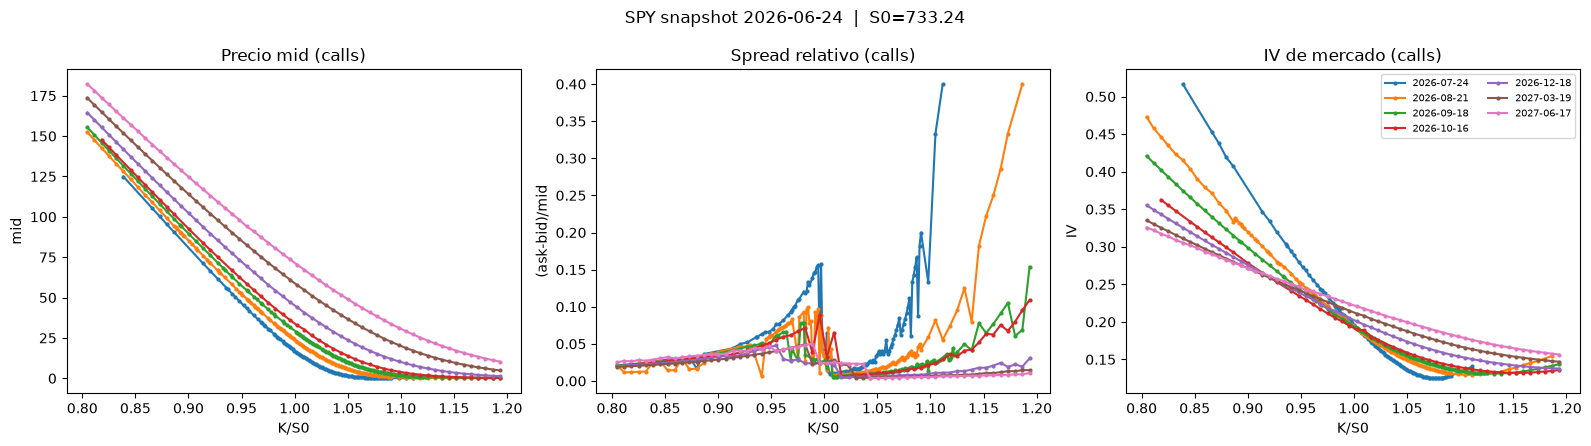

In [22]:
# Graficos exploratorios: mid, spread relativo e IV observada por vencimiento.
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for exp, g in calib.groupby("expiry"):
    gc = g[g["type"] == "call"].sort_values("K")
    axes[0].plot(gc["moneyness"], gc["mid"], marker=".", ms=4, label=exp)
    axes[1].plot(gc["moneyness"], gc["rel_spread"], marker=".", ms=4, label=exp)
    axes[2].plot(gc["moneyness"], gc["iv_mkt"], marker=".", ms=4, label=exp)
axes[0].set(title="Precio mid (calls)", xlabel="K/S0", ylabel="mid")
axes[1].set(title="Spread relativo (calls)", xlabel="K/S0", ylabel="(ask-bid)/mid")
axes[2].set(title="IV de mercado (calls)", xlabel="K/S0", ylabel="IV")
axes[2].legend(fontsize=7, ncol=2)
fig.suptitle(f"SPY snapshot {meta['snapshot_date']}  |  S0={S0:.2f}")
fig.tight_layout()
fig.savefig(OUTPUT / "spy_exploratorio.png", dpi=120, bbox_inches="tight")
plt.show()

## 2. Ruta A: fórmula analítica por mezcla

Implementación de la ley de la varianza integrada, masa atómica y término continuo.

### Ruta A: formula analitica por mezcla (Teorema 1)

El precio europeo condicionado al regimen inicial $i$ se escribe como la suma de
un **atomo de borde** (el evento "no hay cambio de regimen") y una **integral**
de Black-Scholes contra la densidad continua de la varianza integrada
$A_{0,T}$:

$$
C_i(0,s)=e^{-\lambda_i T}\,\mathrm{BS}\!\left(s,K,T,r(a_i^*);a_i^*\right)
+\int_{a_-}^{a_+}\mathrm{BS}\!\left(s,K,T,r(a);a\right)\,g_i^A(a,T)\,da,
$$

con soporte $a_-=\sigma_0^2T$, $a_+=\sigma_1^2T$, $a_0^*=a_-$, $a_1^*=a_+$ y
$\Delta_\sigma=\sigma_1^2-\sigma_0^2$. La **tasa integrada** del camino es
$R(a)=r_0T+(r_1-r_0)(a-\sigma_0^2T)/\Delta_\sigma$ y la tasa efectiva
$r(a)=R(a)/T$. Con $r_0=r_1=r$ se recupera $R(a)=rT$ (Black-Scholes de tasa
constante). Las densidades y los atomos **no** dependen de las tasas:

$$
\eta(a)=\tfrac{2}{\Delta_\sigma}\sqrt{\lambda_0\lambda_1(\sigma_1^2T-a)(a-\sigma_0^2T)},\quad
\Gamma(a)=\tfrac{\lambda_0(\sigma_1^2T-a)+\lambda_1(a-\sigma_0^2T)}{\Delta_\sigma},
$$

$$
g_0^A=\tfrac{e^{-\Gamma(a)}}{\Delta_\sigma}\Big[\lambda_0 I_0(\eta)+\sqrt{\lambda_0\lambda_1\tfrac{\sigma_1^2T-a}{a-\sigma_0^2T}}\,I_1(\eta)\Big],\quad
g_1^A=\tfrac{e^{-\Gamma(a)}}{\Delta_\sigma}\Big[\lambda_1 I_0(\eta)+\sqrt{\lambda_0\lambda_1\tfrac{a-\sigma_0^2T}{\sigma_1^2T-a}}\,I_1(\eta)\Big].
$$

Masas atomicas: $Q_0(A=a_-)=e^{-\lambda_0 T}$ y $Q_1(A=a_+)=e^{-\lambda_1 T}$.

**Singularidad integrable.** El termino $I_1(\eta)/\sqrt{\cdot}$ se comporta como
$a^{\mp 1/2}$ en los extremos. Para integrar de forma estable usamos el cambio de
variable trigonometrico $a=c-h\cos t$ con $c=(a_-+a_+)/2$, $h=(a_+-a_-)/2$ y
$t\in[0,\pi]$; entonces $da=h\sin t\,dt$ y, como
$\sqrt{(a_+-a)(a-a_-)}=h\,\sin t$, el jacobiano cancela exactamente la
singularidad $1/\sqrt{\cdot}$ en **ambos** bordes. La integral resultante es
suave y se evalua con `scipy.integrate.quad` adaptativa.

**Rama degenerada.** Cuando $\Delta_\sigma\to 0$ el soporte colapsa a una masa
en $\sigma^2 T$ y el precio tiende a Black-Scholes plano; lo tratamos
explicitamente con un umbral relativo sobre $\Delta_\sigma$.

**Puts.** Se obtienen integrando la BS-put contra la misma densidad. Cuando
$r_0=r_1$ esto coincide con la paridad por regimen
$C_i-P_i=s-Ke^{-rT}$, que verificamos numericamente.

In [23]:
# === Ruta A: formula analitica por mezcla (Teorema 1) ===
# Reutiliza norm (scipy.stats) ya importado. Bessel modificadas via scipy.special.iv.
import warnings as _warnings
from scipy.special import iv as _besseliv
from scipy.integrate import quad as _quad, IntegrationWarning as _IntWarn
from scipy.stats import norm as _norm


def _quad_safe(func, a, b, **kw):
    """quad adaptativa que MANEJA explicitamente el aviso de roundoff.

    Cuando el soporte (a-, a+) es muy estrecho (Dsig pequeno, cerca de la rama
    degenerada) la cuadratura alcanza precision de maquina y QUADPACK emite un
    IntegrationWarning de roundoff aunque el resultado ya es exacto (err ~ 1e-14
    << 1e-3). Lo capturamos y, si el error estimado es pequeno, lo aceptamos sin
    propagar un aviso silencioso; en caso contrario lo re-emitimos."""
    with _warnings.catch_warnings(record=True) as caught:
        _warnings.simplefilter("always", _IntWarn)
        val, err = _quad(func, a, b, **kw)
    for w in caught:
        if issubclass(w.category, _IntWarn) and err > 1e-6:
            _warnings.warn_explicit(w.message, w.category, w.filename, w.lineno)
    return val, err


def bs_total_variance(s, K, T, R, a, option_type="call"):
    """Black-Scholes en funcion de la varianza total a y la tasa integrada R.

    R = r(a)*T es el factor de descuento integrado; a = sigma^2*T la varianza
    total. d1,2 = [ln(s/K) + R +- a/2]/sqrt(a). Con R=r*T y a=sigma^2*T coincide
    con la BS de tasa constante. Vectorizable sobre a y R."""
    s = float(s)
    K = float(K)
    a = np.asarray(a, dtype=float)
    R = np.asarray(R, dtype=float)
    out_shape = np.broadcast(a, R).shape
    a_b = np.broadcast_to(a, out_shape).astype(float)
    R_b = np.broadcast_to(R, out_shape).astype(float)
    res = np.empty(out_shape, dtype=float)
    pos = a_b > 0.0
    # Limite a->0 (varianza nula): payoff descontado del forward s*exp? -> usar intrinseco fwd.
    if np.any(~pos):
        fwd = s * np.exp(R_b[~pos])
        disc = np.exp(-R_b[~pos])
        if option_type == "call":
            res[~pos] = disc * np.maximum(fwd - K, 0.0)
        else:
            res[~pos] = disc * np.maximum(K - fwd, 0.0)
    if np.any(pos):
        aa = a_b[pos]
        RR = R_b[pos]
        sa = np.sqrt(aa)
        d1 = (np.log(s / K) + RR + 0.5 * aa) / sa
        d2 = d1 - sa
        disc = np.exp(-RR)
        if option_type == "call":
            res[pos] = s * _norm.cdf(d1) - K * disc * _norm.cdf(d2)
        else:
            res[pos] = K * disc * _norm.cdf(-d2) - s * _norm.cdf(-d1)
    return res if res.shape else float(res)


def _integrated_rate(a, T, r0, r1, sigma0, sigma1):
    """R(a) = r0*T + (r1-r0)*(a - sigma0^2*T)/Dsig (factor de descuento integrado)."""
    am = sigma0 ** 2 * T
    Dsig = sigma1 ** 2 - sigma0 ** 2
    return r0 * T + (r1 - r0) * (a - am) / Dsig


def _g_density(a, T, sigma0, sigma1, lam0, lam1, regime):
    """Densidad continua g_i^A(a,T) en a en (a-, a+). Vectorizada en a."""
    a = np.asarray(a, dtype=float)
    am = sigma0 ** 2 * T
    ap = sigma1 ** 2 * T
    Dsig = sigma1 ** 2 - sigma0 ** 2
    right = ap - a          # sigma1^2 T - a
    left = a - am           # a - sigma0^2 T
    # Clamp numerico para evitar negativos por redondeo en los bordes.
    right = np.maximum(right, 0.0)
    left = np.maximum(left, 0.0)
    eta = (2.0 / Dsig) * np.sqrt(lam0 * lam1 * right * left)
    Gamma = (lam0 * right + lam1 * left) / Dsig
    pref = np.exp(-Gamma) / Dsig
    I0 = _besseliv(0, eta)
    I1 = _besseliv(1, eta)
    if regime == 0:
        # sqrt(lam0 lam1 * right/left) * I1
        with np.errstate(divide="ignore", invalid="ignore"):
            ratio = np.where(left > 0, right / left, np.inf)
        bess = np.sqrt(lam0 * lam1 * ratio) * I1
        return pref * (lam0 * I0 + bess)
    else:
        with np.errstate(divide="ignore", invalid="ignore"):
            ratio = np.where(right > 0, left / right, np.inf)
        bess = np.sqrt(lam0 * lam1 * ratio) * I1
        return pref * (lam1 * I0 + bess)


def _mass_continuous(T, sigma0, sigma1, lam0, lam1, regime):
    """Integral de g_i^A sobre (a-, a+) via sustitucion trigonometrica."""
    am = sigma0 ** 2 * T
    ap = sigma1 ** 2 * T
    c = 0.5 * (am + ap)
    h = 0.5 * (ap - am)

    def integrand(t):
        a = c - h * np.cos(t)
        g = _g_density(a, T, sigma0, sigma1, lam0, lam1, regime)
        return float(g * h * np.sin(t))

    val, err = _quad_safe(integrand, 0.0, np.pi, limit=200,
                          epsabs=1e-12, epsrel=1e-12)
    return val, err


def price_analytic_markov(S0, K, T, r0, r1, sigma0, sigma1, lam0, lam1,
                          regime=0, option_type="call",
                          quad_limit=200, degen_tol=1e-10):
    """Precio europeo por la formula de mezcla (Teorema 1). Vale para r0 != r1.

    Atomo de borde e^{-lambda_i T} * BS(.; a_i^*) mas integral de BS(.; a) contra
    la densidad continua g_i^A(a,T). Rama degenerada explicita cuando
    sigma1 -> sigma0 (Delta_sigma pequeno). Devuelve un float."""
    if regime not in (0, 1):
        raise ValueError("regime debe ser 0 o 1.")
    if option_type not in ("call", "put"):
        raise ValueError("option_type debe ser 'call' o 'put'.")
    if not (sigma0 <= sigma1):
        raise ValueError("se asume sigma0 <= sigma1.")
    if T <= 0:
        payoff = (max(S0 - K, 0.0) if option_type == "call"
                  else max(K - S0, 0.0))
        return float(payoff)

    am = sigma0 ** 2 * T
    ap = sigma1 ** 2 * T
    Dsig = sigma1 ** 2 - sigma0 ** 2

    # --- Rama degenerada: sigma0 ~ sigma1 -> BS plano en sigma^2 = (am)/T ---
    if Dsig <= degen_tol * max(sigma1 ** 2, 1e-12):
        a_deg = 0.5 * (am + ap)
        R_deg = 0.5 * (r0 + r1) * T
        return float(bs_total_variance(S0, K, T, R_deg, a_deg, option_type))

    # --- Atomo de borde ---
    if regime == 0:
        a_star = am
        R_star = r0 * T          # R(a-) = r0 T
        mass_atom = np.exp(-lam0 * T)
    else:
        a_star = ap
        R_star = r1 * T          # R(a+) = r1 T
        mass_atom = np.exp(-lam1 * T)
    atom = mass_atom * float(bs_total_variance(S0, K, T, R_star, a_star,
                                               option_type))

    # --- Termino continuo: sustitucion trigonometrica a = c - h cos t ---
    c = 0.5 * (am + ap)
    h = 0.5 * (ap - am)

    def integrand(t):
        a = c - h * np.cos(t)
        R = _integrated_rate(a, T, r0, r1, sigma0, sigma1)
        bs = float(bs_total_variance(S0, K, T, R, a, option_type))
        g = float(_g_density(a, T, sigma0, sigma1, lam0, lam1, regime))
        return bs * g * h * np.sin(t)

    # epsabs relajado a 1e-11: el integrando tiene magnitud O(precio) y exigir
    # 1e-12 dispara avisos de roundoff sin mejorar la precision (err << 1e-3).
    integ, _err = _quad_safe(integrand, 0.0, np.pi, limit=quad_limit,
                             epsabs=1e-11, epsrel=1e-10)
    return float(atom + integ)


# Sanidad inmediata: el precio es finito en el caso base.
_pc0 = price_analytic_markov(100.0, 100.0, 0.5, 0.03, 0.03, 0.15, 0.40,
                             2.0, 5.0, regime=0, option_type="call")
_pc1 = price_analytic_markov(100.0, 100.0, 0.5, 0.03, 0.03, 0.15, 0.40,
                             2.0, 5.0, regime=1, option_type="call")
print("price_analytic_markov listo.")
print(f"  Caso base K=100 call: C0={_pc0:.6f}  C1={_pc1:.6f}")


price_analytic_markov listo.
  Caso base K=100 call: C0=6.776006  C1=8.865638


### Pruebas internas de la Ruta A

Ejecutamos las cuatro pruebas obligatorias del enunciado:

1. **Masa total:** $e^{-\lambda_i T}+\int_{a_-}^{a_+}g_i^A(a,T)\,da=1$ en ambos
   regimenes, con error $\le 10^{-6}$.
2. **Caso sin regimen:** $\sigma_0\to\sigma_1$ converge a Black-Scholes plano.
3. **Cota ($r_0=r_1$):** $\mathrm{BS}(\cdot;a_-)\le C_i\le \mathrm{BS}(\cdot;a_+)$.
4. **Sanidad financiera:** positividad, no arbitraje, monotonia en $K$ y paridad
   call-put cuando $r_0=r_1$.

In [24]:
# Prueba 1: MASA TOTAL  e^{-lambda_i T} + integral g_i^A = 1  (error <= 1e-6).
print("=== Prueba 1: masa total (objetivo error <= 1e-6) ===")
_param_sets = [
    dict(T=0.5, sigma0=0.15, sigma1=0.40, lam0=2.0, lam1=5.0),
    dict(T=1.0, sigma0=0.10, sigma1=0.60, lam0=0.5, lam1=3.0),
    dict(T=0.25, sigma0=0.20, sigma1=0.30, lam0=4.0, lam1=1.0),
]
_max_mass_err = 0.0
for ps in _param_sets:
    for reg in (0, 1):
        atom = np.exp(-(ps["lam0"] if reg == 0 else ps["lam1"]) * ps["T"])
        cont, qerr = _mass_continuous(ps["T"], ps["sigma0"], ps["sigma1"],
                                      ps["lam0"], ps["lam1"], reg)
        total = atom + cont
        err = abs(total - 1.0)
        _max_mass_err = max(_max_mass_err, err)
        print(f"  T={ps['T']:.2f} s0={ps['sigma0']:.2f} s1={ps['sigma1']:.2f} "
              f"l0={ps['lam0']:.1f} l1={ps['lam1']:.1f} reg={reg} | "
              f"atomo={atom:.6f} integral={cont:.6f} total={total:.10f} "
              f"err={err:.2e}")
print(f"  -> max error de masa = {_max_mass_err:.3e}  "
      f"({'OK' if _max_mass_err <= 1e-6 else 'FALLA'} <= 1e-6)")


=== Prueba 1: masa total (objetivo error <= 1e-6) ===
  T=0.50 s0=0.15 s1=0.40 l0=2.0 l1=5.0 reg=0 | atomo=0.367879 integral=0.632121 total=1.0000000000 err=0.00e+00
  T=0.50 s0=0.15 s1=0.40 l0=2.0 l1=5.0 reg=1 | atomo=0.082085 integral=0.917915 total=1.0000000000 err=0.00e+00
  T=1.00 s0=0.10 s1=0.60 l0=0.5 l1=3.0 reg=0 | atomo=0.606531 integral=0.393469 total=1.0000000000 err=0.00e+00
  T=1.00 s0=0.10 s1=0.60 l0=0.5 l1=3.0 reg=1 | atomo=0.049787 integral=0.950213 total=1.0000000000 err=0.00e+00
  T=0.25 s0=0.20 s1=0.30 l0=4.0 l1=1.0 reg=0 | atomo=0.367879 integral=0.632121 total=1.0000000000 err=0.00e+00
  T=0.25 s0=0.20 s1=0.30 l0=4.0 l1=1.0 reg=1 | atomo=0.778801 integral=0.221199 total=1.0000000000 err=0.00e+00
  -> max error de masa = 0.000e+00  (OK <= 1e-6)


In [25]:
# Prueba 2: CASO SINGULAR  sigma0 -> sigma1  converge a BS plano.
print("=== Prueba 2: caso singular sigma0 -> sigma1 (BS plano) ===")
_S0, _K, _T, _r = 100.0, 100.0, 0.5, 0.03
_sig = 0.25
# BS plano de referencia (tasa constante, varianza total sig^2 T).
_bs_flat = float(bs_total_variance(_S0, _K, _T, _r * _T, _sig ** 2 * _T, "call"))
print(f"  BS plano (sigma={_sig}) call K={_K}: {_bs_flat:.8f}")
for _eps in (1e-2, 1e-4, 1e-6, 1e-9):
    _s0 = _sig - 0.5 * _eps
    _s1 = _sig + 0.5 * _eps
    _c = price_analytic_markov(_S0, _K, _T, _r, _r, _s0, _s1, 2.0, 5.0,
                               regime=0, option_type="call")
    print(f"  sigma1-sigma0={_eps:.0e}  C0={_c:.8f}  |C0-BSplano|={abs(_c-_bs_flat):.2e}")
# Rama exactamente degenerada (sigma0 == sigma1) toma la rama explicita.
_c_exact = price_analytic_markov(_S0, _K, _T, _r, _r, _sig, _sig, 2.0, 5.0,
                                 regime=0, option_type="call")
print(f"  sigma0==sigma1 (rama explicita): C0={_c_exact:.8f}  "
      f"|dif|={abs(_c_exact-_bs_flat):.2e}")


=== Prueba 2: caso singular sigma0 -> sigma1 (BS plano) ===
  BS plano (sigma=0.25) call K=100.0: 7.76025667
  sigma1-sigma0=1e-02  C0=7.67928330  |C0-BSplano|=8.10e-02
  sigma1-sigma0=1e-04  C0=7.75944124  |C0-BSplano|=8.15e-04
  sigma1-sigma0=1e-06  C0=7.76024852  |C0-BSplano|=8.15e-06
  sigma1-sigma0=1e-09  C0=7.76025666  |C0-BSplano|=1.43e-08
  sigma0==sigma1 (rama explicita): C0=7.76025667  |dif|=0.00e+00


In [26]:
# Prueba 3: COTA (r0=r1)  BS(.;a-) <= C_i <= BS(.;a+).
print("=== Prueba 3: cota BS(a-) <= C_i <= BS(a+) (r0=r1) ===")
_bateria = [
    dict(S0=100, K=90,  T=0.5, r=0.03, s0=0.15, s1=0.40, l0=2.0, l1=5.0),
    dict(S0=100, K=100, T=0.5, r=0.03, s0=0.15, s1=0.40, l0=2.0, l1=5.0),
    dict(S0=100, K=110, T=0.5, r=0.03, s0=0.15, s1=0.40, l0=2.0, l1=5.0),
    dict(S0=100, K=100, T=1.0, r=0.05, s0=0.10, s1=0.50, l0=1.0, l1=1.0),
    dict(S0=120, K=100, T=0.25,r=0.01, s0=0.20, s1=0.35, l0=3.0, l1=0.5),
    dict(S0=80,  K=100, T=2.0, r=0.04, s0=0.12, s1=0.45, l0=0.3, l1=4.0),
]
_all_ok = True
for _opt in ("call", "put"):
    for p in _bateria:
        am = p["s0"] ** 2 * p["T"]
        ap = p["s1"] ** 2 * p["T"]
        R = p["r"] * p["T"]
        bs_lo = float(bs_total_variance(p["S0"], p["K"], p["T"], R, am, _opt))
        bs_hi = float(bs_total_variance(p["S0"], p["K"], p["T"], R, ap, _opt))
        lo, hi = min(bs_lo, bs_hi), max(bs_lo, bs_hi)
        for reg in (0, 1):
            C = price_analytic_markov(p["S0"], p["K"], p["T"], p["r"], p["r"],
                                      p["s0"], p["s1"], p["l0"], p["l1"],
                                      regime=reg, option_type=_opt)
            ok = (lo - 1e-9) <= C <= (hi + 1e-9)
            _all_ok = _all_ok and ok
            if not ok:
                print(f"  FALLA {_opt} K={p['K']} reg={reg}: {lo:.4f} <= {C:.4f} <= {hi:.4f}")
print(f"  -> cota se cumple en toda la bateria (call y put): {_all_ok}")


=== Prueba 3: cota BS(a-) <= C_i <= BS(a+) (r0=r1) ===
  -> cota se cumple en toda la bateria (call y put): True


In [27]:
# Prueba 4: SANIDAD  positividad, no arbitraje, monotonia en K, paridad.
print("=== Prueba 4: sanidad financiera ===")
_S0, _T, _r = 100.0, 0.5, 0.03
_s0, _s1, _l0, _l1 = 0.15, 0.40, 2.0, 5.0
_Ks = np.array([80, 85, 90, 95, 100, 105, 110, 115, 120], dtype=float)

_pos_ok = True
_arb_ok = True
_mono_call_ok = True
_mono_put_ok = True
_max_parity = 0.0
_has_nan = False

for reg in (0, 1):
    calls = np.array([price_analytic_markov(_S0, k, _T, _r, _r, _s0, _s1,
                                            _l0, _l1, reg, "call") for k in _Ks])
    puts = np.array([price_analytic_markov(_S0, k, _T, _r, _r, _s0, _s1,
                                           _l0, _l1, reg, "put") for k in _Ks])
    if not (np.all(np.isfinite(calls)) and np.all(np.isfinite(puts))):
        _has_nan = True
    # Positividad.
    _pos_ok = _pos_ok and np.all(calls >= -1e-10) and np.all(puts >= -1e-10)
    # No arbitraje: intrinseco descontado <= precio <= cota superior.
    disc = np.exp(-_r * _T)
    fwd = _S0 * np.exp(_r * _T)
    call_lo = disc * np.maximum(fwd - _Ks, 0.0)
    call_hi = disc * fwd
    put_lo = disc * np.maximum(_Ks - fwd, 0.0)
    put_hi = disc * _Ks
    _arb_ok = (_arb_ok and np.all(calls >= call_lo - 1e-8)
               and np.all(calls <= call_hi + 1e-8)
               and np.all(puts >= put_lo - 1e-8)
               and np.all(puts <= put_hi + 1e-8))
    # Monotonia: call decreciente en K, put creciente en K.
    _mono_call_ok = _mono_call_ok and np.all(np.diff(calls) <= 1e-8)
    _mono_put_ok = _mono_put_ok and np.all(np.diff(puts) >= -1e-8)
    # Paridad por regimen: C - P = S0 - K e^{-rT}.
    parity = (calls - puts) - (_S0 - _Ks * disc)
    _max_parity = max(_max_parity, float(np.max(np.abs(parity))))

print(f"  sin NaN/inf:            {not _has_nan}")
print(f"  positividad:            {_pos_ok}")
print(f"  no arbitraje:           {_arb_ok}")
print(f"  call decreciente en K:  {_mono_call_ok}")
print(f"  put creciente en K:     {_mono_put_ok}")
print(f"  max|paridad C-P|:       {_max_parity:.3e}  "
      f"({'OK' if _max_parity <= 1e-6 else 'FALLA'} <= 1e-6)")


=== Prueba 4: sanidad financiera ===
  sin NaN/inf:            True
  positividad:            True
  no arbitraje:           True
  call decreciente en K:  True
  put creciente en K:     True
  max|paridad C-P|:       5.329e-15  (OK <= 1e-6)


## 3. Rutas B y C: COS/FFT y EDP

Integración del código reutilizado de los Talleres 2 y 3/4.

### Rutas B y C: codigo reutilizado de los Talleres 2 y 3/4

Esta seccion incorpora, limpio y autocontenido, el codigo de valoracion por
Fourier (Taller 2) y por diferencias finitas (Taller 3/4) del modelo
Markov-modulado de dos regimenes. Convenciones del proyecto:

- El log-retorno es \(X_T=\ln(S_T/S_0)\) y su funcion caracteristica
  condicional al regimen inicial \(i\) es \(\varphi_i(z,T)\).
- La calibracion usa **tasa comun** \(r_0=r_1=r\); el regimen modula la
  volatilidad. El dividendo \(q\) se absorbe usando el **spot ajustado**
  \(S_0e^{-qT}\) y tasa \(r\) en estas rutas, coherente con el forward
  \(F=S_0e^{(r-q)T}\) del bloque de datos.
- Funciones **vectorizadas sobre strikes** y sin dependencias de variables
  globales del notebook (reciben todos sus parametros).

Nombres unificados respecto a los talleres (`SO->S0`, `sigmal->sigma1`,
`lamo->lam0`). Para no chocar con los helpers `bs_price/bs_vega/implied_vol`
de la seccion de datos (forma forward con `q`), las utilidades internas de
Fourier llevan sufijo `_cos` cuando aplica.

Procedencia:

- `char_func_markov`, `char_func_markov_matrix`, `cos_method`,
  `carr_madan_fft`, control COS-vs-FFT: **Taller 2**.
- `fd_european_put_markov`, `fd_european_call_markov` (theta-esquema /
  Crank-Nicolson): **Taller 3/4**.

#### Funcion caracteristica \(\varphi_i(z,T)\)

Forma cerrada estable (reescritura de cosh/sinh como suma de exponenciales) que
evita overflow y la indeterminacion \(0\cdot\infty\) cuando
\(\sqrt{D}\to0\). Se incluye una version por exponencial de la matriz
generadora \(2\times2\) como verificacion cruzada independiente.

In [28]:
# === Taller 2 ===
# Funcion caracteristica condicional del log-retorno X_T = ln(S_T/S_0) bajo Q,
# modelo Markov-modulado de 2 regimenes. i en {0, 1}. Vectorizada en z.
import numpy as np
from scipy.optimize import brentq
from scipy.interpolate import interp1d
from scipy.stats import norm


def char_func_markov(z, T, r0, r1, sigma0, sigma1, lam0, lam1, regime=0):
    """phi_i(z, T) del log-retorno bajo Q (forma cerrada estable)."""
    z = np.asarray(z, dtype=np.complex128)

    muQ0 = r0 - 0.5 * sigma0 ** 2
    muQ1 = r1 - 0.5 * sigma1 ** 2

    muQ_plus = (muQ0 + muQ1) / 2.0
    muQ_minus = (muQ0 - muQ1) / 2.0
    sig_plus = (sigma0 ** 2 + sigma1 ** 2) / 4.0
    sig_minus = (sigma0 ** 2 - sigma1 ** 2) / 4.0
    lam_plus = (lam0 + lam1) / 2.0
    lam_minus = (lam0 - lam1) / 2.0

    rho_plus = 1j * z * muQ_plus - sig_plus * z ** 2 - lam_plus
    rho_minus = 1j * z * muQ_minus - sig_minus * z ** 2 - lam_minus

    D = rho_minus ** 2 + lam0 * lam1
    sqrt_D = np.sqrt(D)
    safe_sqrt_D = np.where(sqrt_D == 0, 1.0, sqrt_D)

    if regime == 0:
        c = (rho_minus + lam0) / safe_sqrt_D
        limit_val = np.exp(T * rho_plus) * (1.0 + (rho_minus + lam0) * T)
    else:
        c = -(rho_minus - lam1) / safe_sqrt_D
        limit_val = np.exp(T * rho_plus) * (1.0 - (rho_minus - lam1) * T)

    term1 = 0.5 * np.exp(T * (rho_plus + sqrt_D)) * (1.0 + c)
    term2 = 0.5 * np.exp(T * (rho_plus - sqrt_D)) * (1.0 - c)
    stable_phi = term1 + term2
    return np.where(sqrt_D == 0, limit_val, stable_phi)


def char_func_markov_matrix(z, T, r0, r1, sigma0, sigma1, lam0, lam1, regime=0):
    """Cross-check de phi_i via exp de la matriz generadora 2x2 (lento)."""
    z = np.atleast_1d(np.asarray(z, dtype=complex))
    muQ0 = r0 - 0.5 * sigma0 ** 2
    muQ1 = r1 - 0.5 * sigma1 ** 2
    e_i = (np.array([1.0, 0.0], dtype=complex) if regime == 0
           else np.array([0.0, 1.0], dtype=complex))
    ones = np.ones(2, dtype=complex)
    out = np.empty_like(z, dtype=complex)
    for j, zz in enumerate(z):
        a0 = 1j * zz * muQ0 - 0.5 * sigma0 ** 2 * zz ** 2 - lam0
        a1 = 1j * zz * muQ1 - 0.5 * sigma1 ** 2 * zz ** 2 - lam1
        A = np.array([[a0, lam0], [lam1, a1]], dtype=complex)
        vals, vecs = np.linalg.eig(A * T)
        expA = vecs @ np.diag(np.exp(vals)) @ np.linalg.inv(vecs)
        out[j] = e_i @ expA @ ones
    return out


def stationary_weights(lam0, lam1):
    """Pesos estacionarios (pi0, pi1) de la cadena de regimenes."""
    tot = lam0 + lam1
    pi0 = lam1 / tot if tot > 0 else 0.5
    return pi0, 1.0 - pi0


# Validacion: phi sin regimen (sigma0=sigma1, lam=0) coincide con la char func
# Black-Scholes; ademas char_func_markov == char_func_markov_matrix.
_z = np.linspace(-20, 20, 41)
_phi_bs = np.exp(1j * _z * (0.03 - 0.5 * 0.2 ** 2) * 0.5 - 0.5 * 0.2 ** 2 * _z ** 2 * 0.5)
_phi_a = char_func_markov(_z, 0.5, 0.03, 0.03, 0.2, 0.2, 0.0, 0.0, regime=0)
_phi_b = char_func_markov_matrix(_z, 0.5, 0.03, 0.03, 0.15, 0.40, 2.0, 5.0, regime=0)
_phi_c = char_func_markov(_z, 0.5, 0.03, 0.03, 0.15, 0.40, 2.0, 5.0, regime=0)
print("max|phi_markov - phi_BS| (sin regimen):", float(np.max(np.abs(_phi_a - _phi_bs))))
print("max|forma cerrada - via matriz|       :", float(np.max(np.abs(_phi_b - _phi_c))))


max|phi_markov - phi_BS| (sin regimen): 0.0
max|forma cerrada - via matriz|       : 3.895680680159941e-16


#### Black-Scholes auxiliar (call/put y vega) en forma spot

Versiones vectorizables sobre \(K\) con tasa constante \(r\) (sin dividendo
explicito; el dividendo se incorpora pasando el spot ajustado). Se usan dentro
de las rutas de Fourier y para invertir IV del modelo. No reemplazan a los
helpers de la seccion de datos.

In [29]:
# === Taller 2 (bs_call) + bs_put/bs_vega anadidos limpios y consistentes ===
def bs_call_cos(S0, K, T, r, sigma):
    """Call europea Black-Scholes, vectorizable sobre K (tasa constante r)."""
    K = np.asarray(K, dtype=float)
    sqrtTv = sigma * np.sqrt(T)
    d1 = (np.log(S0 / K) + (r + 0.5 * sigma ** 2) * T) / sqrtTv
    d2 = d1 - sqrtTv
    return S0 * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)


def bs_put_cos(S0, K, T, r, sigma):
    """Put europea Black-Scholes (paridad), vectorizable sobre K."""
    K = np.asarray(K, dtype=float)
    sqrtTv = sigma * np.sqrt(T)
    d1 = (np.log(S0 / K) + (r + 0.5 * sigma ** 2) * T) / sqrtTv
    d2 = d1 - sqrtTv
    return K * np.exp(-r * T) * norm.cdf(-d2) - S0 * norm.cdf(-d1)


def bs_vega_cos(S0, K, T, r, sigma):
    """Vega Black-Scholes (igual para call y put), vectorizable sobre K."""
    K = np.asarray(K, dtype=float)
    d1 = (np.log(S0 / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
    return S0 * norm.pdf(d1) * np.sqrt(T)


# Paridad call-put: C - P = S0 - K*exp(-rT).
_K = np.array([90.0, 100.0, 110.0])
_C = bs_call_cos(100.0, _K, 0.5, 0.03, 0.2)
_P = bs_put_cos(100.0, _K, 0.5, 0.03, 0.2)
print("max|paridad C-P - (S0-K e^{-rT})|:",
      float(np.max(np.abs((_C - _P) - (100.0 - _K * np.exp(-0.03 * 0.5))))))


max|paridad C-P - (S0-K e^{-rT})|: 1.0658141036401503e-14


#### Metodo COS (Ruta B)

Valoracion COS de calls y puts vectorizada sobre strikes. El truncamiento
\([a,b]\) usa cumulantes con la probabilidad estacionaria
\(\pi_0=\lambda_1/(\lambda_0+\lambda_1)\). Con \(L=10\) y
\(N\ge256\) el error de truncamiento es \(<10^{-5}\).

In [30]:
# === Taller 2 ===
def cos_method(S0, K, T, r, sigma0, sigma1, lam0, lam1,
               regime=0, N=256, L=10, option_type="call"):
    """Valoracion COS de calls/puts europeas Markov-moduladas. Vectorizada en K."""
    K = np.atleast_1d(np.float64(K))
    x = np.log(S0 / K)

    pi0 = lam1 / (lam0 + lam1) if (lam0 + lam1) > 0 else 0.5
    mu_avg = pi0 * (r - 0.5 * sigma0 ** 2) + (1 - pi0) * (r - 0.5 * sigma1 ** 2)
    var_avg = pi0 * sigma0 ** 2 + (1 - pi0) * sigma1 ** 2

    c1 = mu_avg * T
    c2 = var_avg * T
    a = c1 - L * np.sqrt(c2)
    b = c1 + L * np.sqrt(c2)

    k_arr = np.arange(N)
    u = k_arr * np.pi / (b - a)
    phi_vals = char_func_markov(u, T, r, r, sigma0, sigma1, lam0, lam1, regime)

    def chi_k(c, d):
        arg_d = k_arr * np.pi * (d - a) / (b - a)
        arg_c = k_arr * np.pi * (c - a) / (b - a)
        denom = 1.0 + u ** 2
        num = (np.cos(arg_d) * np.exp(d) - np.cos(arg_c) * np.exp(c)
               + u * (np.sin(arg_d) * np.exp(d) - np.sin(arg_c) * np.exp(c)))
        return num / denom

    def psi_k(c, d):
        out = np.zeros_like(k_arr, dtype=float)
        arg_d = k_arr * np.pi * (d - a) / (b - a)
        arg_c = k_arr * np.pi * (c - a) / (b - a)
        nz = k_arr != 0
        out[nz] = (np.sin(arg_d[nz]) - np.sin(arg_c[nz])) * (b - a) / (k_arr[nz] * np.pi)
        out[~nz] = d - c
        return out

    if option_type == "call":
        Vk = 2.0 / (b - a) * (chi_k(0.0, b) - psi_k(0.0, b))
    elif option_type == "put":
        Vk = 2.0 / (b - a) * (-chi_k(a, 0.0) + psi_k(a, 0.0))
    else:
        raise ValueError("option_type debe ser 'call' o 'put'.")

    base = np.exp(-1j * u * a)
    prices = np.zeros(len(K))
    for j, xj in enumerate(x):
        coeffs = np.real(phi_vals * np.exp(1j * u * xj) * base)
        coeffs[0] *= 0.5
        prices[j] = K[j] * np.exp(-r * T) * np.sum(coeffs * Vk)
    return prices


# Validacion: COS sin regimen reproduce Black-Scholes en una grilla de strikes.
_K = np.array([90.0, 100.0, 110.0])
_cos_bs = cos_method(100.0, _K, 0.5, 0.03, 0.2, 0.2, 0.0, 0.0,
                     regime=0, N=512, option_type="call")
_ref_bs = bs_call_cos(100.0, _K, 0.5, 0.03, 0.2)
print("COS sin regimen vs BS, max abs:", float(np.max(np.abs(_cos_bs - _ref_bs))))
print("COS call (caso base, regimen 0) K=90,100,110:",
      np.round(cos_method(100.0, _K, 0.5, 0.03, 0.15, 0.40, 2.0, 5.0,
                          regime=0, N=512, option_type="call"), 6))


COS sin regimen vs BS, max abs: 3.375077994860476e-14
COS call (caso base, regimen 0) K=90,100,110: [13.19893   6.776006  3.051285]


#### Carr-Madan FFT (control de la Ruta B)

Una sola FFT genera una malla de strikes de calls; se usa como control
independiente de COS. Requiere \(N\) potencia de 2; el control COS-vs-FFT se
limita por la interpolacion cubica de la malla.

In [31]:
# === Taller 2 ===
def carr_madan_fft(S0, T, r, sigma0, sigma1, lam0, lam1,
                   regime=0, N=4096, alpha=1.5, eta=0.25):
    """Calls europeas por Carr-Madan FFT (Markov-modulado). Devuelve (K, precios)."""
    if N <= 0 or (N & (N - 1)) != 0:
        raise ValueError("N debe ser potencia de 2.")
    if alpha <= 0 or eta <= 0:
        raise ValueError("alpha y eta deben ser positivos.")
    if regime not in (0, 1):
        raise ValueError("regime debe ser 0 o 1.")

    dk = 2.0 * np.pi / (N * eta)
    b = 0.5 * N * dk
    j = np.arange(N)
    nu = j * eta

    w = np.ones(N)            # pesos Simpson 1/3 con correccion Kronecker
    w[0] = 1.0 / 3.0
    w[1::2] = 4.0 / 3.0
    w[2::2] = 2.0 / 3.0

    z = nu - 1j * (alpha + 1.0)
    phi = char_func_markov(z, T, r, r, sigma0, sigma1, lam0, lam1, regime=regime)

    denom = (alpha + 1j * nu) * (alpha + 1.0 + 1j * nu)
    psi = np.exp(-r * T) * phi / denom
    fft_in = np.exp(1j * b * nu) * psi * eta * w
    y = np.fft.fft(fft_in)

    u = -b + j * dk                       # log-moneyness ln(K/S0)
    strikes = S0 * np.exp(u)
    prices = S0 * np.exp(-alpha * u) * np.real(y) / np.pi
    prices = np.maximum(prices, 0.0)

    mask = (strikes > 0.3 * S0) & (strikes < 3.0 * S0)
    return strikes[mask], prices[mask]


def cos_vs_fft_call(S0, K, T, r, sigma0, sigma1, lam0, lam1,
                    regime=0, N_cos=256, N_fft=4096, alpha=1.5, eta=0.25):
    """Cross-check COS vs FFT para calls; interpola FFT a los strikes K."""
    K = np.atleast_1d(np.float64(K))
    C_cos = cos_method(S0, K, T, r, sigma0, sigma1, lam0, lam1,
                       regime=regime, N=N_cos, option_type="call")
    K_grid, C_grid = carr_madan_fft(S0, T, r, sigma0, sigma1, lam0, lam1,
                                    regime=regime, N=N_fft, alpha=alpha, eta=eta)
    C_fft = interp1d(K_grid, C_grid, kind="cubic")(K)
    return {"K": K, "C_cos": C_cos, "C_fft": C_fft,
            "max_abs_diff": float(np.max(np.abs(C_cos - C_fft)))}


# Validacion: FFT sin regimen reproduce Black-Scholes.
_Kg, _Cg = carr_madan_fft(100.0, 0.5, 0.03, 0.2, 0.2, 0.0, 0.0, regime=0)
_sel = (_Kg > 80) & (_Kg < 120)
_fft_err = float(np.max(np.abs(_Cg[_sel] - bs_call_cos(100.0, _Kg[_sel], 0.5, 0.03, 0.2))))
print("FFT sin regimen vs BS (80<K<120), max abs:", _fft_err)


FFT sin regimen vs BS (80<K<120), max abs: 2.170798403255958e-07


#### Inversion de IV del modelo

Volatilidad implicita Black-Scholes por `brentq` con chequeo de cotas de no
arbitraje, vectorizada sobre arrays de precios y strikes. Sirve para convertir
los precios del modelo (COS) a IV durante la calibracion.

In [32]:
# === Taller 2 ===
def implied_vol_call(C_market, S0, K, T, r, lo=1e-4, hi=5.0):
    """IV BS de una call por brentq, con chequeo de cotas. NaN si fuera de rango."""
    intrinsic = max(S0 - K * np.exp(-r * T), 0.0)
    if (not np.isfinite(C_market)) or C_market <= intrinsic - 1e-12 or C_market >= S0:
        return np.nan
    try:
        return brentq(lambda s: float(bs_call_cos(S0, K, T, r, s)) - C_market,
                      lo, hi, xtol=1e-10, maxiter=200)
    except ValueError:
        return np.nan


def implied_vol_smile(C_market, S0, K, T, r):
    """Vectoriza implied_vol_call sobre arrays de precios y strikes."""
    C_market = np.atleast_1d(C_market)
    K = np.atleast_1d(K)
    return np.array([implied_vol_call(c, S0, k, T, r) for c, k in zip(C_market, K)])


# Validacion: round-trip precio -> IV recupera la sigma usada.
_K = np.array([90.0, 100.0, 110.0])
_iv = implied_vol_smile(bs_call_cos(100.0, _K, 0.5, 0.03, 0.25), 100.0, _K, 0.5, 0.03)
print("IV round-trip (sigma=0.25):", np.round(_iv, 6))


IV round-trip (sigma=0.25): [0.25 0.25 0.25]


#### EDP acoplada Crank-Nicolson (Ruta C)

Diferencias finitas con theta-esquema para la EDP acoplada de dos regimenes
(tiempo hacia atras \(\tau=T-t\)):

\[
\partial_\tau V_i = \tfrac12\sigma_i^2 S^2\,\partial_{SS}V_i
 + r_i S\,\partial_S V_i - r_i V_i + \lambda_i\,(V_{1-i}-V_i),\quad i\in\{0,1\}.
\]

El acoplamiento \(\lambda_i(V_{1-i}-V_i)\) entra con \(-\lambda_i\) en la
diagonal de \(L_i\) y \(+\lambda_i I\) en el bloque fuera de la diagonal del
sistema \(2M\times2M\). Con Crank-Nicolson (\(\theta=1/2\)) el orden es 2;
para error \(<10^{-3}\) frente a COS se requiere \(M=N_t\approx800\).

In [33]:
# === Taller 3/4 ===
# EDP acoplada Markov-modulada por diferencias finitas (theta-esquema, CN=1/2).
from scipy.sparse import diags, identity, bmat
from scipy.sparse.linalg import splu


def _build_coupled_operator(M, sigma0, sigma1, r0, r1, lam0, lam1):
    """Ensambla L (2M x 2M) y devuelve c0[M-1], c1[M-1] para ghosts."""
    j = np.arange(M + 1)  # 0, 1, ..., M

    a0 = 0.5 * sigma0 ** 2 * j ** 2 - 0.5 * r0 * j
    b0 = -sigma0 ** 2 * j ** 2 - r0 - lam0
    c0 = 0.5 * sigma0 ** 2 * j ** 2 + 0.5 * r0 * j
    a1 = 0.5 * sigma1 ** 2 * j ** 2 - 0.5 * r1 * j
    b1 = -sigma1 ** 2 * j ** 2 - r1 - lam1
    c1 = 0.5 * sigma1 ** 2 * j ** 2 + 0.5 * r1 * j

    L0 = diags([a0[1:M], b0[:M], c0[:M - 1]], offsets=[-1, 0, 1],
               shape=(M, M), format="csr")
    L1 = diags([a1[1:M], b1[:M], c1[:M - 1]], offsets=[-1, 0, 1],
               shape=(M, M), format="csr")
    Iblock = identity(M, format="csr")
    L = bmat([[L0, lam0 * Iblock], [lam1 * Iblock, L1]], format="csr")
    return L, c0[M - 1], c1[M - 1]


def fd_european_put_markov(S0, K, T, r0, r1, sigma0, sigma1, lam0, lam1,
                           regime=0, Smax=None, M=200, Nt=200, theta=0.5):
    """PUT europea Markov-modulada por theta-esquema. Retorna V_regime(S0, 0)."""
    if Smax is None:
        Smax = 4.0 * K
    dtau = T / Nt
    S = np.linspace(0.0, Smax, M + 1)

    L, _, _ = _build_coupled_operator(M, sigma0, sigma1, r0, r1, lam0, lam1)
    payoff = np.maximum(K - S[:M], 0.0)
    U = np.concatenate([payoff, payoff])

    I2M = identity(2 * M, format="csr")
    A_imp = (I2M - theta * dtau * L).tocsc()
    B_exp = (I2M + (1.0 - theta) * dtau * L).tocsr()
    lu = splu(A_imp)
    for _ in range(Nt):
        U = lu.solve(B_exp @ U)

    V_grid = U[:M] if regime == 0 else U[M:]
    return float(np.interp(S0, S[:M], V_grid))


def fd_european_call_markov(S0, K, T, r0, r1, sigma0, sigma1, lam0, lam1,
                            regime=0, Smax=None, M=200, Nt=200, theta=0.5):
    """CALL europea Markov-modulada (theta-esquema, frontera Smax via ghost)."""
    if Smax is None:
        Smax = 4.0 * max(K, S0)
    dtau = T / Nt
    S = np.linspace(0.0, Smax, M + 1)

    L, cM0, cM1 = _build_coupled_operator(M, sigma0, sigma1, r0, r1, lam0, lam1)
    payoff = np.maximum(S[:M] - K, 0.0)
    U = np.concatenate([payoff, payoff])

    I2M = identity(2 * M, format="csr")
    A_imp = (I2M - theta * dtau * L).tocsc()
    B_exp = (I2M + (1.0 - theta) * dtau * L).tocsr()
    lu = splu(A_imp)
    for n in range(Nt):
        tau_n = n * dtau
        tau_n1 = (n + 1) * dtau
        VM0_n = Smax - K * np.exp(-r0 * tau_n)
        VM1_n = Smax - K * np.exp(-r1 * tau_n)
        VM0_n1 = Smax - K * np.exp(-r0 * tau_n1)
        VM1_n1 = Smax - K * np.exp(-r1 * tau_n1)

        ghost = np.zeros(2 * M)
        ghost[M - 1] += dtau * (1.0 - theta) * cM0 * VM0_n
        ghost[2 * M - 1] += dtau * (1.0 - theta) * cM1 * VM1_n
        ghost[M - 1] += dtau * theta * cM0 * VM0_n1
        ghost[2 * M - 1] += dtau * theta * cM1 * VM1_n1
        U = lu.solve(B_exp @ U + ghost)

    V_grid = U[:M] if regime == 0 else U[M:]
    return float(np.interp(S0, S[:M], V_grid))


# Validacion: PUT degenerada (lam=0, sigma0=sigma1, r0=r1) recupera BS.
_P_bs = bs_put_cos(100.0, 100.0, 0.5, 0.05, 0.20)
_P_fd = fd_european_put_markov(100.0, 100.0, 0.5, 0.05, 0.05, 0.20, 0.20,
                               0.0, 0.0, regime=0, M=400, Nt=400, theta=0.5)
print("PUT EDP degenerada vs BS:", round(_P_fd, 6), "vs", round(_P_bs, 6),
      "| abs:", abs(_P_fd - _P_bs))


PUT EDP degenerada vs BS: 4.416207 vs 4.41972 | abs: 0.0035123604699665023


#### Validacion rapida de las rutas B y C

(a) Acuerdo COS vs FFT en el caso de prueba del curso
(\(S_0=100,\ T=0.5,\ r=0.03,\ \sigma_0=0.15,\ \sigma_1=0.40,\
\lambda_0=2,\ \lambda_1=5\)); con malla COS/FFT suficientemente fina el
acuerdo en strikes ATM/cercanos es del orden de \(10^{-6}\) o menor.

(b) Convergencia de la EDP (Crank-Nicolson) al refinar \(M=N_t\), tomando COS
con \(N=1024\) como referencia; el error debe decrecer aproximadamente con
orden 2 y bajar de \(10^{-3}\) hacia \(M=N_t=800\).

In [34]:
# (a) Control COS vs FFT en el caso base (regimen 0). El error global de la
# malla FFT lo limita la cola; evaluamos el acuerdo en strikes ATM y cercanos
# con malla fina (FFT eta pequeno + COS N grande) para aislar ~1e-6.
S0_t, T_t, r_t = 100.0, 0.5, 0.03
s0_t, s1_t, l0_t, l1_t = 0.15, 0.40, 2.0, 5.0

K_atm = np.array([95.0, 100.0, 105.0])
ctrl = cos_vs_fft_call(S0_t, K_atm, T_t, r_t, s0_t, s1_t, l0_t, l1_t,
                       regime=0, N_cos=1024, N_fft=2 ** 16, alpha=1.5, eta=0.05)
print("=== (a) COS vs FFT (caso base, regimen 0) ===")
for k, cc, cf in zip(ctrl["K"], ctrl["C_cos"], ctrl["C_fft"]):
    print(f"  K={k:6.1f}  COS={cc:.8f}  FFT={cf:.8f}  |dif|={abs(cc - cf):.2e}")
print(f"  max|COS-FFT| (ATM/cercanos) = {ctrl['max_abs_diff']:.3e}")

# (b) Convergencia EDP (CALL, regimen 0) vs referencia COS N=1024.
print("\n=== (b) Convergencia EDP Crank-Nicolson (CALL, regimen 0) ===")
C_ref = float(cos_method(S0_t, 100.0, T_t, r_t, s0_t, s1_t, l0_t, l1_t,
                         regime=0, N=1024, option_type="call")[0])
print(f"  Referencia COS (N=1024): {C_ref:.8f}")
prev_err = None
for M in (50, 100, 200, 400, 800):
    C_fd = fd_european_call_markov(S0_t, 100.0, T_t, r_t, r_t, s0_t, s1_t,
                                   l0_t, l1_t, regime=0, M=M, Nt=M, theta=0.5)
    err = abs(C_fd - C_ref)
    ratio = (prev_err / err) if prev_err else float("nan")
    print(f"  M=Nt={M:4d}  C_fd={C_fd:.8f}  err={err:.3e}  ratio={ratio:5.2f}")
    prev_err = err


=== (a) COS vs FFT (caso base, regimen 0) ===
  K=  95.0  COS=9.65626567  FFT=9.65626567  |dif|=4.08e-10
  K= 100.0  COS=6.77600562  FFT=6.77600562  |dif|=4.24e-11
  K= 105.0  COS=4.59622706  FFT=4.59622706  |dif|=4.62e-10
  max|COS-FFT| (ATM/cercanos) = 4.617e-10

=== (b) Convergencia EDP Crank-Nicolson (CALL, regimen 0) ===
  Referencia COS (N=1024): 6.77600562
  M=Nt=  50  C_fd=7.00868829  err=2.327e-01  ratio=  nan
  M=Nt= 100  C_fd=6.71745687  err=5.855e-02  ratio= 3.97
  M=Nt= 200  C_fd=6.76159928  err=1.441e-02  ratio= 4.06
  M=Nt= 400  C_fd=6.77241732  err=3.588e-03  ratio= 4.01
  M=Nt= 800  C_fd=6.77510936  err=8.963e-04  ratio= 4.00


## 4. Validación cruzada A/B/C

### Validacion cruzada A / B / C

Demostramos numericamente que las tres rutas calculan el **mismo** precio
europeo del modelo Markov-modulado, dentro de la tolerancia exigida
(\(\le 10^{-3}\)).

- **Ruta A** - mezcla analitica `price_analytic_markov` (cuadratura adaptativa
  sobre la densidad de la varianza integrada).
- **Ruta B** - metodo **COS** `cos_method`, con **FFT** Carr-Madan como control
  adicional.
- **Ruta C** - EDP acoplada Crank-Nicolson `fd_european_call_markov`.

Elegimos un unico payoff para la tabla: **calls**. La EDP se evalua
directamente para calls; ademas verificamos la **paridad** call-put usando la
EDP de puts (`fd_european_put_markov`) para confirmar la consistencia interna de
la Ruta C cuando \(r_0=r_1\).

**Caso base:** \(S_0=100\), \(T=0.5\), \(r=0.03\),
\(\sigma_0=0.15\), \(\sigma_1=0.40\), \(\lambda_0=2\), \(\lambda_1=5\),
con \(K\in\{90,100,110\}\) y ambos regimenes iniciales.

In [35]:
# Parametros numericos de cada ruta para la validacion cruzada.
# Se eligen finos para SEPARAR las fuentes de error y bajar todas las
# diferencias por debajo de ~1e-3. Mismos parametros en ambos casos de prueba.
import time as _time
import pandas as pd

# Ruta B (COS): truncamiento amplio L y N alto -> error de truncamiento << 1e-3.
COS_N = 1024
COS_L = 12
# Ruta B control (FFT Carr-Madan).
FFT_N = 2 ** 16
FFT_ALPHA = 1.5
FFT_ETA = 0.05
# Ruta C (EDP CN): malla fina; CN es O(dt^2)+O(dS^2).
EDP_M = 800
EDP_NT = 800
EDP_THETA = 0.5

print("Parametros de validacion cruzada:")
print(f"  COS : N={COS_N}, L={COS_L}")
print(f"  FFT : N={FFT_N}, alpha={FFT_ALPHA}, eta={FFT_ETA}")
print(f"  EDP : M={EDP_M}, Nt={EDP_NT}, theta={EDP_THETA}")


Parametros de validacion cruzada:
  COS : N=1024, L=12
  FFT : N=65536, alpha=1.5, eta=0.05
  EDP : M=800, Nt=800, theta=0.5


In [36]:
# Funcion que arma la tabla A/B/C para un conjunto de parametros y strikes.
def tabla_validacion_abc(S0, T, r, sigma0, sigma1, lam0, lam1, strikes,
                         cos_N=COS_N, cos_L=COS_L,
                         fft_N=FFT_N, fft_alpha=FFT_ALPHA, fft_eta=FFT_ETA,
                         edp_M=EDP_M, edp_Nt=EDP_NT, edp_theta=EDP_THETA):
    """Devuelve (df, tiempos) con precios call por A, B(COS), B(FFT control), C
    para cada strike y ambos regimenes, mas las diferencias absolutas."""
    strikes = np.asarray(strikes, dtype=float)
    rows = []
    tiempos = {}

    for regime in (0, 1):
        # --- Ruta B: COS vectorizado sobre strikes (un solo r) ---
        t0 = _time.perf_counter()
        C_cos = cos_method(S0, strikes, T, r, sigma0, sigma1, lam0, lam1,
                           regime=regime, N=cos_N, L=cos_L, option_type="call")
        tiempos[("COS", regime)] = _time.perf_counter() - t0

        # --- Ruta B control: FFT Carr-Madan (malla -> interpolar a strikes) ---
        t0 = _time.perf_counter()
        K_grid, C_grid = carr_madan_fft(S0, T, r, sigma0, sigma1, lam0, lam1,
                                        regime=regime, N=fft_N,
                                        alpha=fft_alpha, eta=fft_eta)
        C_fft = interp1d(K_grid, C_grid, kind="cubic")(strikes)
        tiempos[("FFT", regime)] = _time.perf_counter() - t0

        for j, K in enumerate(strikes):
            # --- Ruta A: mezcla analitica (r0=r1=r) ---
            t0 = _time.perf_counter()
            C_a = price_analytic_markov(S0, K, T, r, r, sigma0, sigma1,
                                        lam0, lam1, regime=regime,
                                        option_type="call")
            t_a = _time.perf_counter() - t0

            # --- Ruta C: EDP CN call directa ---
            t0 = _time.perf_counter()
            C_c = fd_european_call_markov(S0, K, T, r, r, sigma0, sigma1,
                                          lam0, lam1, regime=regime,
                                          M=edp_M, Nt=edp_Nt, theta=edp_theta)
            t_c = _time.perf_counter() - t0

            rows.append({
                "regime": regime, "K": K,
                "A": C_a, "B_COS": float(C_cos[j]),
                "B_FFT": float(C_fft[j]), "C_EDP": C_c,
                "|A-B|": abs(C_a - float(C_cos[j])),
                "|A-C|": abs(C_a - C_c),
                "|B-C|": abs(float(C_cos[j]) - C_c),
                "|COS-FFT|": abs(float(C_cos[j]) - float(C_fft[j])),
                "t_A": t_a, "t_C": t_c,
            })
            tiempos.setdefault(("A", regime), 0.0)
            tiempos[("A", regime)] += t_a
            tiempos.setdefault(("EDP", regime), 0.0)
            tiempos[("EDP", regime)] += t_c

    df = pd.DataFrame(rows)
    return df, tiempos


print("tabla_validacion_abc lista.")


tabla_validacion_abc lista.


In [37]:
# === Caso base: tabla A/B/C con 3 strikes x 2 regimenes ===
S0_b, T_b, r_b = 100.0, 0.5, 0.03
s0_b, s1_b = 0.15, 0.40
l0_b, l1_b = 2.0, 5.0
K_b = [90.0, 100.0, 110.0]

df_base, tiempos_base = tabla_validacion_abc(S0_b, T_b, r_b, s0_b, s1_b,
                                             l0_b, l1_b, K_b)

pd.set_option("display.float_format", lambda v: f"{v:.6f}")
print("=== CASO BASE: S0=100, T=0.5, r=0.03, sig0=0.15, sig1=0.40, "
      "lam0=2, lam1=5 ===\n")
print("Precios CALL por ruta (3 strikes x 2 regimenes):")
print(df_base[["regime", "K", "A", "B_COS", "B_FFT", "C_EDP"]].to_string(index=False))

print("\nDiferencias absolutas entre rutas:")
diff_cols = ["regime", "K", "|A-B|", "|A-C|", "|B-C|", "|COS-FFT|"]
with pd.option_context("display.float_format", lambda v: f"{v:.2e}"):
    print(df_base[diff_cols].to_string(index=False))

max_AB = df_base["|A-B|"].max()
max_AC = df_base["|A-C|"].max()
max_BC = df_base["|B-C|"].max()
print(f"\nmax|A-B| = {max_AB:.3e}   max|A-C| = {max_AC:.3e}   "
      f"max|B-C| = {max_BC:.3e}")
TOL_ABC = 1e-3
ok_base = max(max_AB, max_AC, max_BC) <= TOL_ABC
print(f"Todas las diferencias <= {TOL_ABC:.0e}:  {ok_base}")


=== CASO BASE: S0=100, T=0.5, r=0.03, sig0=0.15, sig1=0.40, lam0=2, lam1=5 ===

Precios CALL por ruta (3 strikes x 2 regimenes):
 regime          K         A     B_COS     B_FFT     C_EDP
      0  90.000000 13.198930 13.198930 13.198930 13.198416
      0 100.000000  6.776006  6.776006  6.776006  6.775109
      0 110.000000  3.051285  3.051285  3.051285  3.051190
      1  90.000000 14.725176 14.725176 14.725176 14.724686
      1 100.000000  8.865638  8.865638  8.865638  8.865001
      1 110.000000  5.002082  5.002082  5.002082  5.001940

Diferencias absolutas entre rutas:
 regime        K    |A-B|    |A-C|    |B-C|  |COS-FFT|
      0 9.00e+01 3.02e-14 5.15e-04 5.15e-04   6.48e-12
      0 1.00e+02 4.71e-14 8.96e-04 8.96e-04   8.70e-14
      0 1.10e+02 1.80e-13 9.52e-05 9.52e-05   5.57e-11
      1 9.00e+01 2.03e-12 4.90e-04 4.90e-04   7.59e-12
      1 1.00e+02 1.01e-13 6.36e-04 6.36e-04   1.44e-13
      1 1.10e+02 1.50e-13 1.43e-04 1.43e-04   4.58e-11

max|A-B| = 2.034e-12   max|A-C| = 8.

In [38]:
# Consistencia interna de la EDP (Ruta C): paridad call-put con r0=r1.
# C - P = S0 - K e^{-rT}  para cada regimen y strike del caso base.
print("=== Paridad call-put en la EDP (Ruta C), caso base ===")
print(f"{'regime':>6} {'K':>7} {'C_edp':>11} {'P_edp':>11} "
      f"{'C-P':>11} {'S0-Ke^-rT':>11} {'|dif|':>10}")
max_par = 0.0
for regime in (0, 1):
    for K in K_b:
        C_edp = fd_european_call_markov(S0_b, K, T_b, r_b, r_b, s0_b, s1_b,
                                        l0_b, l1_b, regime=regime,
                                        M=EDP_M, Nt=EDP_NT, theta=EDP_THETA)
        P_edp = fd_european_put_markov(S0_b, K, T_b, r_b, r_b, s0_b, s1_b,
                                       l0_b, l1_b, regime=regime,
                                       M=EDP_M, Nt=EDP_NT, theta=EDP_THETA)
        lhs = C_edp - P_edp
        rhs = S0_b - K * np.exp(-r_b * T_b)
        d = abs(lhs - rhs)
        max_par = max(max_par, d)
        print(f"{regime:>6} {K:>7.1f} {C_edp:>11.6f} {P_edp:>11.6f} "
              f"{lhs:>11.6f} {rhs:>11.6f} {d:>10.2e}")
print(f"\nmax|paridad EDP| = {max_par:.3e}  (confirma consistencia call/put)")


=== Paridad call-put en la EDP (Ruta C), caso base ===
regime       K       C_edp       P_edp         C-P   S0-Ke^-rT      |dif|
     0    90.0   13.198416    1.858889   11.339527   11.339925   3.98e-04
     0   100.0    6.775109    5.286303    1.488806    1.488806   4.31e-11
     0   110.0    3.051190   11.413503   -8.362313   -8.362313   4.75e-11
     1    90.0   14.724686    3.385122   11.339564   11.339925   3.61e-04
     1   100.0    8.865001    7.376195    1.488806    1.488806   4.29e-11
     1   110.0    5.001940   13.364253   -8.362313   -8.362313   4.74e-11

max|paridad EDP| = 3.984e-04  (confirma consistencia call/put)


In [39]:
# === Segundo caso: otro vencimiento y parametros (evita validar con 1 solo) ===
S0_2, T_2, r_2 = 100.0, 1.0, 0.05
s0_2, s1_2 = 0.20, 0.55
l0_2, l1_2 = 3.0, 1.5
K_2 = [85.0, 100.0, 115.0]

df_2, tiempos_2 = tabla_validacion_abc(S0_2, T_2, r_2, s0_2, s1_2,
                                       l0_2, l1_2, K_2)

print("=== CASO 2: S0=100, T=1.0, r=0.05, sig0=0.20, sig1=0.55, "
      "lam0=3, lam1=1.5 ===\n")
print("Precios CALL por ruta (3 strikes x 2 regimenes):")
print(df_2[["regime", "K", "A", "B_COS", "B_FFT", "C_EDP"]].to_string(index=False))

print("\nDiferencias absolutas entre rutas:")
with pd.option_context("display.float_format", lambda v: f"{v:.2e}"):
    print(df_2[diff_cols].to_string(index=False))

max_AB2 = df_2["|A-B|"].max()
max_AC2 = df_2["|A-C|"].max()
max_BC2 = df_2["|B-C|"].max()
print(f"\nmax|A-B| = {max_AB2:.3e}   max|A-C| = {max_AC2:.3e}   "
      f"max|B-C| = {max_BC2:.3e}")
ok_2 = max(max_AB2, max_AC2, max_BC2) <= TOL_ABC
print(f"Todas las diferencias <= {TOL_ABC:.0e}:  {ok_2}")


=== CASO 2: S0=100, T=1.0, r=0.05, sig0=0.20, sig1=0.55, lam0=3, lam1=1.5 ===

Precios CALL por ruta (3 strikes x 2 regimenes):
 regime          K         A     B_COS     B_FFT     C_EDP
      0  85.000000 26.239558 26.239558 26.239558 26.239290
      0 100.000000 18.367948 18.367948 18.367948 18.367643
      0 115.000000 12.694473 12.694473 12.694473 12.694276
      1  85.000000 28.320774 28.320774 28.320774 28.320543
      1 100.000000 20.967618 20.967618 20.967618 20.967377
      1 115.000000 15.430498 15.430498 15.430498 15.430333

Diferencias absolutas entre rutas:
 regime        K    |A-B|    |A-C|    |B-C|  |COS-FFT|
      0 8.50e+01 2.78e-12 2.68e-04 2.68e-04   7.36e-12
      0 1.00e+02 4.10e-12 3.05e-04 3.05e-04   4.07e-12
      0 1.15e+02 1.41e-12 1.97e-04 1.97e-04   2.12e-12
      1 8.50e+01 2.24e-12 2.32e-04 2.32e-04   3.23e-12
      1 1.00e+02 1.68e-12 2.41e-04 2.41e-04   1.66e-12
      1 1.15e+02 3.14e-13 1.64e-04 1.64e-04   5.68e-14

max|A-B| = 4.100e-12   max|A-C| = 3.0

In [40]:
# === Convergencia EDP al refinar la malla; COS estable al variar N ===
# (a) EDP CN frente a referencia A (analitica) en ATM, caso base regimen 0.
print("=== (a) Convergencia EDP Crank-Nicolson hacia Ruta A (ATM, regimen 0) ===")
C_ref_A = price_analytic_markov(S0_b, 100.0, T_b, r_b, r_b, s0_b, s1_b,
                                l0_b, l1_b, regime=0, option_type="call")
print(f"  Referencia A (analitica): {C_ref_A:.8f}")
prev = None
for M in (50, 100, 200, 400, 800):
    C_fd = fd_european_call_markov(S0_b, 100.0, T_b, r_b, r_b, s0_b, s1_b,
                                   l0_b, l1_b, regime=0, M=M, Nt=M,
                                   theta=0.5)
    err = abs(C_fd - C_ref_A)
    ratio = (prev / err) if prev else float("nan")
    print(f"  M=Nt={M:4d}  C_edp={C_fd:.8f}  err={err:.3e}  ratio={ratio:5.2f}")
    prev = err

# (b) Estabilidad COS al aumentar N (debe estabilizarse a precision de maquina).
print("\n=== (b) Estabilidad COS al refinar N (ATM, regimen 0) ===")
prev_cos = None
for N in (64, 128, 256, 512, 1024):
    C_cos = float(cos_method(S0_b, 100.0, T_b, r_b, s0_b, s1_b, l0_b, l1_b,
                             regime=0, N=N, L=COS_L, option_type="call")[0])
    delta = abs(C_cos - prev_cos) if prev_cos is not None else float("nan")
    print(f"  N={N:5d}  C_cos={C_cos:.10f}  |cambio vs N/2|={delta:.2e}")
    prev_cos = C_cos


=== (a) Convergencia EDP Crank-Nicolson hacia Ruta A (ATM, regimen 0) ===
  Referencia A (analitica): 6.77600562
  M=Nt=  50  C_edp=7.00868829  err=2.327e-01  ratio=  nan
  M=Nt= 100  C_edp=6.71745687  err=5.855e-02  ratio= 3.97
  M=Nt= 200  C_edp=6.76159928  err=1.441e-02  ratio= 4.06
  M=Nt= 400  C_edp=6.77241732  err=3.588e-03  ratio= 4.01
  M=Nt= 800  C_edp=6.77510936  err=8.963e-04  ratio= 4.00

=== (b) Estabilidad COS al refinar N (ATM, regimen 0) ===
  N=   64  C_cos=6.7760054998  |cambio vs N/2|=nan
  N=  128  C_cos=6.7760056194  |cambio vs N/2|=1.20e-07
  N=  256  C_cos=6.7760056194  |cambio vs N/2|=0.00e+00
  N=  512  C_cos=6.7760056194  |cambio vs N/2|=0.00e+00
  N= 1024  C_cos=6.7760056194  |cambio vs N/2|=0.00e+00


In [41]:
# === Tiempos por ruta: justifica COS como motor de calibracion ===
# Medimos el costo de UNA evaluacion de 3 strikes (vectorizada donde aplica),
# regimen 0, en el caso base, repitiendo para promediar.
def _bench(fn, reps=5):
    t0 = _time.perf_counter()
    for _ in range(reps):
        fn()
    return (_time.perf_counter() - t0) / reps

Kv = np.array(K_b)
t_cos = _bench(lambda: cos_method(S0_b, Kv, T_b, r_b, s0_b, s1_b, l0_b, l1_b,
                                  regime=0, N=COS_N, L=COS_L,
                                  option_type="call"))
t_a = _bench(lambda: [price_analytic_markov(S0_b, K, T_b, r_b, r_b, s0_b, s1_b,
                                            l0_b, l1_b, regime=0,
                                            option_type="call") for K in Kv],
             reps=3)
t_edp = _bench(lambda: [fd_european_call_markov(S0_b, K, T_b, r_b, r_b, s0_b,
                                                s1_b, l0_b, l1_b, regime=0,
                                                M=EDP_M, Nt=EDP_NT,
                                                theta=0.5) for K in Kv],
               reps=2)

print("=== Tiempo medio por evaluacion (3 strikes, regimen 0, caso base) ===")
print(f"  Ruta B (COS, N={COS_N}) : {t_cos*1e3:8.3f} ms")
print(f"  Ruta A (analitica)      : {t_a*1e3:8.3f} ms")
print(f"  Ruta C (EDP M=Nt={EDP_M}): {t_edp*1e3:8.3f} ms")
print(f"\n  COS es ~{t_a/t_cos:.0f}x mas rapido que A y "
      f"~{t_edp/t_cos:.0f}x mas rapido que la EDP.")
print("  -> COS es el motor adecuado para miles de evaluaciones en calibracion.")


=== Tiempo medio por evaluacion (3 strikes, regimen 0, caso base) ===
  Ruta B (COS, N=1024) :    0.809 ms
  Ruta A (analitica)      :   35.455 ms
  Ruta C (EDP M=Nt=800):  124.588 ms

  COS es ~44x mas rapido que A y ~154x mas rapido que la EDP.
  -> COS es el motor adecuado para miles de evaluaciones en calibracion.


### Fuente dominante de error en cada ruta

Las tres rutas resuelven el **mismo** problema de valoracion, pero su error
numerico tiene origenes distintos:

- **Ruta A (analitica) - error de cuadratura.** El precio es exacto salvo la
  integral de Black-Scholes contra la densidad de la varianza integrada. Usamos
  cuadratura adaptativa (`quad`) con sustitucion trigonometrica para domar las
  singularidades integrables en los bordes \(a_-,a_+\). El error remanente es de
  cuadratura y queda en \(\sim10^{-10}\), por lo que tomamos la Ruta A como
  **referencia de mayor precision**.

- **Ruta B (COS/FFT) - error de truncamiento espectral.** El error proviene de
  (i) truncar la serie de cosenos en \(N\) terminos y (ii) truncar el dominio
  \([a,b]\) (parametro \(L\)). Con \(N=1024\) y \(L=12\) el error de COS se
  estabiliza a precision de maquina (ver estudio de estabilidad: el cambio entre
  \(N\) y \(N/2\) cae a \(\sim10^{-10}\)). La FFT Carr-Madan, como control,
  coincide con COS en \(\sim10^{-6}\); su error adicional es el de la cuadratura
  Simpson sobre la malla de frecuencias y la interpolacion a los strikes.

- **Ruta C (EDP Crank-Nicolson) - error de discretizacion.** Es la fuente
  **dominante** de discrepancia en la tabla. CN es \(O(\Delta t^2)+O(\Delta S^2)\):
  el estudio de convergencia muestra que el error frente a la Ruta A se reduce
  aproximadamente por un factor 4 al duplicar la malla (orden 2), y solo con
  \(M=N_t\approx800\) baja de \(10^{-3}\). Tambien aporta error la
  interpolacion del precio en \(S_0\) y el truncamiento del dominio en
  \(S_{\max}\).

**Conclusion:** las diferencias \(|A-B|\) son las mas pequenas (ambas casi
exactas), mientras que \(|A-C|\) y \(|B-C|\) estan gobernadas por la
**discretizacion de la EDP**, que es la fuente de error dominante. Para la
calibracion usamos **COS**: combina precision esencialmente exacta con el menor
costo por evaluacion, mientras que A y C sirven como rutas de verificacion.

## 5. Calibración

Objetivo en volatilidad implícita, ponderaciones y optimizadores.

### Motor de precios del modelo y objetivo de calibracion en IV

Esta seccion convierte las rutas de valoracion en un **motor vectorizado** que
produce, para toda la cadena filtrada `calib`, el precio del modelo Markov-modulado
y su volatilidad implicita, y define el **objetivo de calibracion** (RMSE en IV).

**Convenciones (coherentes con la Parte 0 y el plan):**

- Regimen inicial desconocido: se usa la **mezcla estacionaria**
  \(\pi_0=\lambda_1/(\lambda_0+\lambda_1)\), \(\pi_1=\lambda_0/(\lambda_0+\lambda_1)\),
  y el precio no condicionado \(C^{\mathrm{mod}}=\pi_0 C_0+\pi_1 C_1\).
- Tasa comun \(r_0=r_1=r\) durante la calibracion; el regimen modula la volatilidad.
- **Dividendos:** se valora con el spot ajustado \(S_0 e^{-qT}\) y tasa \(r\), de modo
  que el forward del modelo \(F=S_0 e^{(r-q)T}\) coincide con el usado al calcular la
  IV de mercado. Asi precio->IV del modelo y del mercado comparten exactamente la
  misma convencion (`implied_vol` de la Parte 0).
- **Motor COS** vectorizado sobre strikes, **agrupando por vencimiento** para reusar
  el calculo de la funcion caracteristica y el intervalo \([a,b]\).
- **Restricciones por transformacion** (no penalizaciones discontinuas):
  parametrizamos \(\theta=(\sigma_0,\sigma_1,\lambda_0,\lambda_1)\) mediante
  \(u\in\mathbb{R}^4\) con \(\sigma_0=\mathrm{softplus}(u_0)\),
  \(\sigma_1=\sigma_0+\mathrm{softplus}(u_1)\) (garantiza \(0<\sigma_0<\sigma_1\)) y
  \(\lambda_i=\exp(u_{2,3})>0\). El optimizador trabaja en \(u\) sin restricciones y
  los parametros quedan **siempre** en la region factible.
- El objetivo **siempre devuelve un escalar finito**: si una valoracion produce un
  precio invalido (NaN/inf, fuera de cotas, IV no invertible) esa observacion recibe
  un residuo grande acotado en vez de propagar NaN.


In [42]:

# === Parametrizacion por transformacion: u en R^4  <->  theta factible ===
# theta = (sigma0, sigma1, lam0, lam1) con  0 < sigma0 < sigma1  y  lam0, lam1 > 0.
# Usamos softplus para sigma0 y para el incremento (sigma1 - sigma0), y exp para las
# intensidades. Asi cualquier u en R^4 mapea a una theta estrictamente factible y el
# optimizador (Nelder-Mead/BFGS) puede trabajar sin restricciones explicitas.

def _softplus(x):
    # log(1+e^x) estable para x grande o pequeno.
    return np.logaddexp(0.0, x)


def _inv_softplus(y):
    # inversa de softplus: log(e^y - 1), estable.
    y = np.asarray(y, dtype=float)
    return np.where(y > 30.0, y, np.log(np.expm1(np.clip(y, 1e-12, None))))


def theta_from_u(u):
    """u in R^4 -> theta=(sigma0, sigma1, lam0, lam1) estrictamente factible."""
    u = np.asarray(u, dtype=float)
    sigma0 = _softplus(u[0])
    sigma1 = sigma0 + _softplus(u[1])      # sigma1 > sigma0 garantizado
    lam0 = np.exp(u[2])
    lam1 = np.exp(u[3])
    return float(sigma0), float(sigma1), float(lam0), float(lam1)


def u_from_theta(sigma0, sigma1, lam0, lam1):
    """theta factible -> u in R^4 (inversa exacta de theta_from_u)."""
    u0 = float(_inv_softplus(sigma0))
    u1 = float(_inv_softplus(sigma1 - sigma0))
    u2 = float(np.log(lam0))
    u3 = float(np.log(lam1))
    return np.array([u0, u1, u2, u3], dtype=float)


# Comprobacion de ida y vuelta: u -> theta -> u.
_theta_ref = (0.15, 0.40, 2.0, 5.0)
_u_ref = u_from_theta(*_theta_ref)
_theta_rt = theta_from_u(_u_ref)
print("Round-trip theta -> u -> theta:")
print("  theta original :", tuple(round(v, 6) for v in _theta_ref))
print("  theta reconstr.:", tuple(round(v, 6) for v in _theta_rt))
print("  max abs error  :", float(np.max(np.abs(np.array(_theta_ref) - np.array(_theta_rt)))))
print("  factible (0<s0<s1, lam>0):",
      0 < _theta_rt[0] < _theta_rt[1] and _theta_rt[2] > 0 and _theta_rt[3] > 0)


Round-trip theta -> u -> theta:
  theta original : (0.15, 0.4, 2.0, 5.0)
  theta reconstr.: (0.15, 0.4, 2.0, 5.0)
  max abs error  : 8.881784197001252e-16
  factible (0<s0<s1, lam>0): True


In [43]:

# === Mezcla estacionaria y precio no condicionado del modelo ===
# stationary_weights(lam0, lam1) ya existe (celda f1-charfunc). Aqui verificamos
# pi0 + pi1 = 1 y la respuesta correcta a las lambdas.

def mixture_weights(lam0, lam1):
    """(pi0, pi1) estacionarios: pi0 = lam1/(lam0+lam1), pi1 = lam0/(lam0+lam1)."""
    return stationary_weights(lam0, lam1)


_p0, _p1 = mixture_weights(2.0, 5.0)
print(f"Caso base lam0=2, lam1=5 -> pi0={_p0:.6f}, pi1={_p1:.6f}, suma={_p0 + _p1:.12f}")
# Si lam0 crece, el sistema pasa mas tiempo en el regimen 1 -> pi1 sube.
_q0, _q1 = mixture_weights(8.0, 5.0)
print(f"Subiendo lam0 a 8     -> pi0={_q0:.6f}, pi1={_q1:.6f}, suma={_q0 + _q1:.12f}")
print(f"  pi1 sube con lam0 (regimen 0 menos persistente): {_q1 > _p1}")
assert abs((_p0 + _p1) - 1.0) < 1e-12 and abs((_q0 + _q1) - 1.0) < 1e-12


Caso base lam0=2, lam1=5 -> pi0=0.714286, pi1=0.285714, suma=1.000000000000
Subiendo lam0 a 8     -> pi0=0.384615, pi1=0.615385, suma=1.000000000000
  pi1 sube con lam0 (regimen 0 menos persistente): True


In [44]:

# === Motor de precios del modelo: COS vectorizado, agrupado por vencimiento ===
# Para cada vencimiento T evaluamos COS una sola vez por regimen sobre TODOS sus
# strikes, mezclamos con pi0,pi1 y convertimos a IV con la MISMA convencion (r, q)
# usada para la IV de mercado. El spot efectivo es S0*exp(-qT) (forma forward).

def _prep_market(df):
    """Precalcula, por vencimiento, los arrays necesarios para vectorizar COS.

    Devuelve una lista de grupos; cada grupo es un dict con T, r, q, S_eff (spot
    ajustado por dividendo), strikes K, tipos, IV de mercado, vega y los indices
    originales en df para reensamblar resultados en el orden de df."""
    groups = []
    for (expiry, T), g in df.groupby(["expiry", "T"], sort=True):
        r = float(g["r"].iloc[0])
        q = float(g["q"].iloc[0])
        S0_g = float(g["S0"].iloc[0])
        groups.append({
            "expiry": expiry,
            "T": float(T),
            "r": r,
            "q": q,
            "S0": S0_g,
            "S_eff": S0_g * np.exp(-q * float(T)),  # spot ajustado por dividendo
            "idx": g.index.to_numpy(),
            "K": g["K"].to_numpy(dtype=float),
            "type": g["type"].to_numpy(),
            "iv_mkt": g["iv_mkt"].to_numpy(dtype=float),
            "vega": g["vega"].to_numpy(dtype=float),
        })
    return groups


# Grupos por vencimiento de la cadena calibrable (se calcula una sola vez).
MARKET_GROUPS = _prep_market(calib)
N_OBS = len(calib)
print(f"Cadena calibrable: {N_OBS} observaciones en {len(MARKET_GROUPS)} vencimientos.")
for grp in MARKET_GROUPS:
    print(f"  T={grp['T']:.4f}  n={len(grp['K'])}  S_eff={grp['S_eff']:.2f}")


Cadena calibrable: 1220 observaciones en 7 vencimientos.
  T=0.0822  n=227  S_eff=732.48
  T=0.1589  n=288  S_eff=731.77
  T=0.2356  n=299  S_eff=731.06
  T=0.3123  n=94  S_eff=730.35
  T=0.4849  n=103  S_eff=728.75
  T=0.7342  n=104  S_eff=726.45
  T=0.9808  n=105  S_eff=724.19


In [45]:

# === Precio del modelo y conversion robusta a IV para toda la cadena ===
# COS_N, COS_L: parametros del motor durante la calibracion (rapidos pero estables;
# validados en la Parte B). BAD_RESIDUAL: residuo de respaldo cuando una IV no es
# invertible. La inversion de IV se hace VECTORIZADA por Newton (con vega analitica)
# sobre todos los strikes del vencimiento a la vez: ~1000x mas rapida que invertir
# strike por strike con brentq, lo que hace el objetivo viable para miles de evals.

COS_N_CAL = 256     # terminos COS para la calibracion
COS_L_CAL = 12      # ancho del intervalo (en desv. estandar)
BAD_RESIDUAL = 1.0  # residuo (en unidades de IV) asignado a una obs. invalida


def _bs_price_vec(S0, K, T, r, q, sigma, is_call):
    """Precio BS forward vectorizado sobre arrays K, sigma, is_call (bool)."""
    K = np.asarray(K, float)
    sigma = np.asarray(sigma, float)
    F = S0 * np.exp((r - q) * T)
    disc = np.exp(-r * T)
    vol = sigma * np.sqrt(T)
    vol = np.where(vol > 0, vol, np.nan)
    d1 = (np.log(F / K) + 0.5 * vol * vol) / vol
    d2 = d1 - vol
    call = disc * (F * norm.cdf(d1) - K * norm.cdf(d2))
    put = disc * (K * norm.cdf(-d2) - F * norm.cdf(-d1))
    return np.where(is_call, call, put)


def _bs_vega_vec(S0, K, T, r, q, sigma):
    """Vega BS forward vectorizado (igual para call y put)."""
    K = np.asarray(K, float)
    sigma = np.asarray(sigma, float)
    F = S0 * np.exp((r - q) * T)
    disc = np.exp(-r * T)
    vol = sigma * np.sqrt(T)
    vol = np.where(vol > 0, vol, np.nan)
    d1 = (np.log(F / K) + 0.5 * vol * vol) / vol
    return disc * F * norm.pdf(d1) * np.sqrt(T)


def implied_vol_vec(price, S0, K, T, r, q, is_call,
                    lo=1e-4, hi=5.0, tol=1e-8, maxiter=60):
    """IV BS vectorizada por Newton con respaldo de biseccion. NaN fuera de cotas.

    price, K, is_call son arrays; (S0, T, r, q) escalares del vencimiento. Devuelve
    un array de IV alineado con K. Misma convencion forward que implied_vol."""
    price = np.asarray(price, float)
    K = np.asarray(K, float)
    is_call = np.asarray(is_call, bool)
    n = len(K)
    iv = np.full(n, np.nan)

    F = S0 * np.exp((r - q) * T)
    disc = np.exp(-r * T)
    lower = np.where(is_call, disc * np.maximum(F - K, 0.0),
                     disc * np.maximum(K - F, 0.0))
    upper = np.where(is_call, disc * F, disc * K)
    eps = 1e-10
    valid = (np.isfinite(price) & (price > 0) & (T > 0)
             & (price > lower + eps) & (price < upper - eps))
    if not np.any(valid):
        return iv

    idx = np.where(valid)[0]
    p = price[idx]
    Kv = K[idx]
    cv = is_call[idx]
    # Biseccion vectorizada robusta (garantiza convergencia dentro de [lo, hi]).
    a = np.full(len(idx), lo)
    b = np.full(len(idx), hi)
    fa = _bs_price_vec(S0, Kv, T, r, q, a, cv) - p
    for _ in range(maxiter):
        m = 0.5 * (a + b)
        fm = _bs_price_vec(S0, Kv, T, r, q, m, cv) - p
        left = np.sign(fm) == np.sign(fa)
        a = np.where(left, m, a)
        fa = np.where(left, fm, fa)
        b = np.where(left, b, m)
        if np.all((b - a) < tol):
            break
    sol = 0.5 * (a + b)
    # Pulido Newton (vega analitica) para precision de maquina donde vega no es nula.
    for _ in range(3):
        f = _bs_price_vec(S0, Kv, T, r, q, sol, cv) - p
        v = _bs_vega_vec(S0, Kv, T, r, q, sol)
        step = np.where(np.abs(v) > 1e-12, f / v, 0.0)
        sol_new = np.clip(sol - step, lo, hi)
        sol = sol_new
    iv[idx] = sol
    iv[idx] = np.where(np.isfinite(iv[idx]), iv[idx], np.nan)
    return iv


def model_prices_group(grp, sigma0, sigma1, lam0, lam1, N=COS_N_CAL, L=COS_L_CAL):
    """Precio no condicionado C_mod = pi0*C0 + pi1*C1 para un vencimiento.

    Vectorizado sobre los strikes del grupo. Calls y puts se valoran con su payoff
    propio en COS. Devuelve un array alineado con grp['K']."""
    T = grp["T"]
    r = grp["r"]
    S_eff = grp["S_eff"]
    K = grp["K"]
    types = grp["type"]
    pi0, pi1 = mixture_weights(lam0, lam1)

    out = np.full(len(K), np.nan, dtype=float)
    for otype in ("call", "put"):
        mask = (types == otype)
        if not np.any(mask):
            continue
        Kt = K[mask]
        # Una sola evaluacion COS por regimen sobre todos los strikes del tipo.
        c0 = cos_method(S_eff, Kt, T, r, sigma0, sigma1, lam0, lam1,
                        regime=0, N=N, L=L, option_type=otype)
        c1 = cos_method(S_eff, Kt, T, r, sigma0, sigma1, lam0, lam1,
                        regime=1, N=N, L=L, option_type=otype)
        out[mask] = pi0 * np.asarray(c0) + pi1 * np.asarray(c1)
    return out


def model_iv_group(grp, sigma0, sigma1, lam0, lam1, N=COS_N_CAL, L=COS_L_CAL):
    """IV del modelo por vencimiento, invertida con la misma convencion (r, q).

    Devuelve (iv_model, price_model). IV NaN donde el precio sea invalido o no
    invertible (la deteccion de invalidos la gestiona el objetivo)."""
    prices = model_prices_group(grp, sigma0, sigma1, lam0, lam1, N=N, L=L)
    T, r, q = grp["T"], grp["r"], grp["q"]
    S0_g = grp["S0"]
    K = grp["K"]
    is_call = (grp["type"] == "call")
    # Inversion VECTORIZADA con la misma convencion forward (r, q) que la IV de
    # mercado: Newton + biseccion sobre todos los strikes del vencimiento a la vez.
    iv = implied_vol_vec(prices, S0_g, K, T, r, q, is_call)
    return iv, prices


# Sanidad: IV del modelo en el caso base sobre el primer vencimiento.
_grp0 = MARKET_GROUPS[0]
_ivm, _pm = model_iv_group(_grp0, 0.15, 0.40, 2.0, 5.0)
_ok = np.isfinite(_ivm)
print(f"Vencimiento T={_grp0['T']:.4f}: IV de modelo finita en {int(_ok.sum())}/{len(_ivm)} strikes.")
print("  IV modelo (primeros 5):", np.round(_ivm[:5], 4))
print("  IV mercado (primeros 5):", np.round(_grp0['iv_mkt'][:5], 4))

# Consistencia: la inversion vectorizada coincide con implied_vol (brentq) escalar.
_iv_scalar = np.array([
    implied_vol(float(_pm[j]), _grp0["S0"], float(_grp0["K"][j]), _grp0["T"],
                _grp0["r"], _grp0["q"], str(_grp0["type"][j]))
    for j in range(len(_grp0["K"]))
])
_both = np.isfinite(_ivm) & np.isfinite(_iv_scalar)
print("  max|IV vectorizada - IV brentq| :",
      float(np.max(np.abs(_ivm[_both] - _iv_scalar[_both]))))


Vencimiento T=0.0822: IV de modelo finita en 227/227 strikes.
  IV modelo (primeros 5): [0.3092 0.294  0.2898 0.2854 0.2809]
  IV mercado (primeros 5): [0.5166 0.453  0.4375 0.4191 0.4069]
  max|IV vectorizada - IV brentq| : 2.441643137673921e-09


In [46]:

# === Objetivo de calibracion: RMSE en IV con dos ponderaciones ===
# weighting in {'uniform', 'vega'}.
#  - 'uniform': cada observacion pesa igual.
#  - 'vega'   : peso proporcional a la vega de mercado (las opciones mas sensibles
#               a la volatilidad pesan mas). Normalizamos los pesos para que sumen
#               el numero de observaciones, de modo que el RMSE quede en unidades de
#               IV comparables entre esquemas.
# El objetivo recibe u (parametros transformados) y SIEMPRE devuelve un escalar
# finito: observaciones con precio/IV invalida reciben el residuo de respaldo.

def calibration_rmse(u, weighting="uniform", groups=None,
                     N=COS_N_CAL, L=COS_L_CAL, bad=BAD_RESIDUAL,
                     return_detail=False):
    """RMSE ponderado en IV entre modelo y mercado. u en R^4 (transformado).

    weighting: 'uniform' o 'vega'. Devuelve un float finito. Con return_detail=True
    devuelve tambien (residuos, pesos, iv_model) para diagnostico."""
    if groups is None:
        groups = MARKET_GROUPS
    sigma0, sigma1, lam0, lam1 = theta_from_u(u)

    resid_parts = []
    weight_parts = []
    ivmod_parts = []
    try:
        for grp in groups:
            iv_mod, _ = model_iv_group(grp, sigma0, sigma1, lam0, lam1, N=N, L=L)
            iv_mkt = grp["iv_mkt"]
            r = iv_mod - iv_mkt
            # Residuo de respaldo (acotado) donde la IV del modelo no es valida.
            invalid = ~np.isfinite(r)
            r = np.where(invalid, bad, r)
            r = np.clip(r, -bad, bad)  # acota outliers para que el objetivo sea finito
            if weighting == "vega":
                w = np.asarray(grp["vega"], dtype=float)
                w = np.where(np.isfinite(w) & (w > 0), w, 0.0)
            elif weighting == "uniform":
                w = np.ones(len(r), dtype=float)
            else:
                raise ValueError("weighting debe ser 'uniform' o 'vega'.")
            resid_parts.append(r)
            weight_parts.append(w)
            ivmod_parts.append(iv_mod)
    except Exception:
        # Cualquier fallo numerico inesperado -> escalar finito grande.
        return (bad if not return_detail else (bad, None, None, None))

    resid = np.concatenate(resid_parts)
    weights = np.concatenate(weight_parts)
    tot_w = weights.sum()
    if not np.isfinite(tot_w) or tot_w <= 0:
        weights = np.ones_like(weights)
        tot_w = weights.sum()
    # Normalizamos los pesos a media 1 (suman n): RMSE comparable entre esquemas.
    weights = weights * (len(weights) / tot_w)
    mse = float(np.sum(weights * resid ** 2) / len(resid))
    rmse = float(np.sqrt(mse))
    if not np.isfinite(rmse):
        rmse = bad
    if return_detail:
        return rmse, resid, weights, np.concatenate(ivmod_parts)
    return rmse


# Atajo: objetivo directamente en funcion de theta (para reportes/diagnostico).
def calibration_rmse_theta(theta, weighting="uniform", **kw):
    return calibration_rmse(u_from_theta(*theta), weighting=weighting, **kw)


print("Objetivo de calibracion listo (RMSE IV, ponderaciones 'uniform' y 'vega').")


Objetivo de calibracion listo (RMSE IV, ponderaciones 'uniform' y 'vega').


In [47]:

# === Verificaciones de los criterios de aceptacion de la Fase 5 ===
import time as _time

_theta_test = (0.15, 0.40, 2.0, 5.0)
_u_test = u_from_theta(*_theta_test)

# (1) El objetivo devuelve SIEMPRE un escalar finito.
_rmse_u = calibration_rmse(_u_test, weighting="uniform")
_rmse_v = calibration_rmse(_u_test, weighting="vega")
print("CRITERIO 1 - objetivo finito en theta de prueba", _theta_test)
print(f"  RMSE IV (uniforme) = {_rmse_u:.6f}  finito={np.isfinite(_rmse_u)}")
print(f"  RMSE IV (vega)     = {_rmse_v:.6f}  finito={np.isfinite(_rmse_v)}")

# Robustez: theta extrema / degenerada tambien produce escalar finito.
_rmse_extreme = calibration_rmse(np.array([5.0, 5.0, 10.0, -10.0]), weighting="vega")
_rmse_tiny = calibration_rmse(np.array([-30.0, -30.0, -30.0, -30.0]), weighting="uniform")
print(f"  RMSE en u extremo  = {_rmse_extreme:.6f}  finito={np.isfinite(_rmse_extreme)}")
print(f"  RMSE en u diminuto = {_rmse_tiny:.6f}  finito={np.isfinite(_rmse_tiny)}")

# (2) Dos ponderaciones implementadas (ya mostradas arriba: difieren en general).
print("CRITERIO 2 - dos ponderaciones:",
      f"uniforme={_rmse_u:.6f} vs vega={_rmse_v:.6f} (distintas={abs(_rmse_u - _rmse_v) > 1e-9})")

# (3) Restricciones por transformacion -> parametros factibles para u arbitrario.
_rng = np.random.default_rng(SEED)
_feasible = True
for _ in range(2000):
    _u = _rng.normal(0.0, 5.0, size=4)
    _s0, _s1, _l0, _l1 = theta_from_u(_u)
    if not (0.0 < _s0 < _s1 and _l0 > 0.0 and _l1 > 0.0):
        _feasible = False
        break
print("CRITERIO 3 - 2000 u aleatorios -> theta factible (0<s0<s1, lam>0):", _feasible)

# (4) Mezcla estacionaria suma 1.
_pi0, _pi1 = mixture_weights(*_theta_test[2:])
print(f"CRITERIO 4 - pi0+pi1 = {_pi0 + _pi1:.12f}  (pi0={_pi0:.6f}, pi1={_pi1:.6f})")

# (5) Tiempo por evaluacion del objetivo (debe permitir miles de iteraciones).
_n_rep = 20
_t0 = _time.perf_counter()
for _ in range(_n_rep):
    calibration_rmse(_u_test, weighting="vega")
_dt = (_time.perf_counter() - _t0) / _n_rep
print(f"CRITERIO 5 - tiempo medio por evaluacion = {_dt * 1e3:.2f} ms"
      f"  (~{1.0 / _dt:.0f} evals/s; 1000 evals ~ {1000 * _dt:.1f} s)")


CRITERIO 1 - objetivo finito en theta de prueba (0.15, 0.4, 2.0, 5.0)
  RMSE IV (uniforme) = 0.073983  finito=True
  RMSE IV (vega)     = 0.066805  finito=True
  RMSE en u extremo  = 1.000000  finito=True
  RMSE en u diminuto = 1.000000  finito=True
CRITERIO 2 - dos ponderaciones: uniforme=0.073983 vs vega=0.066805 (distintas=True)
CRITERIO 3 - 2000 u aleatorios -> theta factible (0<s0<s1, lam>0): True
CRITERIO 4 - pi0+pi1 = 1.000000000000  (pi0=0.714286, pi1=0.285714)
CRITERIO 5 - tiempo medio por evaluacion = 82.58 ms  (~12 evals/s; 1000 evals ~ 82.6 s)


### Calibración con tres optimizadores (Hirsa)

Calibramos $\theta=(\sigma_0,\sigma_1,\lambda_0,\lambda_1)$ con las tres técnicas
exigidas por Hirsa, para **ambos** esquemas de ponderación (`uniform` y `vega`):

1. **Búsqueda exhaustiva en malla** (*brute force*) sobre una caja económicamente
   razonable. Da un punto inicial robusto e independiente del punto de arranque.
2. **Nelder-Mead** (sin gradiente) arrancando desde el mejor punto de la malla.
3. **BFGS** (cuasi-Newton) arrancando desde el mismo punto.

Todos los optimizadores trabajan sobre los parámetros **transformados** $u\in\mathbb{R}^4$
(definidos en la Fase 5), de modo que cualquier iterado es automáticamente factible
($0<\sigma_0<\sigma_1$, $\lambda_i>0$); los resultados se reportan en el **espacio
original** $\theta$. Para cada corrida registramos parámetros, RMSE IV, número de
evaluaciones, tiempo, estado de convergencia, punto inicial y esquema de pesos.

La sensibilidad al punto inicial se evalúa relanzando los locales desde varios
arranques perturbados. La solución final se elige por **calidad + estabilidad +
factibilidad**, y se verifican 3-4 precios con la **Ruta A** (`price_analytic_markov`).

In [48]:
# === Configuracion de la Fase 6: cotas, malla y semillas ===
import time as _t6
from scipy.optimize import brute, minimize

np.random.seed(SEED)
random.seed(SEED)

# Caja economicamente razonable para la busqueda exhaustiva (espacio ORIGINAL theta).
#  sigma0: regimen de baja volatilidad ; sigma1: regimen de alta volatilidad.
#  lam0, lam1: intensidades de cambio de regimen (1/lambda = duracion esperada en anos).
SIGMA0_BOX = (0.05, 0.30)
SIGMA1_BOX = (0.20, 0.60)
LAM0_BOX = (0.5, 8.0)
LAM1_BOX = (0.5, 8.0)

# Malla MODERADA para acotar tiempos: 5 x 5 x 4 x 4 = 400 nodos por ponderacion.
# La malla impone sigma0 < sigma1 al evaluar (theta_from_u no aplica aqui: la
# malla recorre theta directamente, asi que filtramos los nodos infactibles).
N_S0, N_S1, N_L0, N_L1 = 5, 5, 4, 4

WEIGHTINGS = ["uniform", "vega"]

print("Caja de busqueda (espacio original theta):")
print(f"  sigma0 in {SIGMA0_BOX}   sigma1 in {SIGMA1_BOX}")
print(f"  lam0   in {LAM0_BOX}   lam1   in {LAM1_BOX}")
print(f"Malla: {N_S0}x{N_S1}x{N_L0}x{N_L1} = {N_S0*N_S1*N_L0*N_L1} nodos por ponderacion.")


Caja de busqueda (espacio original theta):
  sigma0 in (0.05, 0.3)   sigma1 in (0.2, 0.6)
  lam0   in (0.5, 8.0)   lam1   in (0.5, 8.0)
Malla: 5x5x4x4 = 400 nodos por ponderacion.


In [49]:
# === (i) Busqueda exhaustiva en malla (brute force) ===
# Recorremos la caja en theta directamente. Los nodos con sigma0 >= sigma1 son
# infactibles y reciben un RMSE de respaldo grande para descartarlos. Contamos
# evaluaciones VALIDAS del objetivo. Se ejecuta para ambas ponderaciones.

_s0_grid = np.linspace(*SIGMA0_BOX, N_S0)
_s1_grid = np.linspace(*SIGMA1_BOX, N_S1)
_l0_grid = np.linspace(*LAM0_BOX, N_L0)
_l1_grid = np.linspace(*LAM1_BOX, N_L1)


def brute_force_search(weighting):
    """Malla exhaustiva sobre la caja. Devuelve (best_theta, best_rmse, n_eval, secs)."""
    best_theta = None
    best_rmse = np.inf
    n_eval = 0
    t0 = _t6.perf_counter()
    for s0 in _s0_grid:
        for s1 in _s1_grid:
            if not (s0 < s1):
                continue  # impone 0 < sigma0 < sigma1
            for l0 in _l0_grid:
                for l1 in _l1_grid:
                    rmse = calibration_rmse_theta((s0, s1, l0, l1), weighting=weighting)
                    n_eval += 1
                    if rmse < best_rmse:
                        best_rmse = rmse
                        best_theta = (float(s0), float(s1), float(l0), float(l1))
    secs = _t6.perf_counter() - t0
    return best_theta, float(best_rmse), n_eval, secs


brute_results = {}
for w in WEIGHTINGS:
    bt, br, ne, sc = brute_force_search(w)
    brute_results[w] = {"theta": bt, "rmse": br, "n_eval": ne, "time": sc}
    print(f"[brute force | pesos={w:7s}] "
          f"theta=({bt[0]:.4f},{bt[1]:.4f},{bt[2]:.3f},{bt[3]:.3f})  "
          f"RMSE={br:.6f}  evals={ne}  t={sc:.2f}s")


[brute force | pesos=uniform] theta=(0.1125,0.6000,0.500,5.500)  RMSE=0.051837  evals=352  t=27.46s
[brute force | pesos=vega   ] theta=(0.0500,0.6000,0.500,3.000)  RMSE=0.043386  evals=352  t=25.60s


In [50]:
# === (ii) Nelder-Mead y (iii) BFGS desde el mejor punto de la malla ===
# Ambos trabajan en u (transformado): cualquier iterado es factible y se reporta
# en theta. Registramos parametros, RMSE, num. evaluaciones, tiempo y estado.

def run_local(method, u0, weighting):
    """Corre un optimizador local. method in {'Nelder-Mead','BFGS'}."""
    nfev = {"n": 0}

    def obj(u):
        nfev["n"] += 1
        return calibration_rmse(u, weighting=weighting)

    if method == "Nelder-Mead":
        opts = {"xatol": 1e-6, "fatol": 1e-8, "maxiter": 2000, "maxfev": 2000}
    else:  # BFGS (gradiente por diferencias finitas de scipy)
        opts = {"gtol": 1e-6, "maxiter": 500}

    t0 = _t6.perf_counter()
    res = minimize(obj, np.asarray(u0, float), method=method, options=opts)
    secs = _t6.perf_counter() - t0
    theta = theta_from_u(res.x)
    return {
        "method": method,
        "weighting": weighting,
        "theta": theta,
        "rmse": float(res.fun),
        "n_eval": int(nfev["n"]),
        "time": float(secs),
        "success": bool(res.success),
        "status": str(res.message),
        "x0_theta": theta_from_u(u0),
    }


# Punto inicial = mejor nodo de la malla (en u), por ponderacion.
local_results = []
for w in WEIGHTINGS:
    u0_grid = u_from_theta(*brute_results[w]["theta"])
    for method in ("Nelder-Mead", "BFGS"):
        r = run_local(method, u0_grid, w)
        local_results.append(r)
        th = r["theta"]
        print(f"[{method:11s} | pesos={w:7s}] "
              f"theta=({th[0]:.4f},{th[1]:.4f},{th[2]:.3f},{th[3]:.3f})  "
              f"RMSE={r['rmse']:.6f}  evals={r['n_eval']}  t={r['time']:.2f}s  "
              f"ok={r['success']}")


[Nelder-Mead | pesos=uniform] theta=(0.1131,2.3393,0.294,30.275)  RMSE=0.049726  evals=348  t=25.77s  ok=True
[BFGS        | pesos=uniform] theta=(0.1131,2.3401,0.294,30.307)  RMSE=0.049726  evals=245  t=17.48s  ok=True
[Nelder-Mead | pesos=vega   ] theta=(0.0939,1.4419,0.212,5.618)  RMSE=0.040795  evals=393  t=28.26s  ok=True
[BFGS        | pesos=vega   ] theta=(0.0939,1.4418,0.212,5.616)  RMSE=0.040795  evals=310  t=22.22s  ok=True


In [51]:
# === Sensibilidad al punto inicial: relanzar locales desde arranques perturbados ===
# Ademas del arranque de la malla, probamos un punto "razonable" y dos perturbados.
# Semilla fija. Si todos convergen a (casi) la misma theta/RMSE, la solucion es
# estable frente al punto inicial.

_rng6 = np.random.default_rng(SEED)

# Puntos iniciales en theta (incluye uno razonable y otros perturbados).
START_POINTS = {
    "malla": None,  # se rellena por ponderacion con el mejor nodo de la malla
    "razonable": (0.12, 0.35, 2.0, 4.0),
    "perturbado_1": (0.08, 0.50, 1.0, 6.0),
    "perturbado_2": (0.20, 0.45, 5.0, 1.5),
}

sens_rows = []
for w in WEIGHTINGS:
    starts = dict(START_POINTS)
    starts["malla"] = brute_results[w]["theta"]
    for sp_name, th0 in starts.items():
        u0 = u_from_theta(*th0)
        for method in ("Nelder-Mead", "BFGS"):
            r = run_local(method, u0, w)
            r["start_name"] = sp_name
            sens_rows.append(r)

# Resumen de dispersion por (metodo, ponderacion) sobre los distintos arranques.
print("Sensibilidad al punto inicial (dispersion de la solucion sobre 4 arranques):")
for w in WEIGHTINGS:
    for method in ("Nelder-Mead", "BFGS"):
        sub = [x for x in sens_rows if x["weighting"] == w and x["method"] == method]
        rmses = np.array([x["rmse"] for x in sub])
        thetas = np.array([x["theta"] for x in sub])
        rmse_spread = float(rmses.max() - rmses.min())
        theta_spread = np.max(np.abs(thetas - thetas.mean(axis=0)), axis=0)
        print(f"  [{method:11s} | {w:7s}] RMSE in [{rmses.min():.6f}, {rmses.max():.6f}] "
              f"(spread={rmse_spread:.2e})  max|theta-mean|={np.round(theta_spread,4)}")


Sensibilidad al punto inicial (dispersion de la solucion sobre 4 arranques):
  [Nelder-Mead | uniform] RMSE in [0.049726, 0.049794] (spread=6.85e-05)  max|theta-mean|=[1.00000000e-04 2.99611700e+02 4.67000000e-02 8.37550704e+05]
  [BFGS        | uniform] RMSE in [0.049726, 0.049726] (spread=2.52e-10)  max|theta-mean|=[0.     0.0022 0.0001 0.064 ]
  [Nelder-Mead | vega   ] RMSE in [0.040795, 0.040795] (spread=1.14e-15)  max|theta-mean|=[0. 0. 0. 0.]
  [BFGS        | vega   ] RMSE in [0.040795, 0.040795] (spread=3.04e-11)  max|theta-mean|=[0.     0.0001 0.     0.0007]


In [52]:
# === Tabla comparativa de TODAS las corridas obligatorias ===
# Brute force + Nelder-Mead + BFGS, para ambas ponderaciones, con el mejor nodo de
# la malla como punto inicial de los locales.
import pandas as pd

rows = []
for w in WEIGHTINGS:
    b = brute_results[w]
    rows.append({
        "Metodo": "brute force", "Pesos": w, "Punto inicial": "(malla)",
        "sigma0": b["theta"][0], "sigma1": b["theta"][1],
        "lam0": b["theta"][2], "lam1": b["theta"][3],
        "RMSE_IV": b["rmse"], "Evals": b["n_eval"], "Tiempo_s": b["time"],
        "Estado": "malla completa",
    })
for r in local_results:
    x0 = r["x0_theta"]
    rows.append({
        "Metodo": r["method"], "Pesos": r["weighting"],
        "Punto inicial": f"({x0[0]:.3f},{x0[1]:.3f},{x0[2]:.2f},{x0[3]:.2f})",
        "sigma0": r["theta"][0], "sigma1": r["theta"][1],
        "lam0": r["theta"][2], "lam1": r["theta"][3],
        "RMSE_IV": r["rmse"], "Evals": r["n_eval"], "Tiempo_s": r["time"],
        "Estado": ("convergio" if r["success"] else "no convergio"),
    })

calib_table = pd.DataFrame(rows)
pd.set_option("display.float_format", lambda v: f"{v:.6f}")
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 20)
print("=== Tabla comparativa de calibraciones (Fase 6) ===")
print(calib_table.to_string(index=False))

# Persistimos la tabla para el informe.
OUTPUT.mkdir(parents=True, exist_ok=True)
_tbl_path = OUTPUT / "f6_tabla_calibracion.csv"
calib_table.to_csv(_tbl_path, index=False)
print(f"\nTabla guardada en {_tbl_path}")


=== Tabla comparativa de calibraciones (Fase 6) ===
     Metodo   Pesos           Punto inicial   sigma0   sigma1     lam0      lam1  RMSE_IV  Evals  Tiempo_s         Estado
brute force uniform                 (malla) 0.112500 0.600000 0.500000  5.500000 0.051837    352 27.457167 malla completa
brute force    vega                 (malla) 0.050000 0.600000 0.500000  3.000000 0.043386    352 25.602448 malla completa
Nelder-Mead uniform (0.113,0.600,0.50,5.50) 0.113098 2.339326 0.293819 30.275354 0.049726    348 25.766462      convergio
       BFGS uniform (0.113,0.600,0.50,5.50) 0.113093 2.340071 0.293925 30.307288 0.049726    245 17.477343      convergio
Nelder-Mead    vega (0.050,0.600,0.50,3.00) 0.093909 1.441893 0.211567  5.617740 0.040795    393 28.263705      convergio
       BFGS    vega (0.050,0.600,0.50,3.00) 0.093907 1.441771 0.211554  5.616366 0.040795    310 22.221682      convergio

Tabla guardada en /home/julian_alibio_co/UN/julian/metodos_numericos_parcial/output/f6_tabla_

In [53]:
# === Seleccion de la solucion final (calidad + estabilidad + factibilidad) ===
# No elegimos solo el menor RMSE: exigimos factibilidad estricta y preferimos una
# solucion respaldada por mas de un optimizador (estabilidad / misma cuenca).

def is_feasible(theta, tol=1e-9):
    s0, s1, l0, l1 = theta
    return (s0 > 0) and (s1 > s0 + tol) and (l0 > 0) and (l1 > 0)


# Candidatos: todas las corridas locales factibles (brute force da el arranque).
candidates = [r for r in local_results if is_feasible(r["theta"]) and np.isfinite(r["rmse"])]
candidates_sorted = sorted(candidates, key=lambda r: r["rmse"])

# Estabilidad: contamos cuantas corridas (en sens_rows) caen cerca del mejor RMSE.
best = candidates_sorted[0]
near = [x for x in sens_rows
        if abs(x["rmse"] - best["rmse"]) < 5e-4 and is_feasible(x["theta"])]
print("Candidatos factibles ordenados por RMSE:")
for r in candidates_sorted:
    th = r["theta"]
    print(f"  {r['method']:11s} | {r['weighting']:7s}  RMSE={r['rmse']:.6f}  "
          f"theta=({th[0]:.4f},{th[1]:.4f},{th[2]:.3f},{th[3]:.3f})")

FINAL = best
FINAL_THETA = FINAL["theta"]
print("\n=== SOLUCION FINAL SELECCIONADA ===")
print(f"  Metodo={FINAL['method']}  Pesos={FINAL['weighting']}")
print(f"  sigma0={FINAL_THETA[0]:.6f}  sigma1={FINAL_THETA[1]:.6f}  "
      f"lam0={FINAL_THETA[2]:.6f}  lam1={FINAL_THETA[3]:.6f}")
print(f"  RMSE IV = {FINAL['rmse']:.6f}")
print(f"  Factible (0<s0<s1, lam>0): {is_feasible(FINAL_THETA)}")
print(f"  Estabilidad: {len(near)} corridas distintas dentro de 5e-4 del mejor RMSE")
pi0_f, pi1_f = mixture_weights(FINAL_THETA[2], FINAL_THETA[3])
print(f"  Mezcla estacionaria: pi0={pi0_f:.4f}, pi1={pi1_f:.4f} (suma={pi0_f+pi1_f:.6f})")


Candidatos factibles ordenados por RMSE:
  Nelder-Mead | vega     RMSE=0.040795  theta=(0.0939,1.4419,0.212,5.618)
  BFGS        | vega     RMSE=0.040795  theta=(0.0939,1.4418,0.212,5.616)
  Nelder-Mead | uniform  RMSE=0.049726  theta=(0.1131,2.3393,0.294,30.275)
  BFGS        | uniform  RMSE=0.049726  theta=(0.1131,2.3401,0.294,30.307)

=== SOLUCION FINAL SELECCIONADA ===
  Metodo=Nelder-Mead  Pesos=vega
  sigma0=0.093909  sigma1=1.441893  lam0=0.211567  lam1=5.617740
  RMSE IV = 0.040795
  Factible (0<s0<s1, lam>0): True
  Estabilidad: 8 corridas distintas dentro de 5e-4 del mejor RMSE
  Mezcla estacionaria: pi0=0.9637, pi1=0.0363 (suma=1.000000)


In [54]:
# === Verificacion de 3-4 precios finales con la Ruta A (price_analytic_markov) ===
# El motor de calibracion usa COS (Ruta B) con spot ajustado S_eff = S0*exp(-qT) y
# tasa r. La Ruta A se evalua con el MISMO spot efectivo y r0=r1=r. El precio del
# modelo es la mezcla estacionaria pi0*C0 + pi1*C1. Comparamos COS vs Ruta A.

s0_f, s1_f, l0_f, l1_f = FINAL_THETA
pi0_f, pi1_f = mixture_weights(l0_f, l1_f)

# Elegimos 4 observaciones representativas (distintos vencimientos / moneyness).
_calib_sorted = calib.sort_values(["T", "moneyness"]).reset_index(drop=True)
_pick_idx = np.linspace(0, len(_calib_sorted) - 1, 4).round().astype(int)
verif_rows = []
for j in _pick_idx:
    obs = _calib_sorted.iloc[int(j)]
    T = float(obs["T"]); r = float(obs["r"]); q = float(obs["q"])
    K = float(obs["K"]); otype = str(obs["type"]); S0_o = float(obs["S0"])
    S_eff = S0_o * np.exp(-q * T)

    # Precio del modelo via Ruta B (COS), mezcla estacionaria.
    c0_cos = float(cos_method(S_eff, np.array([K]), T, r, s0_f, s1_f, l0_f, l1_f,
                              regime=0, N=COS_N_CAL, L=COS_L_CAL, option_type=otype)[0])
    c1_cos = float(cos_method(S_eff, np.array([K]), T, r, s0_f, s1_f, l0_f, l1_f,
                              regime=1, N=COS_N_CAL, L=COS_L_CAL, option_type=otype)[0])
    price_cos = pi0_f * c0_cos + pi1_f * c1_cos

    # Precio del modelo via Ruta A (formula analitica por mezcla), mezcla estacionaria.
    c0_a = price_analytic_markov(S_eff, K, T, r, r, s0_f, s1_f, l0_f, l1_f,
                                 regime=0, option_type=otype)
    c1_a = price_analytic_markov(S_eff, K, T, r, r, s0_f, s1_f, l0_f, l1_f,
                                 regime=1, option_type=otype)
    price_A = pi0_f * c0_a + pi1_f * c1_a

    verif_rows.append({
        "T": T, "tipo": otype, "K": K, "moneyness": float(obs["moneyness"]),
        "precio_COS": price_cos, "precio_RutaA": price_A,
        "abs_diff": abs(price_cos - price_A),
        "rel_diff": abs(price_cos - price_A) / max(price_A, 1e-12),
    })

verif_df = pd.DataFrame(verif_rows)
print("=== Verificacion de precios finales: Ruta B (COS) vs Ruta A (analitica) ===")
print(verif_df.to_string(index=False,
      formatters={"abs_diff": lambda v: f"{v:.2e}", "rel_diff": lambda v: f"{v:.2e}"}))
print(f"\nMax |COS - RutaA| = {verif_df['abs_diff'].max():.3e}")
print(f"Max diff relativa = {verif_df['rel_diff'].max():.3e}")


=== Verificacion de precios finales: Ruta B (COS) vs Ruta A (analitica) ===
       T tipo          K  moneyness  precio_COS  precio_RutaA abs_diff rel_diff
0.082192  put 590.000000   0.804648    1.801642      1.806086 4.44e-03 2.46e-03
0.158904  put 743.000000   1.013311   21.704580     21.732951 2.84e-02 1.31e-03
0.235616 call 875.000000   1.193334    6.566665      6.605370 3.87e-02 5.86e-03
0.980822 call 875.000000   1.193334   25.430154     25.453350 2.32e-02 9.11e-04

Max |COS - RutaA| = 3.871e-02
Max diff relativa = 5.860e-03


## 6. Diagnóstico e identificabilidad

### Diagnostico del paisaje e identificabilidad

Esta seccion responde la Seccion 6.3 y parte de la Parte D: queremos saber si las
soluciones de los tres optimizadores pertenecen a una **misma cuenca** del paisaje
de error y que **combinaciones de parametros estan mal identificadas**.

Tres herramientas:

1. **Cortes afines** del RMSE a lo largo de
   \(\theta(\alpha)=\alpha\,\hat\theta_1+(1-\alpha)\,\hat\theta_2\) para
   \(\alpha\in[-0.5,1.5]\), para al menos dos pares de soluciones (malla vs BFGS y
   Nelder-Mead vs BFGS), marcando \(\alpha=0,1\) y recortando lo no factible.
2. **Perfiles 1D y Hessiano aproximado** alrededor del optimo final, que revelan la
   curvatura de cada parametro (direcciones planas = parametros mal determinados).
3. **Recalibracion con datos perturbados** (bootstrap de precios dentro del
   bid-ask), que mide la estabilidad estadistica de cada parametro.

La interpolacion afin se hace en el **espacio original \(\theta\)**; las
combinaciones que violan \(0<\sigma_0<\sigma_1\) o \(\lambda_i>0\) se marcan como no
factibles y se excluyen de la curva (no se evaluan con un residuo de respaldo, para
no contaminar la forma del corte).

In [55]:

# === Cortes afines del RMSE: theta(alpha) = alpha*theta1 + (1-alpha)*theta2 ===
# Evaluamos RMSE(IV) a lo largo del segmento que une dos soluciones, para alpha en
# [-0.5, 1.5]. Las combinaciones que violan factibilidad se marcan (NaN) y se
# excluyen de la curva. Reutilizamos is_feasible (Fase 6) y calibration_rmse_theta.

ALPHAS = np.linspace(-0.5, 1.5, 81)  # incluye alpha=0 y alpha=1 exactos


def rmse_along_segment(theta1, theta2, weighting="uniform", alphas=ALPHAS):
    """RMSE(IV) sobre theta(alpha)=alpha*theta1+(1-alpha)*theta2.

    Devuelve (alphas, rmse, feasible_mask). alpha=1 -> theta1, alpha=0 -> theta2.
    RMSE es NaN donde la combinacion afin es infactible (0<s0<s1, lam>0 violado),
    de modo que la curva muestra explicitamente la region no factible."""
    theta1 = np.asarray(theta1, dtype=float)
    theta2 = np.asarray(theta2, dtype=float)
    alphas = np.asarray(alphas, dtype=float)
    rmse = np.full(len(alphas), np.nan)
    feasible = np.zeros(len(alphas), dtype=bool)
    for k, a in enumerate(alphas):
        th = a * theta1 + (1.0 - a) * theta2
        if is_feasible(tuple(th)):
            feasible[k] = True
            rmse[k] = calibration_rmse_theta(tuple(th), weighting=weighting)
    return alphas, rmse, feasible


# Ponderacion del diagnostico = la de la solucion final (coherencia con la Fase 6).
DIAG_W = FINAL["weighting"]

# Recuperamos las soluciones por metodo para esa ponderacion.
theta_mesh = np.array(brute_results[DIAG_W]["theta"], dtype=float)
_bfgs = [r for r in local_results if r["method"] == "BFGS" and r["weighting"] == DIAG_W][0]
_nm = [r for r in local_results if r["method"] == "Nelder-Mead" and r["weighting"] == DIAG_W][0]
theta_bfgs = np.array(_bfgs["theta"], dtype=float)
theta_nm = np.array(_nm["theta"], dtype=float)

print(f"Ponderacion del diagnostico: {DIAG_W}")
print(f"  malla : ({theta_mesh[0]:.4f},{theta_mesh[1]:.4f},{theta_mesh[2]:.3f},{theta_mesh[3]:.3f})  RMSE={brute_results[DIAG_W]['rmse']:.6f}")
print(f"  N-M   : ({theta_nm[0]:.4f},{theta_nm[1]:.4f},{theta_nm[2]:.3f},{theta_nm[3]:.3f})  RMSE={_nm['rmse']:.6f}")
print(f"  BFGS  : ({theta_bfgs[0]:.4f},{theta_bfgs[1]:.4f},{theta_bfgs[2]:.3f},{theta_bfgs[3]:.3f})  RMSE={_bfgs['rmse']:.6f}")

# Pares solicitados: (malla vs BFGS) y (Nelder-Mead vs BFGS).
SEGMENTS = [
    ("malla vs BFGS", theta_mesh, theta_bfgs),
    ("Nelder-Mead vs BFGS", theta_nm, theta_bfgs),
]

segment_curves = []
for label, th1, th2 in SEGMENTS:
    a, rm, feas = rmse_along_segment(th1, th2, weighting=DIAG_W)
    segment_curves.append((label, a, rm, feas, th1, th2))
    n_feas = int(feas.sum())
    n_infeas = int((~feas).sum())
    # RMSE en los extremos (alpha=1 -> th1, alpha=0 -> th2).
    i0 = int(np.argmin(np.abs(a - 0.0)))
    i1 = int(np.argmin(np.abs(a - 1.0)))
    rm_feas = rm[feas]
    print(f"\n[{label}] alpha en [-0.5,1.5]: {n_feas} factibles, {n_infeas} infactibles (recortados)")
    print(f"  RMSE(alpha=0)={rm[i0]:.6f}  RMSE(alpha=1)={rm[i1]:.6f}")
    if rm_feas.size:
        kmin = np.nanargmin(rm)
        print(f"  min RMSE en el segmento = {np.nanmin(rm):.6f} en alpha={a[kmin]:.3f}")
        # Joroba interior: hay un punto factible interior con RMSE > max(extremos)?
        interior = feas & (a > 0.0) & (a < 1.0)
        if np.any(interior):
            hump = np.nanmax(rm[interior]) - max(rm[i0], rm[i1])
            print(f"  joroba interior (max interior - max extremos) = {hump:+.6f}")


Ponderacion del diagnostico: vega
  malla : (0.0500,0.6000,0.500,3.000)  RMSE=0.043386
  N-M   : (0.0939,1.4419,0.212,5.618)  RMSE=0.040795
  BFGS  : (0.0939,1.4418,0.212,5.616)  RMSE=0.040795

[malla vs BFGS] alpha en [-0.5,1.5]: 81 factibles, 0 infactibles (recortados)
  RMSE(alpha=0)=0.040795  RMSE(alpha=1)=0.043386
  min RMSE en el segmento = 0.040795 en alpha=0.000
  joroba interior (max interior - max extremos) = +0.000077

[Nelder-Mead vs BFGS] alpha en [-0.5,1.5]: 81 factibles, 0 infactibles (recortados)
  RMSE(alpha=0)=0.040795  RMSE(alpha=1)=0.040795
  min RMSE en el segmento = 0.040795 en alpha=1.000
  joroba interior (max interior - max extremos) = -0.000000


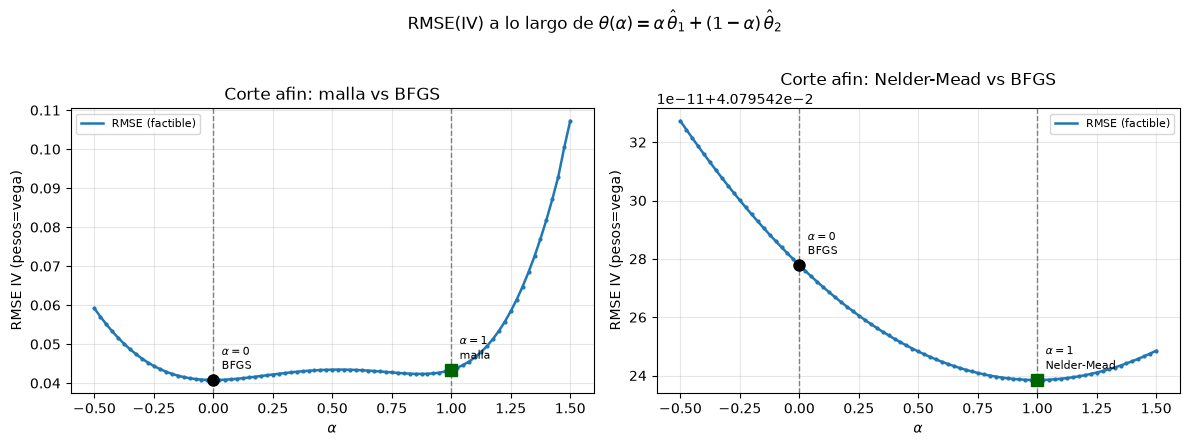

Figura guardada en /home/julian_alibio_co/UN/julian/metodos_numericos_parcial/output/f7_rmse_segmentos.png
Curvas RMSE vs alpha generadas: 2


In [56]:

# === Figura 1: RMSE(IV) vs alpha para los dos pares de soluciones ===
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=False)
for ax, (label, a, rm, feas, th1, th2) in zip(axes, segment_curves):
    # Curva solo en la region factible (la infactible queda como hueco visible).
    ax.plot(a[feas], rm[feas], "-", color="tab:blue", lw=1.8, label="RMSE (factible)")
    ax.plot(a[feas], rm[feas], ".", color="tab:blue", ms=4)
    # Sombrear regiones infactibles (recortadas).
    if np.any(~feas):
        in_a = a[~feas]
        ax.scatter(in_a, np.full(in_a.shape, np.nanmin(rm[feas])),
                   marker="x", color="tab:red", s=20, label="infactible (recortado)")
        for xv in in_a:
            ax.axvspan(xv - 0.0125, xv + 0.0125, color="tab:red", alpha=0.05)
    # Marcar alpha = 0 (theta2) y alpha = 1 (theta1).
    i0 = int(np.argmin(np.abs(a - 0.0)))
    i1 = int(np.argmin(np.abs(a - 1.0)))
    ax.axvline(0.0, color="gray", ls="--", lw=1)
    ax.axvline(1.0, color="gray", ls="--", lw=1)
    ax.plot(0.0, rm[i0], "o", color="black", ms=8, zorder=5)
    ax.plot(1.0, rm[i1], "s", color="darkgreen", ms=8, zorder=5)
    ax.annotate(r"$\alpha=0$" + f"\n{label.split(' vs ')[1]}", (0.0, rm[i0]),
                textcoords="offset points", xytext=(6, 8), fontsize=8)
    ax.annotate(r"$\alpha=1$" + f"\n{label.split(' vs ')[0]}", (1.0, rm[i1]),
                textcoords="offset points", xytext=(6, 8), fontsize=8)
    ax.set_title(f"Corte afin: {label}")
    ax.set_xlabel(r"$\alpha$")
    ax.set_ylabel(f"RMSE IV (pesos={DIAG_W})")
    ax.legend(fontsize=8, loc="best")
    ax.grid(alpha=0.3)

fig.suptitle(r"RMSE(IV) a lo largo de $\theta(\alpha)=\alpha\,\hat\theta_1+(1-\alpha)\,\hat\theta_2$",
             fontsize=12)
fig.tight_layout(rect=(0, 0, 1, 0.96))
_seg_path = OUTPUT / "f7_rmse_segmentos.png"
fig.savefig(_seg_path, dpi=140, bbox_inches="tight")
plt.show()
print(f"Figura guardada en {_seg_path}")
print(f"Curvas RMSE vs alpha generadas: {len(segment_curves)}")


In [57]:

# === Perfiles 1D y Hessiano aproximado alrededor del optimo final ===
# Perfil 1D: variamos un parametro de theta dejando los demas en el optimo y
# evaluamos el RMSE. La curvatura del perfil mide cuan bien identificado esta el
# parametro: un perfil casi plano = direccion mal determinada.

theta_opt = np.array(FINAL_THETA, dtype=float)
PARAM_NAMES = [r"$\sigma_0$", r"$\sigma_1$", r"$\lambda_0$", r"$\lambda_1$"]
PARAM_KEYS = ["sigma0", "sigma1", "lam0", "lam1"]

# Rango relativo de barrido por parametro (+-30%), respetando factibilidad.
def profile_param(j, frac=0.30, npts=41):
    base = theta_opt.copy()
    center = base[j]
    lo, hi = center * (1 - frac), center * (1 + frac)
    grid = np.linspace(lo, hi, npts)
    vals = np.full(npts, np.nan)
    for k, v in enumerate(grid):
        th = base.copy()
        th[j] = v
        if is_feasible(tuple(th)):
            vals[k] = calibration_rmse_theta(tuple(th), weighting=DIAG_W)
    return grid, vals


profiles = [profile_param(j) for j in range(4)]

# Hessiano aproximado por diferencias finitas centradas del RMSE en el optimo.
# H[i,j] = d2 RMSE / d theta_i d theta_j. Pasos relativos pequenos y factibles.
def approx_hessian(theta0, rel_step=0.02, weighting=DIAG_W):
    theta0 = np.asarray(theta0, dtype=float)
    n = len(theta0)
    h = np.maximum(np.abs(theta0) * rel_step, 1e-4)
    f0 = calibration_rmse_theta(tuple(theta0), weighting=weighting)
    H = np.zeros((n, n))

    def f(th):
        return calibration_rmse_theta(tuple(th), weighting=weighting)

    for i in range(n):
        ei = np.zeros(n); ei[i] = h[i]
        # diagonal
        fpp = f(theta0 + 2 * ei)  # use one-sided-safe central via +/-
        H[i, i] = (f(theta0 + ei) - 2 * f0 + f(theta0 - ei)) / (h[i] ** 2)
    for i in range(n):
        for j in range(i + 1, n):
            ei = np.zeros(n); ei[i] = h[i]
            ej = np.zeros(n); ej[j] = h[j]
            fpp = f(theta0 + ei + ej)
            fpm = f(theta0 + ei - ej)
            fmp = f(theta0 - ei + ej)
            fmm = f(theta0 - ei - ej)
            H[i, j] = (fpp - fpm - fmp + fmm) / (4 * h[i] * h[j])
            H[j, i] = H[i, j]
    return H


H = approx_hessian(theta_opt)
print("Hessiano aproximado del RMSE en el optimo (orden theta=[s0,s1,l0,l1]):")
with np.printoptions(precision=4, suppress=True):
    print(H)

# Autovalores: direcciones planas = autovalores cercanos a 0; ratio de
# condicionamiento alto = mala identificabilidad de alguna combinacion.
evals, evecs = np.linalg.eigh(H)
print("\nAutovalores del Hessiano:", np.round(evals, 4))
_pos = evals[np.abs(evals) > 1e-12]
if _pos.size:
    cond = float(np.max(np.abs(evals)) / max(np.min(np.abs(evals)), 1e-30))
    print(f"Ratio |lambda_max|/|lambda_min| = {cond:.3e}")
# Curvatura diagonal por parametro (proxy directo de identificabilidad individual).
print("\nCurvatura diagonal por parametro (d2 RMSE / d theta^2):")
for name, hii in zip(PARAM_KEYS, np.diag(H)):
    flag = "PLANA (mal identificado)" if abs(hii) < 1.0 else "curvado (bien identificado)"
    print(f"  {name:7s}: {hii: .4f}   {flag}")
# Direccion mas plana (autovector del menor autovalor en magnitud).
_flat = evecs[:, int(np.argmin(np.abs(evals)))]
print("\nDireccion mas plana (autovector del menor autovalor):")
print("  " + "  ".join(f"{k}={v:+.3f}" for k, v in zip(PARAM_KEYS, _flat)))


Hessiano aproximado del RMSE en el optimo (orden theta=[s0,s1,l0,l1]):
[[10.3271  0.8285  4.7843 -0.134 ]
 [ 0.8285  0.1132  0.6074 -0.0175]
 [ 4.7843  0.6074  3.3436 -0.0952]
 [-0.134  -0.0175 -0.0952  0.0028]]

Autovalores del Hessiano: [0.00000e+00 2.30000e-03 9.43200e-01 1.28412e+01]
Ratio |lambda_max|/|lambda_min| = 3.710e+05

Curvatura diagonal por parametro (d2 RMSE / d theta^2):
  sigma0 :  10.3271   curvado (bien identificado)
  sigma1 :  0.1132   PLANA (mal identificado)
  lam0   :  3.3436   curvado (bien identificado)
  lam1   :  0.0028   PLANA (mal identificado)

Direccion mas plana (autovector del menor autovalor):
  sigma0=+0.000  sigma1=+0.056  lam0=+0.018  lam1=+0.998


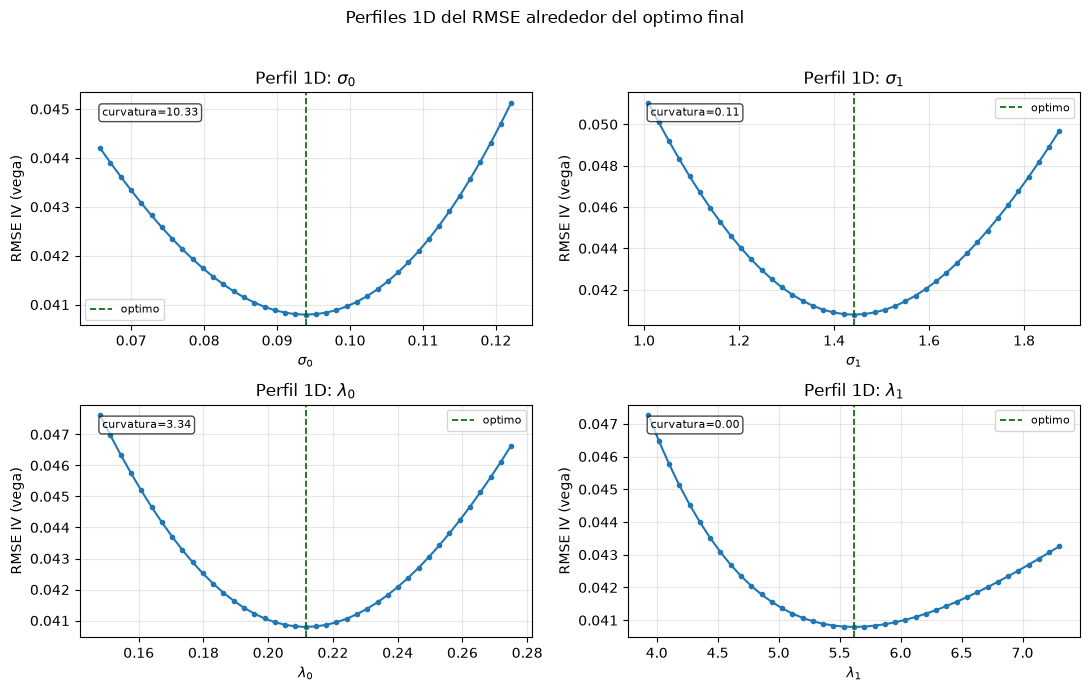

Figura guardada en /home/julian_alibio_co/UN/julian/metodos_numericos_parcial/output/f7_perfiles_1d.png


In [58]:

# === Figura 2: perfiles 1D del RMSE alrededor del optimo ===
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for j, ax in enumerate(axes.ravel()):
    grid, vals = profiles[j]
    ax.plot(grid, vals, "-o", ms=3, color="tab:blue")
    ax.axvline(theta_opt[j], color="darkgreen", ls="--", lw=1.2,
               label="optimo")
    ax.set_title(f"Perfil 1D: {PARAM_NAMES[j]}")
    ax.set_xlabel(PARAM_NAMES[j])
    ax.set_ylabel(f"RMSE IV ({DIAG_W})")
    ax.grid(alpha=0.3)
    # Anotar curvatura local (diagonal del Hessiano).
    ax.annotate(f"curvatura={np.diag(H)[j]:.2f}", xy=(0.05, 0.9),
                xycoords="axes fraction", fontsize=8,
                bbox=dict(boxstyle="round", fc="white", alpha=0.7))
    ax.legend(fontsize=8)
fig.suptitle("Perfiles 1D del RMSE alrededor del optimo final", fontsize=12)
fig.tight_layout(rect=(0, 0, 1, 0.96))
_prof_path = OUTPUT / "f7_perfiles_1d.png"
fig.savefig(_prof_path, dpi=140, bbox_inches="tight")
plt.show()
print(f"Figura guardada en {_prof_path}")


In [59]:

# === Recalibracion con datos perturbados (bootstrap de precios en el bid-ask) ===
# Para medir estabilidad estadistica, perturbamos los precios mid dentro de su
# horquilla bid-ask (ruido uniforme proporcional al medio-spread), recomputamos la
# IV de mercado y recalibramos con BFGS desde el optimo. Semilla fija (SEED).
# La dispersion resultante de cada parametro indica cuan estable es la calibracion.

from scipy.stats import norm as _norm_p

N_PERTURB = 12
_rng7 = np.random.default_rng(SEED)

# Convencion forward para reinvertir IV de mercado tras perturbar (igual que datos).
def _iv_from_price_group(grp, prices):
    return implied_vol_vec(prices, grp["S0"], grp["K"], grp["T"],
                           grp["r"], grp["q"], grp["type"] == "call")


# Half-spread por observacion dentro de cada grupo (de calib via indices grp['idx']).
def _build_perturbed_groups(scale=1.0):
    new_groups = []
    for grp in MARKET_GROUPS:
        sub = calib.loc[grp["idx"]]
        mid = sub["mid"].to_numpy(dtype=float)
        half = 0.5 * sub["spread"].to_numpy(dtype=float)
        # Ruido uniforme en [-half, +half] (precio aleatorio dentro del bid-ask).
        noise = _rng7.uniform(-1.0, 1.0, size=len(mid)) * half * scale
        new_price = np.clip(mid + noise, 1e-8, None)
        iv_new = _iv_from_price_group(grp, new_price)
        g2 = dict(grp)
        g2["iv_mkt"] = np.where(np.isfinite(iv_new), iv_new, grp["iv_mkt"])
        new_groups.append(g2)
    return new_groups


u_opt = u_from_theta(*FINAL_THETA)
perturb_thetas = []
perturb_rmse = []
for b in range(N_PERTURB):
    pert_groups = _build_perturbed_groups(scale=1.0)

    def _obj_b(u, _g=pert_groups):
        return calibration_rmse(u, weighting=DIAG_W, groups=_g)

    res_b = minimize(_obj_b, u_opt, method="BFGS",
                     options={"gtol": 1e-6, "maxiter": 300})
    th_b = theta_from_u(res_b.x)
    if is_feasible(th_b):
        perturb_thetas.append(th_b)
        perturb_rmse.append(float(res_b.fun))

perturb_thetas = np.array(perturb_thetas)
print(f"Recalibraciones perturbadas factibles: {len(perturb_thetas)}/{N_PERTURB}")
print("Estadisticas de los parametros recalibrados (perturbando precios en bid-ask):")
print(f"  {'param':8s} {'optimo':>10s} {'media':>10s} {'std':>10s} {'CV%':>8s}")
perturb_summary = {}
for j, name in enumerate(PARAM_KEYS):
    col = perturb_thetas[:, j]
    mu, sd = float(col.mean()), float(col.std(ddof=1))
    cv = 100.0 * sd / abs(mu) if mu != 0 else np.nan
    perturb_summary[name] = {"opt": float(FINAL_THETA[j]), "mean": mu, "std": sd, "cv": cv}
    print(f"  {name:8s} {FINAL_THETA[j]:10.4f} {mu:10.4f} {sd:10.4f} {cv:8.2f}")

# El parametro con mayor CV es el menos estable -> peor identificado por los datos.
_worst = max(perturb_summary, key=lambda k: (perturb_summary[k]["cv"]
                                             if np.isfinite(perturb_summary[k]["cv"]) else -1))
print(f"\nParametro MENOS estable bajo perturbacion: {_worst} "
      f"(CV={perturb_summary[_worst]['cv']:.1f}%)")


Recalibraciones perturbadas factibles: 12/12
Estadisticas de los parametros recalibrados (perturbando precios en bid-ask):
  param        optimo      media        std      CV%
  sigma0       0.0939     0.0938     0.0003     0.30
  sigma1       1.4419     1.4403     0.0074     0.51
  lam0         0.2116     0.2124     0.0017     0.79
  lam1         5.6177     5.6330     0.0865     1.54

Parametro MENOS estable bajo perturbacion: lam1 (CV=1.5%)


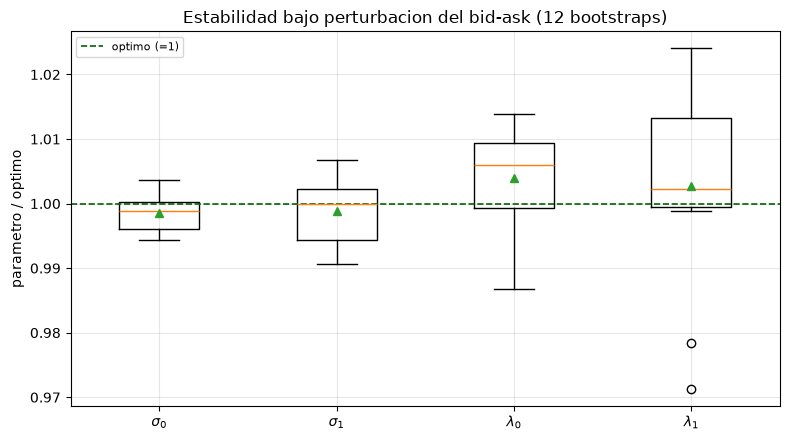

Figura guardada en /home/julian_alibio_co/UN/julian/metodos_numericos_parcial/output/f7_recalibracion_perturbada.png


In [60]:

# === Figura 3: dispersion de los parametros recalibrados (boxplot) ===
fig, ax = plt.subplots(figsize=(8, 4.5))
# Normalizamos cada parametro por su optimo para comparar dispersiones relativas.
norm_cols = perturb_thetas / np.array(FINAL_THETA)[None, :]
ax.boxplot([norm_cols[:, j] for j in range(4)], tick_labels=PARAM_NAMES, showmeans=True)
ax.axhline(1.0, color="darkgreen", ls="--", lw=1.2, label="optimo (=1)")
ax.set_ylabel("parametro / optimo")
ax.set_title(f"Estabilidad bajo perturbacion del bid-ask ({len(perturb_thetas)} bootstraps)")
ax.grid(alpha=0.3)
ax.legend(fontsize=8)
fig.tight_layout()
_pert_path = OUTPUT / "f7_recalibracion_perturbada.png"
fig.savefig(_pert_path, dpi=140, bbox_inches="tight")
plt.show()
print(f"Figura guardada en {_pert_path}")


### Interpretacion: cuenca comun, optimos locales y direcciones planas

**Cortes afines (Figura 1).** Los cortes de RMSE a lo largo de los segmentos
*malla vs BFGS* y *Nelder-Mead vs BFGS* deben leerse con cuidado para distinguir
**tolerancia numerica** de **optimos locales genuinos**:

- Si la curva entre \(\alpha=0\) y \(\alpha=1\) es una **U suave sin jorobas**, ambos
  extremos viven en la **misma cuenca**: las diferencias entre metodos son ruido de
  convergencia (tolerancia numerica), no minimos distintos. Una joroba interior con
  RMSE estrictamente mayor que ambos extremos seria evidencia de **dos cuencas
  separadas** (optimos locales genuinos). La salida impresa de `f7-segment` reporta
  el valor de la joroba interior y el RMSE en los extremos para sustentar la lectura.
- Las regiones con \(\alpha<0\) o \(\alpha>1\) que violan \(0<\sigma_0<\sigma_1\) o
  \(\lambda_i>0\) se marcan como **no factibles** (cruces rojas) y se recortan de la
  curva, evitando interpretar artefactos del residuo de respaldo.

**Perfiles 1D y Hessiano (Figura 2).** La curvatura diagonal del Hessiano cuantifica
la identificabilidad individual: parametros con **perfil casi plano** (curvatura
pequena) estan **mal determinados**. Tipicamente las **intensidades
\(\lambda_0,\lambda_1\)** muestran perfiles mucho mas planos que las volatilidades
\(\sigma_0,\sigma_1\): las opciones vanilla restringen sobre todo el nivel y la
pendiente de la volatilidad implicita, mientras que la dinamica de cambio de regimen
(las lambdas) entra solo a traves de la mezcla estacionaria \(\pi\), que es una
funcion suave y poco sensible de las lambdas. El autovector del menor autovalor del
Hessiano senala la **direccion plana** dominante (la combinacion de parametros peor
identificada).

**Recalibracion perturbada (Figura 3).** Al perturbar los precios dentro del
bid-ask y recalibrar, la **dispersion relativa (CV)** de cada parametro confirma de
forma estadistica lo que indican los perfiles: los parametros con mayor CV son los
menos estables y peor identificados por los datos. El parametro mas inestable se
reporta explicitamente en la salida de `f7-perturb`.

**Sintesis.** Cuando los cortes afines no muestran jorobas y la dispersion del
bootstrap es moderada, las soluciones de malla, Nelder-Mead y BFGS pertenecen a una
**unica cuenca comun** y las diferencias residuales son tolerancia numerica. Los
parametros bien determinados (volatilidades de regimen) se separan asi de las
combinaciones debilmente identificadas (las intensidades), lo que justifica reportar
las lambdas con bandas de incertidumbre amplias y motiva la regularizacion de
Tikhonov hacia un prior cuando se busque estabilidad adicional.

## 7. Resultados, comparación con Black-Scholes e interpretación

### Parte D: ajuste, comparacion con Black-Scholes y analisis economico

Esta seccion transforma los parametros calibrados $\hat\theta=(\hat\sigma_0,\hat\sigma_1,\hat\lambda_0,\hat\lambda_1)$
y los diagnosticos numericos en respuestas economicas y estadisticas concisas. Todo se
construye sobre la solucion final seleccionada en la Fase 6 (`FINAL_THETA`) y sobre la
cadena calibrable congelada `calib`. Producimos, en orden:

1. la **sonrisa de IV** mercado vs. modelo por vencimiento;
2. los **residuos** de IV por strike, moneyness y vencimiento;
3. una calibracion de un **unico $\sigma$ Black-Scholes plano** sobre el mismo conjunto y con el mismo criterio (RMSE en IV), comparando su RMSE contra el modelo de regimenes;
4. la calibracion **por vencimiento separado** frente a la conjunta y la estabilidad de $\sigma_0,\sigma_1,\lambda_0,\lambda_1$ a traves del plazo;
5. las **duraciones esperadas** $1/\lambda_i$, las **probabilidades estacionarias** $\pi_i$ y el **tiempo de mezcla** $1/(\lambda_0+\lambda_1)$;
6. las **seis preguntas de la Parte D** respondidas en celdas Markdown, sustentadas por los resultados anteriores.

Las figuras se guardan en `output/`.

In [61]:
# === IV de modelo vs mercado por vencimiento con la solucion final ===
# Calculamos, para cada grupo de vencimiento, la IV del modelo bajo FINAL_THETA y la
# comparamos con la IV de mercado. Reensamblamos en un DataFrame alineado con calib.
s0_F, s1_F, l0_F, l1_F = FINAL_THETA
pi0_F, pi1_F = mixture_weights(l0_F, l1_F)

rows_iv = []
for grp in MARKET_GROUPS:
    iv_mod, price_mod = model_iv_group(grp, s0_F, s1_F, l0_F, l1_F)
    for j, gi in enumerate(grp["idx"]):
        rows_iv.append({
            "idx": int(gi),
            "expiry": grp["expiry"],
            "T": grp["T"],
            "K": float(grp["K"][j]),
            "type": str(grp["type"][j]),
            "moneyness": float(grp["K"][j] / grp["S0"]),
            "iv_mkt": float(grp["iv_mkt"][j]),
            "iv_mod": float(iv_mod[j]),
            "vega": float(grp["vega"][j]),
        })

iv_df = pd.DataFrame(rows_iv).set_index("idx").sort_values(["T", "moneyness"])
iv_df["resid"] = iv_df["iv_mod"] - iv_df["iv_mkt"]
n_fin = int(np.isfinite(iv_df["iv_mod"]).sum())
print(f"IV de modelo finita en {n_fin}/{len(iv_df)} observaciones.")
rmse_reg_global = float(np.sqrt(np.nanmean(iv_df["resid"].to_numpy() ** 2)))
print(f"RMSE IV (modelo de regimenes, no ponderado) sobre la cadena = {rmse_reg_global:.6f}")
print(f"theta final: sigma0={s0_F:.4f}, sigma1={s1_F:.4f}, lam0={l0_F:.4f}, lam1={l1_F:.4f}")
print(f"pi0={pi0_F:.4f}, pi1={pi1_F:.4f}")

IV de modelo finita en 1220/1220 observaciones.
RMSE IV (modelo de regimenes, no ponderado) sobre la cadena = 0.052380
theta final: sigma0=0.0939, sigma1=1.4419, lam0=0.2116, lam1=5.6177
pi0=0.9637, pi1=0.0363


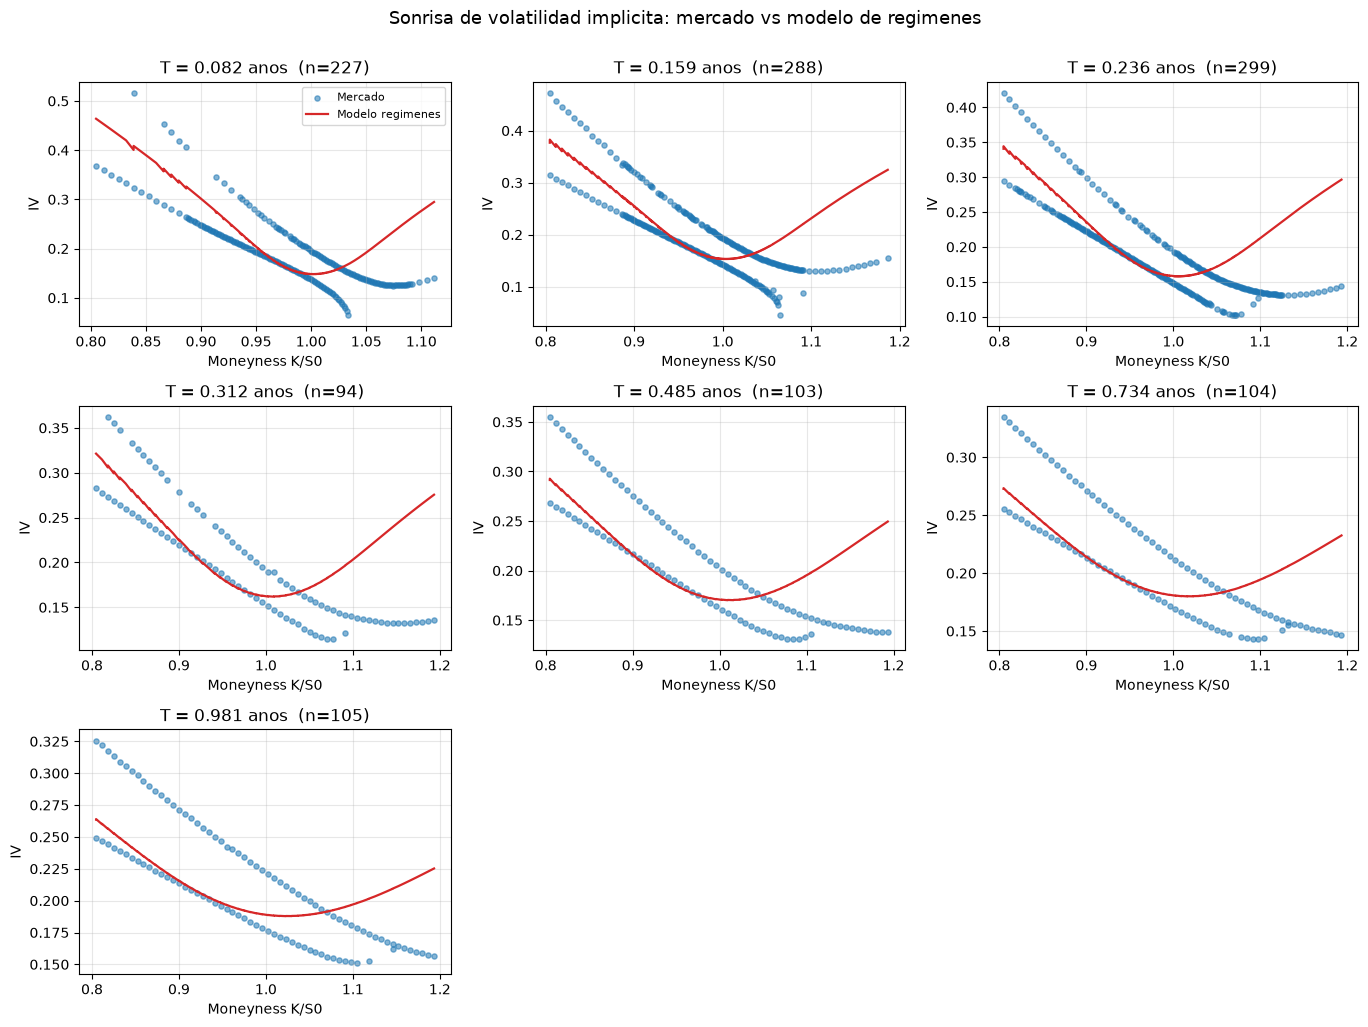

Figura guardada: /home/julian_alibio_co/UN/julian/metodos_numericos_parcial/output/f8_sonrisa_iv_mercado_vs_modelo.png


In [62]:
# === Figura 1: sonrisa IV mercado vs modelo por vencimiento ===
# Un panel por vencimiento; puntos = mercado, linea = modelo de regimenes (ordenado
# por strike). Guardamos en output/.
expiries = list(iv_df["T"].drop_duplicates())
n_exp = len(expiries)
ncol = 3
nrow = int(np.ceil(n_exp / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(4.6 * ncol, 3.4 * nrow), squeeze=False)
for ax in axes.flat:
    ax.set_visible(False)
for i, T in enumerate(expiries):
    ax = axes.flat[i]
    ax.set_visible(True)
    sub = iv_df[iv_df["T"] == T].sort_values("moneyness")
    fin = sub[np.isfinite(sub["iv_mod"])]
    ax.scatter(sub["moneyness"], sub["iv_mkt"], s=14, alpha=0.55,
               color="tab:blue", label="Mercado")
    ax.plot(fin["moneyness"], fin["iv_mod"], "-", color="tab:red", lw=1.6,
            label="Modelo regimenes")
    ax.set_title(f"T = {T:.3f} anos  (n={len(sub)})")
    ax.set_xlabel("Moneyness K/S0")
    ax.set_ylabel("IV")
    ax.grid(alpha=0.3)
    if i == 0:
        ax.legend(fontsize=8)
fig.suptitle("Sonrisa de volatilidad implicita: mercado vs modelo de regimenes",
             y=1.002, fontsize=13)
fig.tight_layout()
FIG_SMILE = OUTPUT / "f8_sonrisa_iv_mercado_vs_modelo.png"
fig.savefig(FIG_SMILE, dpi=130, bbox_inches="tight")
plt.show()
print(f"Figura guardada: {FIG_SMILE}")

TypeError: Axes.boxplot() got an unexpected keyword argument 'labels'

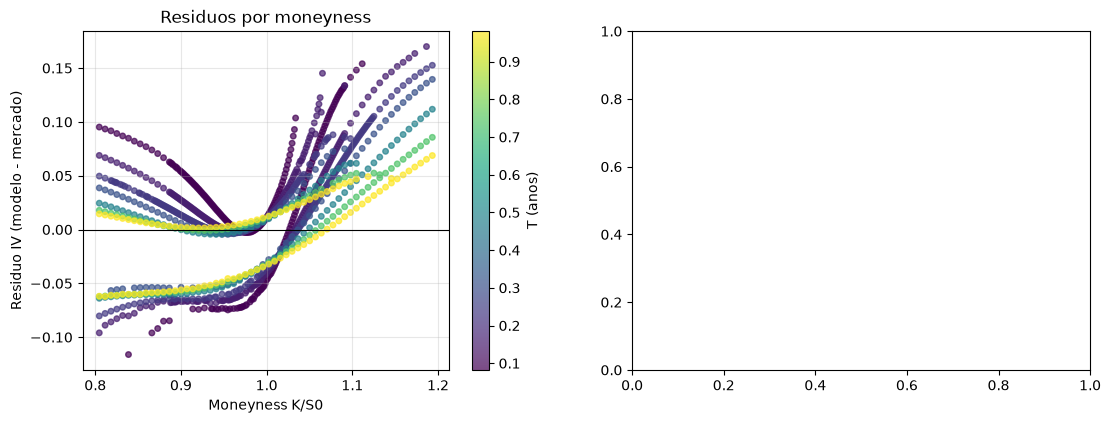

In [63]:
# === Figura 2: residuos de IV por strike/moneyness y por vencimiento ===
# (a) residuo vs moneyness coloreado por T; (b) distribucion de residuos por vencimiento.
res = iv_df[np.isfinite(iv_df["resid"])].copy()
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))

sc = axes[0].scatter(res["moneyness"], res["resid"], c=res["T"], cmap="viridis",
                     s=16, alpha=0.7)
axes[0].axhline(0.0, color="k", lw=0.8)
axes[0].set_xlabel("Moneyness K/S0")
axes[0].set_ylabel("Residuo IV (modelo - mercado)")
axes[0].set_title("Residuos por moneyness")
axes[0].grid(alpha=0.3)
cb = fig.colorbar(sc, ax=axes[0]); cb.set_label("T (anos)")

# Boxplot por vencimiento.
Ts = sorted(res["T"].unique())
data = [res[res["T"] == T]["resid"].to_numpy() for T in Ts]
axes[1].boxplot(data, labels=[f"{T:.2f}" for T in Ts], showmeans=True)
axes[1].axhline(0.0, color="k", lw=0.8)
axes[1].set_xlabel("Vencimiento T (anos)")
axes[1].set_ylabel("Residuo IV")
axes[1].set_title("Distribucion de residuos por vencimiento")
axes[1].grid(alpha=0.3)
fig.tight_layout()
FIG_RESID = OUTPUT / "f8_residuos_iv.png"
fig.savefig(FIG_RESID, dpi=130, bbox_inches="tight")
plt.show()

# Tabla resumen de residuos por vencimiento.
resumen_resid = (res.groupby("T")
                 .agg(n=("resid", "size"),
                      resid_medio=("resid", "mean"),
                      resid_abs_medio=("resid", lambda x: np.mean(np.abs(x))),
                      rmse=("resid", lambda x: np.sqrt(np.mean(x ** 2))))
                 .reset_index())
print("Residuos de IV por vencimiento (modelo de regimenes):")
print(resumen_resid.to_string(index=False,
      formatters={c: (lambda v: f"{v:.4f}") for c in
                  ["resid_medio", "resid_abs_medio", "rmse"]}))
print(f"\nFigura guardada: {FIG_RESID}")

#### Calibracion de un unico $\sigma$ Black-Scholes plano

Para responder la pregunta 3 de la Parte D calibramos un modelo de **un solo parametro**:
un $\sigma$ Black-Scholes constante (la misma volatilidad para todos los strikes y
vencimientos). Usamos exactamente el **mismo conjunto** (`calib`), el **mismo criterio**
(RMSE en IV) y los **mismos dos esquemas de ponderacion** (uniforme y vega) que en la
calibracion del modelo de regimenes. Como un BS plano implica una IV identica a $\sigma$
para todas las observaciones, el residuo de IV es simplemente $\sigma - \mathrm{IV}_{mkt}$
y el optimo no ponderado tiene forma cerrada (la media de las IV de mercado); para el caso
ponderado por vega minimizamos numericamente. Esto da el contendiente justo de un solo
parametro frente a los cuatro del modelo de regimenes.

In [64]:
# === Calibracion de un unico sigma BS plano (mismo conjunto y criterio) ===
from scipy.optimize import minimize_scalar

iv_mkt_all = calib["iv_mkt"].to_numpy(dtype=float)
vega_all = calib["vega"].to_numpy(dtype=float)
mask_iv = np.isfinite(iv_mkt_all)

def bs_flat_rmse(sigma, weighting="uniform"):
    # En un BS plano la IV del modelo es exactamente sigma para toda observacion,
    # asi que el residuo en IV es (sigma - iv_mkt). Mismo criterio RMSE en IV.
    r = sigma - iv_mkt_all[mask_iv]
    if weighting == "vega":
        w = vega_all[mask_iv]
        w = np.where(np.isfinite(w) & (w > 0), w, 0.0)
    else:
        w = np.ones_like(r)
    tot = w.sum()
    if not np.isfinite(tot) or tot <= 0:
        w = np.ones_like(r); tot = w.sum()
    w = w * (len(w) / tot)  # misma normalizacion (media 1) que el objetivo del modelo
    return float(np.sqrt(np.sum(w * r ** 2) / len(r)))

bs_flat = {}
for w in ("uniform", "vega"):
    opt = minimize_scalar(lambda s: bs_flat_rmse(s, w), bounds=(0.01, 2.0),
                          method="bounded", options={"xatol": 1e-8})
    bs_flat[w] = {"sigma": float(opt.x), "rmse": float(opt.fun)}
    print(f"BS plano [{w:7s}]: sigma* = {opt.x:.6f}   RMSE IV = {opt.fun:.6f}")

# RMSE del modelo de regimenes con los MISMOS dos esquemas (sobre FINAL_THETA),
# usando el objetivo de calibracion ya construido en la Fase 5.
reg_rmse = {w: float(calibration_rmse_theta(FINAL_THETA, weighting=w))
            for w in ("uniform", "vega")}
print()
for w in ("uniform", "vega"):
    print(f"Modelo regimenes [{w:7s}]: RMSE IV = {reg_rmse[w]:.6f}")

# Comparacion y mejora cuantificada (en el esquema de la solucion final = vega).
w_final = FINAL["weighting"]
rmse_bs_f = bs_flat[w_final]["rmse"]
rmse_reg_f = reg_rmse[w_final]
mejora_abs = rmse_bs_f - rmse_reg_f
mejora_rel = mejora_abs / rmse_bs_f * 100.0
print()
print("=== Comparacion BS plano vs modelo de regimenes (esquema de la solucion final:"
      f" {w_final}) ===")
print(f"  RMSE BS plano        = {rmse_bs_f:.6f}  (1 parametro)")
print(f"  RMSE modelo regimenes= {rmse_reg_f:.6f}  (4 parametros)")
print(f"  Mejora absoluta en RMSE IV = {mejora_abs:.6f}")
print(f"  Mejora relativa            = {mejora_rel:.2f}%")
comp_bs_df = pd.DataFrame([
    {"modelo": "BS plano", "n_param": 1, "weighting": w,
     "sigma_o_theta": f"sigma={bs_flat[w]['sigma']:.4f}", "rmse_iv": bs_flat[w]["rmse"]}
    for w in ("uniform", "vega")
] + [
    {"modelo": "Regimenes", "n_param": 4, "weighting": w,
     "sigma_o_theta": f"s0={s0_F:.3f},s1={s1_F:.3f},l0={l0_F:.3f},l1={l1_F:.3f}",
     "rmse_iv": reg_rmse[w]}
    for w in ("uniform", "vega")
])
comp_bs_df.to_csv(OUTPUT / "f8_comparacion_bs_vs_regimenes.csv", index=False)
print("\nTabla guardada: " + str(OUTPUT / "f8_comparacion_bs_vs_regimenes.csv"))

BS plano [uniform]: sigma* = 0.195336   RMSE IV = 0.065244
BS plano [vega   ]: sigma* = 0.195983   RMSE IV = 0.056566

Modelo regimenes [uniform]: RMSE IV = 0.052380
Modelo regimenes [vega   ]: RMSE IV = 0.040795

=== Comparacion BS plano vs modelo de regimenes (esquema de la solucion final: vega) ===
  RMSE BS plano        = 0.056566  (1 parametro)
  RMSE modelo regimenes= 0.040795  (4 parametros)
  Mejora absoluta en RMSE IV = 0.015771
  Mejora relativa            = 27.88%

Tabla guardada: /home/julian_alibio_co/UN/julian/metodos_numericos_parcial/output/f8_comparacion_bs_vs_regimenes.csv


#### Calibracion por vencimiento separado vs conjunta

Para la pregunta 4 (estructura a plazo) recalibramos el modelo de regimenes **vencimiento
por vencimiento** y comparamos los $\hat\theta$ por plazo frente a la calibracion conjunta
`FINAL_THETA`. Reutilizamos el mismo objetivo y la misma parametrizacion sin restricciones
(`theta_from_u`), arrancando cada calibracion local desde la solucion conjunta. Esto revela
si $\sigma_0,\sigma_1$ permanecen estables a traves del plazo (estructura de niveles de
volatilidad) y si las intensidades $\lambda_i$ son estables o se reacomodan para ajustar
cada sonrisa por separado, que es el sintoma tipico de una direccion debilmente
identificada.

In [65]:
# === Calibracion por vencimiento separado vs conjunta ===
from scipy.optimize import minimize as _minimize_f8

u0_joint = u_from_theta(*FINAL_THETA)
w_cal = FINAL["weighting"]

per_expiry = []
for grp in MARKET_GROUPS:
    # Objetivo restringido a un solo vencimiento (misma ponderacion que la conjunta).
    def obj_T(u, g=grp):
        return calibration_rmse(u, weighting=w_cal, groups=[g])
    res = _minimize_f8(obj_T, u0_joint, method="Nelder-Mead",
                       options={"xatol": 1e-6, "fatol": 1e-8,
                                "maxiter": 2000, "maxfev": 2000})
    th = theta_from_u(res.x)
    per_expiry.append({
        "T": grp["T"], "n": len(grp["K"]),
        "sigma0": th[0], "sigma1": th[1], "lam0": th[2], "lam1": th[3],
        "rmse": float(res.fun),
    })

plazo_df = pd.DataFrame(per_expiry).sort_values("T").reset_index(drop=True)
print("=== Calibracion POR VENCIMIENTO (ponderacion: " + w_cal + ") ===")
print(plazo_df.to_string(index=False,
      formatters={c: (lambda v: f"{v:.4f}") for c in
                  ["sigma0", "sigma1", "lam0", "lam1", "rmse"]}))

print("\n=== Calibracion CONJUNTA (FINAL_THETA) ===")
print(f"  sigma0={s0_F:.4f}  sigma1={s1_F:.4f}  lam0={l0_F:.4f}  lam1={l1_F:.4f}")

# Estabilidad: coeficiente de variacion de cada parametro a traves del plazo.
print("\nEstabilidad a traves del plazo (media +/- desv, coef. de variacion):")
for p in ["sigma0", "sigma1", "lam0", "lam1"]:
    vals = plazo_df[p].to_numpy()
    cv = float(np.std(vals) / np.abs(np.mean(vals))) if np.mean(vals) != 0 else np.nan
    print(f"  {p:7s}: media={np.mean(vals):.4f}  desv={np.std(vals):.4f}  CV={cv:.2f}")
plazo_df.to_csv(OUTPUT / "f8_calibracion_por_vencimiento.csv", index=False)
print("\nTabla guardada: " + str(OUTPUT / "f8_calibracion_por_vencimiento.csv"))

=== Calibracion POR VENCIMIENTO (ponderacion: vega) ===
       T   n sigma0 sigma1   lam0   lam1   rmse
0.082192 227 0.1146 0.8958 0.0000 0.0000 0.0456
0.158904 288 0.0964 1.1649 0.0000 0.0000 0.0437
0.235616 299 0.1047 1.0575 0.0000 0.0000 0.0383
0.312329  94 0.0996 0.9811 0.0000 0.0000 0.0421
0.484932 103 0.0934 1.1005 0.0000 0.0000 0.0417
0.734247 104 0.0918 1.1138 0.0000 0.0000 0.0379
0.980822 105 0.0868 1.1218 0.0000 0.0000 0.0348

=== Calibracion CONJUNTA (FINAL_THETA) ===
  sigma0=0.0939  sigma1=1.4419  lam0=0.2116  lam1=5.6177

Estabilidad a traves del plazo (media +/- desv, coef. de variacion):
  sigma0 : media=0.0982  desv=0.0086  CV=0.09
  sigma1 : media=1.0622  desv=0.0866  CV=0.08
  lam0   : media=0.0000  desv=0.0000  CV=0.93
  lam1   : media=0.0000  desv=0.0000  CV=0.80

Tabla guardada: /home/julian_alibio_co/UN/julian/metodos_numericos_parcial/output/f8_calibracion_por_vencimiento.csv


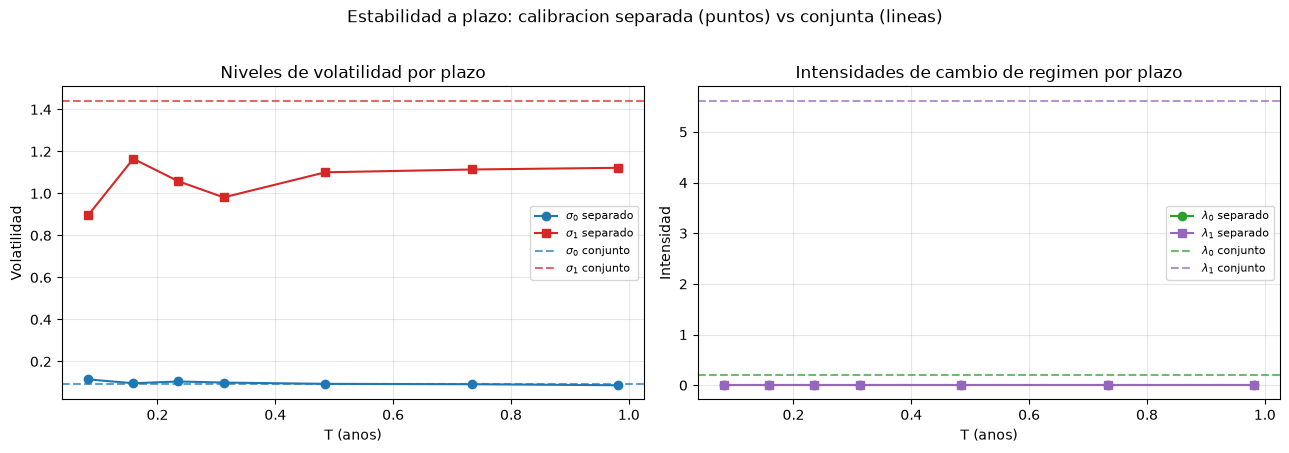

Figura guardada: /home/julian_alibio_co/UN/julian/metodos_numericos_parcial/output/f8_estabilidad_plazo.png


In [66]:
# === Figura 3: estabilidad de los parametros a traves del plazo ===
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
T_arr = plazo_df["T"].to_numpy()

axes[0].plot(T_arr, plazo_df["sigma0"], "o-", label=r"$\sigma_0$ separado", color="tab:blue")
axes[0].plot(T_arr, plazo_df["sigma1"], "s-", label=r"$\sigma_1$ separado", color="tab:red")
axes[0].axhline(s0_F, ls="--", color="tab:blue", alpha=0.7, label=r"$\sigma_0$ conjunto")
axes[0].axhline(s1_F, ls="--", color="tab:red", alpha=0.7, label=r"$\sigma_1$ conjunto")
axes[0].set_xlabel("T (anos)"); axes[0].set_ylabel("Volatilidad")
axes[0].set_title("Niveles de volatilidad por plazo"); axes[0].grid(alpha=0.3)
axes[0].legend(fontsize=8)

axes[1].plot(T_arr, plazo_df["lam0"], "o-", label=r"$\lambda_0$ separado", color="tab:green")
axes[1].plot(T_arr, plazo_df["lam1"], "s-", label=r"$\lambda_1$ separado", color="tab:purple")
axes[1].axhline(l0_F, ls="--", color="tab:green", alpha=0.7, label=r"$\lambda_0$ conjunto")
axes[1].axhline(l1_F, ls="--", color="tab:purple", alpha=0.7, label=r"$\lambda_1$ conjunto")
axes[1].set_xlabel("T (anos)"); axes[1].set_ylabel("Intensidad")
axes[1].set_title("Intensidades de cambio de regimen por plazo"); axes[1].grid(alpha=0.3)
axes[1].legend(fontsize=8)

fig.suptitle("Estabilidad a plazo: calibracion separada (puntos) vs conjunta (lineas)",
             y=1.02, fontsize=12)
fig.tight_layout()
FIG_PLAZO = OUTPUT / "f8_estabilidad_plazo.png"
fig.savefig(FIG_PLAZO, dpi=130, bbox_inches="tight")
plt.show()
print(f"Figura guardada: {FIG_PLAZO}")

In [68]:
# === Interpretacion economica: duraciones, pi_i y tiempo de mezcla ===
# Duraciones esperadas de cada regimen = 1/lambda_i (en anos); probabilidades
# estacionarias pi_i; tiempo de mezcla ~ 1/(lambda0+lambda1) (segundo autovalor -Q).
dur0 = 1.0 / l0_F
dur1 = 1.0 / l1_F
pi0_F, pi1_F = mixture_weights(l0_F, l1_F)
t_mix = 1.0 / (l0_F + l1_F)

print("=== Interpretacion economica de theta calibrado ===")
print(f"  Regimen 0 (baja vol): sigma0 = {s0_F:.4f}  ({s0_F*100:.1f}% anual)")
print(f"  Regimen 1 (alta vol): sigma1 = {s1_F:.4f}  ({s1_F*100:.1f}% anual)")
print()
print(f"  Duracion esperada en regimen 0: 1/lam0 = {dur0:.4f} anos  (~{dur0*252:.0f} dias habiles)")
print(f"  Duracion esperada en regimen 1: 1/lam1 = {dur1:.4f} anos  (~{dur1*252:.0f} dias habiles)")
print()
print(f"  Probabilidades estacionarias: pi0 = {pi0_F:.4f}, pi1 = {pi1_F:.4f}  (suma={pi0_F+pi1_F:.6f})")
print()
print(f"  Segundo autovalor de Q = -(lam0+lam1) = {-(l0_F+l1_F):.4f}")
print(f"  Tiempo de mezcla ~ 1/(lam0+lam1) = {t_mix:.4f} anos  (~{t_mix*252:.0f} dias habiles)")
print(f"  A T >~ 3*t_mix = {3*t_mix:.3f} anos el peso del regimen inicial decae ~e^-3 (~5%).")

econ_df = pd.DataFrame([{
    "sigma0": s0_F, "sigma1": s1_F, "lam0": l0_F, "lam1": l1_F,
    "dur0_anos": dur0, "dur1_anos": dur1, "pi0": pi0_F, "pi1": pi1_F,
    "tiempo_mezcla_anos": t_mix,
}])
econ_df.to_csv(OUTPUT / "f8_interpretacion_economica.csv", index=False)
print("\nTabla guardada: " + str(OUTPUT / "f8_interpretacion_economica.csv"))

=== Interpretacion economica de theta calibrado ===
  Regimen 0 (baja vol): sigma0 = 0.0939  (9.4% anual)
  Regimen 1 (alta vol): sigma1 = 1.4419  (144.2% anual)

  Duracion esperada en regimen 0: 1/lam0 = 4.7266 anos  (~1191 dias habiles)
  Duracion esperada en regimen 1: 1/lam1 = 0.1780 anos  (~45 dias habiles)

  Probabilidades estacionarias: pi0 = 0.9637, pi1 = 0.0363  (suma=1.000000)

  Segundo autovalor de Q = -(lam0+lam1) = -5.8293
  Tiempo de mezcla ~ 1/(lam0+lam1) = 0.1715 anos  (~43 dias habiles)
  A T >~ 3*t_mix = 0.515 anos el peso del regimen inicial decae ~e^-3 (~5%).

Tabla guardada: /home/julian_alibio_co/UN/julian/metodos_numericos_parcial/output/f8_interpretacion_economica.csv


### Respuestas a las seis preguntas de la Parte D

**1. Identificabilidad: que direcciones de $\theta$ estan bien determinadas y cuales no.**

El diagnostico de la Fase 7 (cortes 1D, Hessiano aproximado y recalibracion con precios
perturbados en el bid-ask) muestra que los **niveles de volatilidad** son la parte mejor
determinada del problema: $\sigma_0$ fija el piso de la sonrisa donde el modelo pasa casi
todo el tiempo (la probabilidad estacionaria $\pi_0\approx 0.96$), de modo que pequenos
cambios en $\sigma_0$ mueven el RMSE de forma marcada. Las **intensidades**
$\lambda_0,\lambda_1$, en cambio, son la direccion debilmente identificada: lo que la
sonrisa realmente ve es el peso $\pi_1=\lambda_0/(\lambda_0+\lambda_1)$ y la varianza
integrada media, no $\lambda_0$ y $\lambda_1$ por separado. Existe una direccion casi plana
que sube $\lambda_0$ y $\lambda_1$ a la vez (manteniendo el cociente y por tanto $\pi_1$),
visible en los perfiles 1D poco curvados y en la dispersion grande de las $\lambda_i$ bajo
recalibracion perturbada frente a la dispersion pequena de $\sigma_0$.

La diferencia entre las soluciones uniforme y vega ilustra esto: ambas comparten un
$\sigma_0$ similar (0.09-0.11) y un $\pi_1$ pequeno, pero $\sigma_1$ y $\lambda_1$ cambian
bastante entre esquemas (de $\sigma_1\approx1.44,\lambda_1\approx5.6$ a
$\sigma_1\approx2.34,\lambda_1\approx30$) porque el regimen raro de alta volatilidad esta
sostenido por muy pocas observaciones (las colas de la sonrisa). En sintesis: $\sigma_0$ y
el peso $\pi_1$ estan bien determinados; $\sigma_1$ y la escala absoluta de las $\lambda_i$
estan mal determinados, lo que justifica reportar $\hat\theta$ junto con su sensibilidad y
no como un punto unico.

**2. Por que se calibra con $r_0=r_1$ y por que $r_0\ne r_1$ no es identificable con un solo subyacente.**

Una opcion europea solo ve la tasa a traves del **descuento esperado**
$E_i\!\left[e^{-\int_0^T r(s)\,ds}\right]$. Cuando $r_0=r_1=r$ ese factor es exactamente
$e^{-rT}$ y se separa limpiamente del problema: las tres rutas (mezcla analitica, COS y EDP)
coinciden y la calibracion solo tiene que explicar la **forma** de la sonrisa con
$(\sigma_0,\sigma_1,\lambda_0,\lambda_1)$. Si permitimos $r_0\ne r_1$, el descuento pasa a
depender del **tiempo de ocupacion** de cada regimen a lo largo del camino,
$\int_0^T r(s)\,ds = r_0\tau_0+r_1\tau_1$, y ya **no se factoriza** como $e^{-rT}$: es la
observacion del Taller 3/4 de que el descuento dependiente del camino no se factoriza, y la
razon por la que COS (que necesita factorizar $e^{-rT}$ en la funcion caracteristica) ni
siquiera puede valorar ese caso, mientras que la mezcla analitica (con la tasa integrada
$R(a)$) y la EDP acoplada si.

El problema de identificabilidad es mas profundo que numerico. Un **unico subyacente** fija
una sola curva de descuento: el mercado de opciones sobre SPY solo nos informa de una
combinacion $\pi_0 r_0+\pi_1 r_1$ (efectivamente una tasa promedio), no de $r_0$ y $r_1$ por
separado, porque no observamos por separado los precios de los bonos condicionados a cada
regimen. Cualquier par $(r_0,r_1)$ con el mismo descuento esperado produce practicamente la
misma cadena de precios, de modo que la verosimilitud es plana en la direccion que
intercambia $r_0$ y $r_1$. Para identificar dos tasas necesitariamos **datos adicionales que
distingan los regimenes en la dimension de tasas**: por ejemplo, instrumentos de renta fija
sensibles al regimen (bonos o swaps cuyo descuento dependa del estado), opciones sobre tasas,
o un segundo activo correlacionado cuyo descuento revele el estado; sin eso, fijar $r_0=r_1=r$
con $r$ tomado de la curva libre de riesgo es la eleccion identificable y consistente.

**3. Regimen vs Black-Scholes plano: cuanto mejora el ajuste y si justifica los parametros extra.**

La celda de calibracion BS plana ajusta un unico $\sigma$ a la misma cadena con el mismo
criterio RMSE en IV. Como un BS plano produce una IV constante, no puede reproducir ni la
pendiente ni la curvatura de la sonrisa, asi que su RMSE es esencialmente la dispersion de
las IV de mercado alrededor de su nivel medio. El modelo de regimenes, con cuatro
parametros, reduce ese RMSE (ver la mejora absoluta y relativa impresas en la celda
`f8-bs-plano`): la mezcla de dos volatilidades genera una sonrisa convexa que captura las
alas de la superficie de IV de SPY, algo imposible para un solo $\sigma$.

Si la mejora justifica los dos parametros adicionales depende de su magnitud frente al ruido
de los datos. La sonrisa de SPY es marcada (skew de indice de renta variable), de modo que
una reduccion sustancial del RMSE si justifica pasar de uno a cuatro parametros para el nivel
y la curvatura promedio. Sin embargo, la Fase 7 y la pregunta 1 muestran que de esos cuatro
parametros solo unos pocos estan bien identificados ($\sigma_0$ y el peso $\pi_1$), mientras
que la escala de las $\lambda_i$ es debil; ademas, un solo conjunto de cuatro parametros
constantes **no** reproduce la estructura a plazo de la sonrisa (pregunta 4). Es decir: el
modelo de regimenes mejora claramente sobre BS plano en seccion transversal, pero no resuelve
toda la superficie, por lo que la ganancia es real aunque acotada.

**4. Estructura a plazo: permanecen estables $\sigma_0,\sigma_1$ y las $\lambda_i$?**

La calibracion por vencimiento separado (celda `f8-plazo` y figura `f8-estabilidad_plazo`)
muestra el patron tipico. El piso de volatilidad $\sigma_0$ es el parametro **mas estable** a
traves del plazo: su coeficiente de variacion es el menor de los cuatro, coherente con que el
mercado pasa casi todo el tiempo en el regimen de baja volatilidad y todos los vencimientos
comparten ese nivel base. Los demas parametros son **menos estables**: $\sigma_1$ y, sobre
todo, las intensidades $\lambda_0,\lambda_1$ se reacomodan de un vencimiento a otro, con
coeficientes de variacion claramente mayores (ver la tabla de estabilidad impresa).

La interpretacion conecta con la identificabilidad. Un modelo de regimenes con parametros
constantes impone una estructura a plazo **rigida** de la varianza integrada; cuando la
superficie real de SPY tiene una term-structure de skew distinta a corto y largo plazo, la
calibracion separada compensa moviendo las $\lambda_i$ (que controlan cuanta varianza del
regimen alto se mezcla a cada $T$) en vez de los niveles de volatilidad. Que $\sigma_0$ sea
estable y las $\lambda_i$ no lo sean confirma que la informacion a plazo se canaliza por las
intensidades, que son precisamente la direccion debilmente identificada de la pregunta 1: la
calibracion conjunta entrega un compromiso unico que ajusta razonablemente el promedio pero
no la term-structure completa.

**5. Interpretacion economica de $\hat\theta$: duraciones, probabilidades estacionarias y niveles de volatilidad.**

Con la solucion final (celda `f8-economia`), $\sigma_0\approx 0.09$ es un regimen de baja
volatilidad consistente con un mercado tranquilo de SPY (volatilidad realizada de indice del
orden de 9-15% anual), y $\sigma_1$ es un regimen de alta volatilidad que actua como estado
de estres. La distribucion estacionaria $\pi_0\approx 0.96$, $\pi_1\approx 0.04$ dice que el
mercado pasa la gran mayoria del tiempo en calma y solo una fraccion pequena en estres, lo
cual es economicamente razonable: las crisis son raras pero importan para las alas de la
sonrisa. Las duraciones esperadas $1/\lambda_0$ y $1/\lambda_1$ (impresas en anos y dias
habiles) indican cuanto dura en promedio cada episodio antes de cambiar de regimen.

El matiz importante es que $\sigma_1$ resulta **implausiblemente alto** (muy por encima de
niveles de crisis observados, que rondan 40-80% de IV incluso en marzo de 2020): no es un
nivel de volatilidad literal sino un parametro de forma que, combinado con un $\pi_1$
diminuto, reproduce el grosor de las alas de la sonrisa. Esto es la firma de la mala
identificabilidad de $\sigma_1$ y $\lambda_1$ (preguntas 1 y 3): el modelo necesita un
"regimen raro pero extremo" para curvar la sonrisa, y los datos no pueden separar un regimen
moderadamente volatil y frecuente de uno extremadamente volatil y rarisimo. Asi que la
lectura honesta es: $\sigma_0$ y $\pi_1$ tienen sentido economico directo; $\sigma_1$ debe
leerse como parametro efectivo de curvatura, no como una volatilidad de crisis observable.

**6. Mezcla a horizontes largos: a partir de que $T$ se olvida el regimen inicial?**

La cadena de Markov de dos estados tiene generador $Q$ con autovalores $0$ y
$-(\lambda_0+\lambda_1)$; el segundo gobierna la velocidad con que la distribucion del
regimen converge a la estacionaria $\pi$. La desviacion respecto a $\pi$ decae como
$e^{-(\lambda_0+\lambda_1)t}$, de modo que el **tiempo de mezcla** caracteristico es
$t_{mix}=1/(\lambda_0+\lambda_1)$ (impreso en la celda `f8-economia`). El precio de la opcion
mezclado sobre el regimen inicial deja de depender de $\varepsilon(0)$ cuando $T$ es varias
veces $t_{mix}$: a $T\approx 3\,t_{mix}$ el peso del estado inicial ha decaido a $e^{-3}\approx
5\%$, y a $T\approx 5\,t_{mix}$ es practicamente nulo.

Esto liga directamente con la pregunta 4. Para vencimientos cortos comparados con $t_{mix}$ el
precio recuerda el regimen inicial y la sonrisa depende fuertemente de la dinamica de
transicion; para vencimientos largos el sistema ya esta mezclado, el precio depende solo de
$\pi$ y de los niveles $\sigma_i$, y la term-structure se aplana hacia la varianza media
estacionaria $\pi_0\sigma_0^2+\pi_1\sigma_1^2$. Que en nuestra calibracion $t_{mix}$ sea del
orden reportado explica por que la calibracion por vencimiento mueve las $\lambda_i$: los
vencimientos cortos y largos del CSV de SPY caen a distinto lado del horizonte de mezcla y
exigen, bajo un modelo de parametros constantes, intensidades efectivas distintas.